<center>
 <p>116 Advanced Statistics</p>
 <h1></h1>
 <h1>Lecture 06: Generalized linear models</h1>
 <p>----</p>
 <p>Prof. Jochen Braun Ph.D.</p>
 <p>Institute of Biology</p>
 <p>Otto-von-Guericke University Magdeburg</p>
 <p>----</p>
 <p>Textbook:</p>
   <p> Haerdle, Simar, Fengler (2025) Applied Multivariate Statistical Analysis, 6th edition, Springer Press</p>
    <p> B Efron & T Hastie (2016) Computer Age Statistical Inference, Cambridge UP.</p>
</center>

# **Abstract:**

Observables are often binary (zero or one) or integer counts. This poses a problem for linear regression, because normal assumption does not hold.

Generalized linear models take advantage of **known distributions** from the exponential family. They provide exact maximum likelihood results even when our observations are **not normally distributed**.

**Logistic regression** is the most intuitive generalization and covers situations with **binomially distributed observations** (e.g., counts of successes and failures)

The same principle works for other distributions from the exponential family, such as **Gamma distributions** or **Poisson distributions**.



# **Overview:**


**1. Logistic regression**

**2. Generalized linear models**

**3. Gamma regression**

**4. Poisson regression**



# **1. Logistic regression**

Imagine that we conduct a bioassay or dose-response experiment, where we inject mice with something nasty in different doses. In this case, we would observer the proportion of surviving mice as a function of dose.

Or we could perform a behavioural experiment that counts the proportion of successes and failures as a function of stimulus condition (task difficulty).

In such cases, our data are discrete counts or proportions: survivors of some number of animals, successes in some number of trials trials, and so on. Logistic regression is a specialized technique for handling such observations.

We define a **logit parameter** $\lambda\in [-\infty, +\infty]$ as a logarithmic function of probability $\pi\in[0,1]$

$$
\lambda = \ln\left(\frac{\pi}{1-\pi} \right)
$$

and assume that it depends linearly on predictors $x$

$$
\lambda = a_0 + a_1 x_1 + a_2 x_2 + \ldots
$$

Consequences of this definition are

$$e^\lambda = \frac{\pi}{1-\pi}\qquad \Leftrightarrow \qquad \pi = \frac{e^\lambda}{1+e^\lambda} = \frac{1}{1+ e^{-\lambda}}, \quad 1-\pi = \frac{1}{1+e^\lambda}
$$
<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_logitparameter.png" width="600">

The term **logistic regression** reflects this use of a **logistic function** for mapping between real numbers $\lambda\in [-\infty, +\infty]$ and probabilities $\pi\in[0,1]$.

<br>

Note that the logit parameter $\lambda$ is the **log odds**, the logarithm of the ratio of alternative probabilities.



# Maximum likelihood fitting

Suppose we have observed $y_i$ 'successes' in $n_i$ trials, where index $i$ runs over $N$ experimental 'conditions'.  Suppose further that each 'condition' is associated with several 'predictors' $x_{ij}$, where index $j$ runs over the number of predictors.

<br>

Our model assumes a linear dependence of the logit parameter on predictors $x_{ij}$

$$
\lambda_i = a_0 + a_1 x_{i1} + \ldots,\qquad\Leftrightarrow\qquad \pi_i = \left[1+e^{-(a_0 + a_1 x_{i1} + \ldots)} \right]^{-1}
$$

with the derivatives

$$
\frac{\partial\lambda_i}{\partial a_0} = 1, \qquad \frac{\partial\lambda_i}{\partial a_1} = x_{i1}, \qquad \frac{\partial\lambda_i}{\partial a_2} = x_{i2}, \qquad \ldots
$$

<br>

Next we connect the $\pi$'s of this model to the likelihood of different possible observation. The structure of our data --  integer numbers of successes in an integer number of trials -- imposes a  **binomial distribution**.  For example, if there are $n_i$ trials in 'condition' $i$ and the proportion of successes is $\pi_1$, the probability of alternative outcomes $y_i$ is

$$
P(y_i|n_i,\pi_i) = \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i}
$$

<br>

Similarly, given success proportions $\pi_i$ specified by our model, the joint log likelihood of obtaining our observations $y_i$ on all $N$ conditons is

$$\begin{eqnarray}
LL(a_0, a_1, \ldots ) = \ln \prod_i  &=& \sum_i \log\left[ \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} \right] =
\\
&=&\sum_i \log\left[ \binom{n_i}{y_i} \right] + \sum_i y_i \log\left(\frac{\pi_i}{1-\pi_i}\right) + \sum_i n_i \log (1-\pi_i) =
\\
&=& \sum_i \log\left[ \binom{n_i}{y_i} \right]  + \sum_i y_i \lambda_i  -  \sum_i n_i \log (1+e^{\lambda_i})
\end{eqnarray}$$

In the last line, we replaced the model probabilities $\pi_i$ with the corresponding logit parameters $\lambda_i$.

<br>

To perform maximum likelihood fitting of linear coefficients $a_0$, $a_1$, $\ldots$ we set the partial derivatives to zero

$$
0 \stackrel{!}{=} \frac{\partial LL}{\partial a_0},\qquad\qquad 0 \stackrel{!}{=} \frac{\partial LL}{\partial a_1}, \qquad\qquad \ldots
$$

<br>

$$\begin{eqnarray}
0 \stackrel{!}{=} \frac{\partial LL(a_0, a_1, \ldots ) }{\partial a_k} &=&  \sum_i \frac{\partial}{\partial\lambda_i}\left[y_i \lambda_i  -  N_i \log (1+e^{\lambda_i})\right]\frac{\partial\lambda_i}{\partial a_k}=
\\
&=&\sum_i \left[y_i   -  n_i \frac{e^{\lambda_i}}{1+e^{\lambda_i}} \right] \frac{\partial\lambda_i}{\partial a_k} =
\\
&=&\sum_i \left[y_i   -  n_i \frac{e^{\lambda_i}}{1+e^{\lambda_i}} \right] x_{ik} \qquad\qquad \forall \,\, k
\end{eqnarray}$$

or

$$\begin{eqnarray}
0  =  \sum_i\left( y_i - n_i  \, \pi_i \right) \, x_{ik} \qquad\qquad \forall \,\, k
\end{eqnarray}$$

in other words, the predictor-weighted differences between observed fractions $n_i$ and predicted fractions $ N_i  \, \pi_i$ must sum to zero.  The $N$ predicted fractions $\pi_i = \pi_i(a_k, x_{ik})$ are functions of unknown parameters $a_0, a_1, \ldots$ and known predictors $x_{ki}$.

<br>

This means, of course, that the solution for $a_0, a_1, \ldots$ must be obtained numerically, for example, by using the derivatives of the log-likelihoods to perform gradient ascent.

# Simple example

Assume that we have conducted a small experiment, where on every trial $i$ observed the effect of two predictors, $x_{i1}$ and $x_{i2}$, on a binary outcome, $y_i\in\{0,1\}$. Specifically, our observations from $N=5$ trials are

$$
\begin{array}{cccccc}
\mathrm{Trial} & 1 & 2 & 3 & 4 & 5 \\
\hline
x_{i1} & 1 & 0 & 2 & 1 & 3 \\
x_{i2} & 2 & 1 & 1 & 0 & 1 \\
\hline
y_i & 1 & 0 & 1 & 0 & 1 \\
\end{array}
$$

We assume that logit parameter $\lambda_i$ depends linearly on predictors

$$
\lambda_i = a_1 x_{i1} + a_2 x_{i2}
$$

and relates to outcome probability as follows

$$
P(y_i=1|\lambda_i) = \pi_i= \frac{1}{1+e^{-\lambda_i}}, \qquad\qquad P(y_i=0|\lambda_i) = 1- \pi_i = \frac{1}{1+e^{\lambda_i}}
$$

The log-likelihood of the observed outcomes is therefore

$$
LL(a_1, a_2) = \sum_i \log\left[ \pi_i^{y_i} \cdot (1-\pi_i)^{1-y_i} \right]
\\
=\ \sum_i y_i \log\left(\frac{\pi_i}{1-\pi_i}\right) + \sum_i \log (1-\pi_i) =
\\
=  \sum_i y_i ~\lambda_i  -  \sum_i \log (1+e^{\lambda_i})
$$


<br>

From some initial guess of the predictor weights, say $a_1 = 0.5$ and $a_2=-0.25$, we can compute for every trial the logit parameter, the predicted outcome probability, and the contribution to the log-likelihood

$$
\begin{array}{cccccc}
\mathrm{Trial} & 1 & 2 & 3 & 4 & 5 \\
\hline
x_{i1} & 1 & 0 & 2 & 1 & 3 \\
x_{i2} & 2 & 1 & 1 & 0 & 1 \\
\hline
y_i & 1 & 0 & 1 & 0 & 1 \\
\hline
\lambda_i & 0 & -0.25 & 0.75 & 0.5 & 1.25 \\
\hline
\pi_i & 0.5000 & 0.4378 & 0.6792 & 0.6225 & 0.7773 \\
\hline
LL_i & -0.6931 & -0.5759 & -0.3869 & -0.9741 & -0.2519  \\
\end{array}
$$

so that the total likelihood is $LL=-2.882$. How can we increase this value?

The derivative of the likelihood with respect to $a_1$ and $a_2$ is

$$
\frac{\partial LL}{\partial \lambda_i} = \sum_i (y_i - \pi_i),\qquad\frac{\partial \lambda_i}{\partial a_{1,2}}= x_{i1,2},\qquad \frac{\partial LL}{\partial a_{1,2}} = \sum_i (y_i - \pi_i) x_{i1,2}
$$

or

$$
\begin{array}{cccccc}
\mathrm{Trial} & 1 & 2 & 3 & 4 & 5 \\
\hline
x_{i1} & 1 & 0 & 2 & 1 & 3 \\
x_{i2} & 2 & 1 & 1 & 0 & 1 \\
\hline
y_i & 1 & 0 & 1 & 0 & 1 \\
\hline
\pi_i & 0.5000 & 0.4378 & 0.6792 & 0.6225 & 0.7773 \\
\hline
\frac{\partial LL_i}{\partial a_1} & 0.5 & 0.0 & 0.6416 & -0.6225 & 0.6681  \\
\frac{\partial LL_i}{\partial a_2} & 1.0 & -0.4378 & 0.3208 & 0.0 & 0.2227 \\
\hline
\end{array}
$$

with total values $\frac{\partial LL}{\partial a_1} = 1.1872$ and $\frac{\partial LL}{\partial a_2} = 1.1057$.

<br>

Using gradient ascent with learning rate $\eta = 0.1$, our next improved estimate is

$$
a_1^\mathit{new} = a_1^\mathit{old} + 0.1 \times 1.1872 = 0.6187
\\
a_2^\mathit{new} = a_2^\mathit{old} + 0.1 \times 1.1057 = -0.1393
$$

with a slighly improved total likelihood of $LL=-2.661$. Rembember that we are trying to maximize likelihood, so that larger is better!

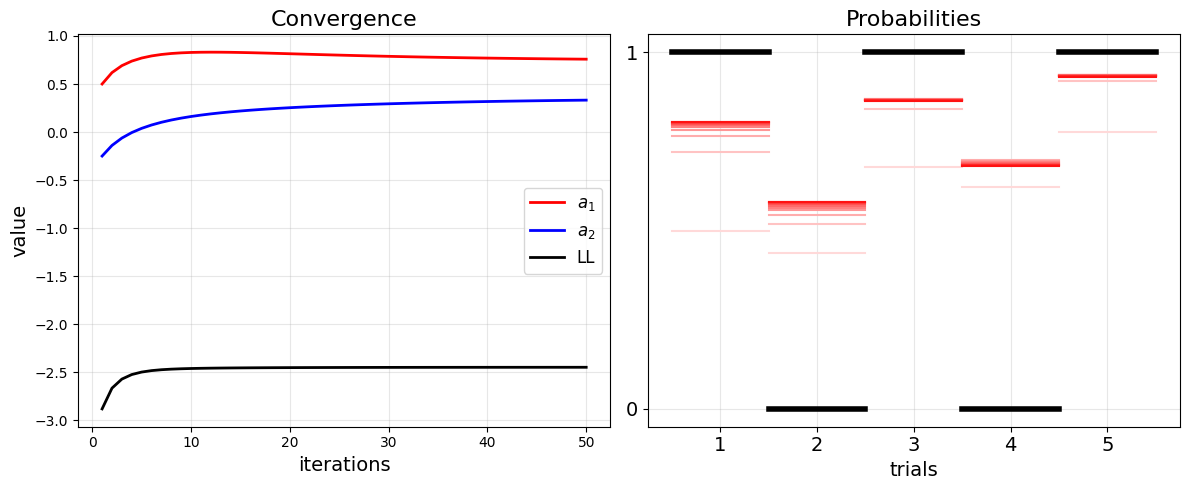

Final parameters a = [0.75835468 0.33204716]
Final log-likelihood = -2.4488183026100616
Final predicted probabilities = [0.80572205 0.5822574  0.86398104 0.68099641 0.93131784]


In [ ]:
# @title Simple example {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt

# ====================== Simple Logistic Regression ======================

# Data
y = np.array([1, 0, 1, 0, 1])
X = np.array([[1, 0, 2, 1, 3],
              [2, 1, 1, 0, 1]])   # 2 features × 5 samples

# Initial parameters
a = np.array([0.5, -0.25])
eta = 0.1
Niter = 50

# Initialize storage
ak = np.zeros((Niter, 2))
ak[0] = a

lambdak = np.zeros((Niter, 5))
mypik = np.zeros((Niter, 5))
LLk = np.zeros(Niter)

# Initial prediction
lambdak[0] = ak[0] @ X
mypik[0] = 1 / (1 + np.exp(-lambdak[0]))

# Initial log-likelihood
LLk[0] = np.sum(y * np.log(mypik[0] / (1 - mypik[0]) + 1e-10) +
                np.log(1 - mypik[0] + 1e-10))

# Gradient ascent loop
for k in range(1, Niter):
    # Gradient of log-likelihood: sum( (y - p) * X )
    gradient = np.sum((y - mypik[k-1]) * X, axis=1)

    # Update parameters
    ak[k] = ak[k-1] + eta * gradient

    # Compute new predictions
    lambdak[k] = ak[k] @ X
    mypik[k] = 1 / (1 + np.exp(-lambdak[k]))

    # Log-likelihood
    LLk[k] = np.sum(y * np.log(mypik[k] / (1 - mypik[k] + 1e-10)) +
                    np.log(1 - mypik[k] + 1e-10))

# ========================== Plotting ==========================

fs = 14
plt.figure(figsize=(12, 5))

# Generate deepening red-to-dark colors for probability lines
colors = np.zeros((Niter, 3))
colors[:, 0] = 1.0                    # Red channel stays high
colors[:, 1] = np.linspace(0.85, 0.0, Niter)   # Green fades
colors[:, 2] = np.linspace(0.85, 0.0, Niter)   # Blue fades → deep red

# Left subplot: Convergence of parameters and log-likelihood
plt.subplot(1, 2, 1)
plt.plot(range(1, Niter+1), ak[:, 0], 'r', linewidth=2, label='$a_1$')
plt.plot(range(1, Niter+1), ak[:, 1], 'b', linewidth=2, label='$a_2$')
plt.plot(range(1, Niter+1), LLk, 'k', linewidth=2, label='LL')
plt.xlabel('iterations', fontsize=fs)
plt.ylabel('value', fontsize=fs)
plt.title('Convergence', fontsize=fs+2)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)

# Right subplot: Predicted probabilities over trials
plt.subplot(1, 2, 2)
for i in range(5):                                 # for each trial
    # True label (black thick line)
    plt.plot([i+1, i+2], [y[i], y[i]], 'k', linewidth=4)

    # Predicted probabilities at selected iterations
    for k in range(0, Niter, 5):                   # every 5th iteration
        plt.plot([i+1, i+2], [mypik[k, i], mypik[k, i]],
                 '-', color=colors[k], linewidth=1.5)

plt.xticks([1.5, 2.5, 3.5, 4.5, 5.5], ['1','2','3','4','5'], fontsize=fs)
plt.yticks([0, 1], fontsize=fs)
plt.xlabel('trials', fontsize=fs)
plt.title('Probabilities', fontsize=fs+2)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: print final results
print("Final parameters a =", ak[-1])
print("Final log-likelihood =", LLk[-1])
print("Final predicted probabilities =", mypik[-1])

# Estimating parameter variance

We can estimate variance analytically, if we are willing to assume that parameter estimates are distributed normally

$$
{\hat ~a} \approx \mathscr{N}\left(a, \, I(a)^{-1}\right)
$$

where $I(a)$ is the Fisher information matrix. For large data sets, the assumption of normality is often good.

# Derivative of log likelihood
Let's build on our example with predictors, $x_{i1}$, $x_{i2}$, $\ldots$ and binary outcomes, $y_i\in\{0,1\}$ to illustrate the conventional approach to estimating parameter variance.

Once again, we assume that logit variable

$$
\lambda_i = a_0 + a_1 x_{i1} + a_2 x_{i2} + \ldots,\qquad \frac{\partial \lambda_i}{\partial a_k} = x_{ik}
$$

depends linearly on predictors, with unknown parameters $a_0$, $a_1$, $a_2$, $\ldots$.

Outcomes are probabilistic and sample a Bernoulli distribution with

$$
\pi_i= \frac{1}{1+e^{-\lambda_i}}, \qquad \frac{\partial\pi_i}{\partial\lambda_i} = \frac{1}{1+e^{-\lambda_i}} \frac{1}{1+e^{\lambda_i}}= \pi_i (1-\pi_i)
$$

The log-likelihood of the observed outcome is then

$$
LL(a_0, a_1, \ldots )
=  \sum_i y_i ~\lambda_i  -  \sum_i \log (1+e^{\lambda_i})
$$

<br>

To find out how $LL(a_0, a_1, \ldots)$ depends on the $a$'s, we need to evaluate the derivatives

$$
\frac{\partial{LL}}{\partial a_j} = \sum_i y_i x_{ij}- \sum_i \frac{e^{\lambda_i}}{1+e^{\lambda_i}} x_{ij} = \sum_i (y_i - \pi_i) x_{ij}
$$

In other words, the derivative of the log-likelihood is the predictor-weighted sum of the deviations between probabilities and outcomes.

In matrix notation, this reads

$$
\frac{\partial{LL}}{\partial \bf a} = {\bf X}^T \cdot (\bf y - \boldsymbol \pi)
$$

# Hessian matrix

The Hessian is the matrix of second partial deriatives


$$
H_{jk} = \frac{\partial^2 LL}{\partial a_j \partial a_k}
$$

so that we need to differentiate our above result again, with respect to $a_k$. For one observation $i$

$$
\frac{\partial}{\partial a_k} \left[(y_i-\pi_i) \, x_{ij} \right] = - \frac{\partial\pi_i}{\partial a_k}~ x_{ij} = - \frac{\partial\pi_i}{\partial \lambda_i} \frac{\partial\lambda_i}{\partial a_k}~ x_{ij} =
\\
= - \pi_i (1-\pi_i) ~ x_{ik} ~ x_{ij}
$$

In matrix notation, this reads

$$
\bf H = - {\bf X}^T \cdot {\bf W} \cdot {\bf X}
$$

where ${\bf W} = \mathrm{diag}\left[\pi_i (1-\pi_i) \right]$ is the diagonal matrix of Bernoulli variances of the estimated probabilities $\pi_i$.

<br>

The Fisher information matrix is the negative Hessian

$$
{\bf I}(\hat ~ a \,) = {\bf X}^T \cdot {\bf W} \cdot {\bf X}
$$

and the covariance matrix of $\hat ~ a$ is the inverse of the Fisher information matrix

$$
\mathrm{Var}(\hat ~ a \,) = \left( {\bf X}^T \cdot {\bf W} \cdot {\bf X} \right)^{-1}
$$

The standard error of the parameters is the square root of that variance.

# Bootstrapping

In a later lecture, we will also discover the more robust approach of 'bootstrapping', which does not require assumptions of normality.



Var Par1:
 1.113051124431251
Var Par2:
 1.5035498960267906


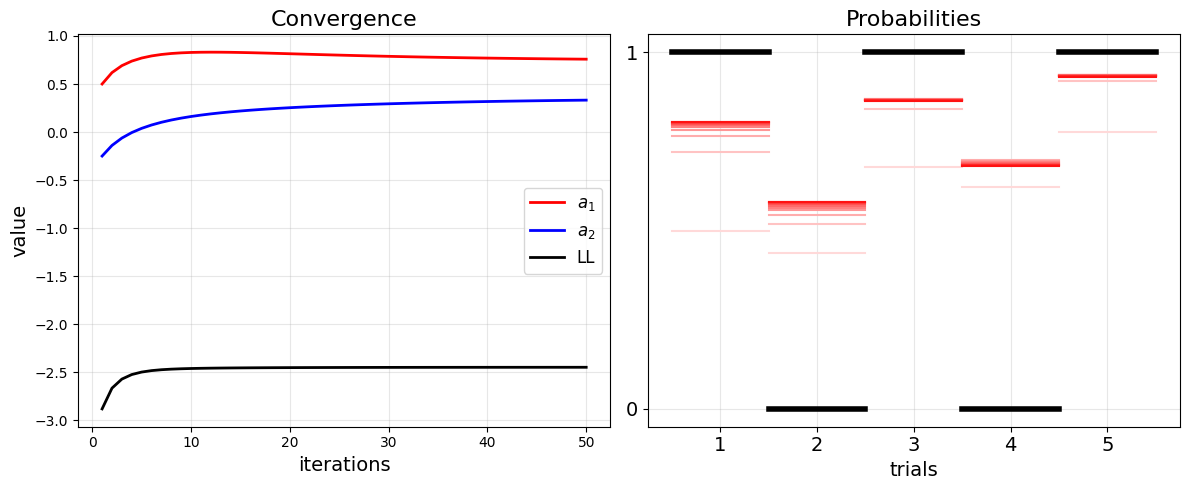

Final parameters a = [0.75835468 0.33204716]
Final log-likelihood = -2.4488183026100616
Final predicted probabilities = [0.80572205 0.5822574  0.86398104 0.68099641 0.93131784]


In [ ]:
# @title Same example, now with parameter variance {"vertical-output":true,"display-mode":"form"}

import numpy as np
import matplotlib.pyplot as plt

# ====================== Simple Logistic Regression ======================

# Data
y = np.array([1, 0, 1, 0, 1])
X = np.array([[1, 0, 2, 1, 3],
              [2, 1, 1, 0, 1]])   # 2 features × 5 samples


#

# Initial parameters
a = np.array([0.5, -0.25])
eta = 0.1
Niter = 50

# Initialize storage
ak = np.zeros((Niter, 2))
ak[0] = a

lambdak = np.zeros((Niter, 5))
mypik = np.zeros((Niter, 5))
LLk = np.zeros(Niter)

# Initial prediction
lambdak[0] = ak[0] @ X
mypik[0] = 1 / (1 + np.exp(-lambdak[0]))

# Initial log-likelihood
LLk[0] = np.sum(y * np.log(mypik[0] / (1 - mypik[0]) + 1e-10) +
                np.log(1 - mypik[0] + 1e-10))

# Gradient ascent loop
for k in range(1, Niter):
    # Gradient of log-likelihood: sum( (y - p) * X )
    gradient = np.sum((y - mypik[k-1]) * X, axis=1)

    # Update parameters
    ak[k] = ak[k-1] + eta * gradient

    # Compute new predictions
    lambdak[k] = ak[k] @ X
    mypik[k] = 1 / (1 + np.exp(-lambdak[k]))

    # Log-likelihood
    LLk[k] = np.sum(y * np.log(mypik[k] / (1 - mypik[k] + 1e-10)) +
                    np.log(1 - mypik[k] + 1e-10))

# ======= Hessian matrix and parameter variance ================

mypi = mypik[-1];       # last iteration

Varpi = mypi * (1 - mypi);   # variance

W = np.diag( Varpi );

Hessian = X @ W @ X.T;
Hessian_inv = np.linalg.inv(Hessian);    # inverse Hessian

print("Var Par1:\n", Hessian_inv[0,0])

print("Var Par2:\n", Hessian_inv[1,1])


# ========================== Plotting ==========================

fs = 14
plt.figure(figsize=(12, 5))

# Generate deepening red-to-dark colors for probability lines
colors = np.zeros((Niter, 3))
colors[:, 0] = 1.0                    # Red channel stays high
colors[:, 1] = np.linspace(0.85, 0.0, Niter)   # Green fades
colors[:, 2] = np.linspace(0.85, 0.0, Niter)   # Blue fades → deep red

# Left subplot: Convergence of parameters and log-likelihood
plt.subplot(1, 2, 1)
plt.plot(range(1, Niter+1), ak[:, 0], 'r', linewidth=2, label='$a_1$')
plt.plot(range(1, Niter+1), ak[:, 1], 'b', linewidth=2, label='$a_2$')
plt.plot(range(1, Niter+1), LLk, 'k', linewidth=2, label='LL')
plt.xlabel('iterations', fontsize=fs)
plt.ylabel('value', fontsize=fs)
plt.title('Convergence', fontsize=fs+2)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)

# Right subplot: Predicted probabilities over trials
plt.subplot(1, 2, 2)
for i in range(5):                                 # for each trial
    # True label (black thick line)
    plt.plot([i+1, i+2], [y[i], y[i]], 'k', linewidth=4)

    # Predicted probabilities at selected iterations
    for k in range(0, Niter, 5):                   # every 5th iteration
        plt.plot([i+1, i+2], [mypik[k, i], mypik[k, i]],
                 '-', color=colors[k], linewidth=1.5)

plt.xticks([1.5, 2.5, 3.5, 4.5, 5.5], ['1','2','3','4','5'], fontsize=fs)
plt.yticks([0, 1], fontsize=fs)
plt.xlabel('trials', fontsize=fs)
plt.title('Probabilities', fontsize=fs+2)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: print final results
print("Final parameters a =", ak[-1])
print("Final log-likelihood =", LLk[-1])
print("Final predicted probabilities =", mypik[-1])

# Sufficient statistic (optional)

The log-likelihood of a logistic regression can be factorized into three factors.


The first factor depends on **both** observations $\bf y$ and predictors ${\bf x}$, specifically, the sums over trials

$$
S_0 = \sum_i y_i, \qquad S_1 = \sum_i y_i x_{i1}, \qquad S_2 = \sum_i y_i x_{i2}, \quad \ldots
$$,


The second factor depends only on predictors $\bf x$, and the third factor depends only on observations $\bf y$.

The implication is that the summed values $S_0$, $S_1$, $S_2$, $\ldots$  alone contain all of the experiment's useful information.  

In other words, the summed values $S_0$, $S_1$, $S_2$, $\ldots$ are the **sufficient statistics** for optimizing $(a_0, a_1, a_2, \ldots)$.

It is the logistic parametrization that make this separation possible.

# Proof

We can gain some further insight by re-expressing the joint likelihood of observations with a helper function $\Psi(\lambda_i)$

<br>

$$
\Psi({\lambda_i}) = \ln\left( 1 + e^{\lambda_i}\right) \qquad \Leftrightarrow \qquad e^{\Psi(\lambda_i)} = 1 + e^\lambda_i
$$

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_psioflambda.png" width="600">

The binomial likelihood of observing trial outcome $y_i$, given prediction $\pi_i$, is
$$\begin{eqnarray}
\binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} &=& \binom{n_i}{y_i} \left(\frac{\pi_i}{1-\pi_i} \right)^{y_i} \left(1-\pi_i \right)^{n_i} =
\\
&=&
\binom{n_i}{y_i} e^{\lambda_i y_i}\left[ 1+e^{\lambda_i}\right]^{-n_i} =
\\
&=&  \binom{n_i}{y_i} \exp\left[\lambda_i y_i - n_i \Psi( \lambda_i)\right]
\end{eqnarray}$$

<br>

The joint likelihood of observations $\bf y$ as a function of predictors $\bf x$ and the to-be-optimized parameters $(a_0, a_1, \ldots )$ and

$$\begin{eqnarray}
L_{(a_0, a_1, \ldots )}({\bf y}) &=& \prod_{i=1}^N  \binom{n_i}{y_i} \exp\left[\lambda_i y_i  - n_i \Psi( \lambda_i) \right] =
\\
&=& \exp\left[\sum_i\lambda_i y_i \right] \exp\left[-\sum_i\Psi(\lambda_i) n_i \right] \prod_{i=1}^N  \binom{n_i}{y_i}
\end{eqnarray}$$

With

$$\begin{eqnarray}
\exp\left[\sum_i\lambda_i y_i \right] = \exp\left[\sum_i (a_0+a_1 x_{i1} + \ldots) y_i \right] = \exp\left[a_0 \sum_i y_i +a_1 \sum_i y_i x_i + \ldots \right] = \exp\left[ a_0 S_0 + a_1 S_1 + \ldots \right]
\end{eqnarray}$$

we obtain

$$\begin{eqnarray}
L_{(a_0, a_1, \ldots)}({\bf y}) &=& \exp\left[ a_0 S_0 + a_1 S_1 + \ldots \right]  \cdot
\exp\left[-\sum_i\Psi(a_0+a_1 x_i + \ldots ) n_i \right] \cdot
\prod_{i=1}^N  \binom{n_i}{y_i}
\end{eqnarray}$$

Note that only the first of these three factors depends on **both** observations $\bf y$ and predictors ${\bf x}$.

The second factor depends only on predictors $\bf x$, and the third factor depends only on observations $\bf y$.



# Cell infusion example

In this example, human muscle cell colonies were infused with mouse nuclei in five different ratios, cultured over time periods ranging from one to five days, and observed to see whether they thrived. For example, of the 126 colonies having the third ratio and shortest time period, 48 thrived.

<br>




<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/cell_infusion_data.png" width="600">

<br>

Let $\pi_{ij}$ denote the (unknown) true probability of thriving for ratio $i$ during time period $j$, and $\lambda_{ij}$ the **logits**

$$
\lambda_{ij} = \log\frac{\pi_{ij}}{1-\pi_{ij}}
$$

Our model for $\lambda_{ij}$ is a two-additive regression, with $\alpha$s changing over times and $\beta$s changing over ratios, as follows

$$
\lambda_{ij} = \mu + \alpha_i + \beta_j, \qquad i,j = 1, 2, \ldots , 5
$$

with constraints

$$
\sum_i \alpha_i = \sum_j \beta_j = 0
$$

to avoid redundancies. Accordingly, we have nine free parameters overall (four $\alpha$'s, four $\beta$'s, and $\mu$).

<br>

The binomial standard error of the 'thriving' proportions is

$$
SE_\pi = \sqrt{\frac{\pi_i (1-\pi_i)}{n_i}}
$$

based on the observed proportions $\pi_i$ (i.e., considering all conditions separately), and

$$
SE_{\hat{\,\pi}} = \sqrt{\frac{\hat{\,\pi_i} (1-\hat{\,\pi_i})}{n_i}},
$$

base on the fitted proportions $\hat{\,\pi_i}$ (i.e., considering all conditions jointly).


# Practicalities

The design matrix ${\bf X}=x_{ij,k}$ is of size $(25 \times 9)$, as there are 25 conditions and 9 parameters (factors/levels):

$$\begin{eqnarray}
\left(\begin{array}{ccccccc}
x_{11,1} & x_{11,2} & \ldots & x_{11,5} & x_{11,6} & \ldots & x_{11,9}\\
x_{21,1} & x_{21,2} & \ldots & x_{21,5} & x_{21,6} & \ldots & x_{21,9}\\
x_{31,1} & x_{31,2} & \ldots & x_{31,5} & x_{31,6} & \ldots & x_{31,9}\\
x_{41,1} & x_{41,2} & \ldots & x_{41,5} & x_{41,6} & \ldots & x_{41,9}\\
x_{51,1} & x_{51,2} & \ldots & x_{51,5} & x_{51,6} & \ldots & x_{51,9}\\
x_{12,1} & x_{12,2} & \ldots & x_{12,5} & x_{12,6} & \ldots & x_{12,9}\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
x_{15,1} & x_{15,2} & \ldots & x_{15,5} & x_{15,6} & \ldots & x_{15,9}\\
x_{25,1} & x_{25,2} & \ldots & x_{25,5} & x_{25,6} & \ldots & x_{25,9}\\
x_{35,1} & x_{35,2} & \ldots & x_{35,5} & x_{35,6} & \ldots & x_{35,9}\\
x_{45,1} & x_{45,2} & \ldots & x_{45,5} & x_{45,6} & \ldots & x_{45,9}\\
x_{55,1} & x_{55,2} & \ldots & x_{55,5} & x_{55,6} & \ldots & x_{55,9}\\
\end{array}
\right)
\quad = \quad
\left(\begin{array}{ccccccc}
1 & 1 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & -1 & \ldots & -1 & 1 & \ldots & 0\\
1 & 1 & \ldots & 0 & 0 & \ldots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & 1 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 1 & 0 & \ldots & 1\\
1 & -1 & \ldots & -1 & -1 & \ldots & -1\\
\end{array}
\right)
\end{eqnarray}$$

<br>

Multiplication with the parameter vector $\beta$ gives

<br>

$$\begin{eqnarray}
\lambda_{ij} = \left(\begin{array}{c}
\mu+\alpha_1+\beta_1 \\
\mu+\alpha_2+\beta_1 \\
\mu+\alpha_3+\beta_1 \\
\mu+\alpha_4+\beta_1 \\
\mu-\alpha_1-\alpha_2-\alpha_3-\alpha_4+\beta_1 \\
\mu+\alpha_1+\beta_2 \\
\vdots \\
\mu+\alpha_1-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_2-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_3-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu+\alpha_4-\beta_1-\beta_2-\beta_3-\beta_4 \\
\mu-\alpha_1-\alpha_2-\alpha_3-\alpha_4-\beta_1-\beta_2-\beta_3-\beta_4 \\
\end{array}
\right)
\quad = \quad
\left(\begin{array}{ccccccc}
1 & 1 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & 0 & \ldots & 0 & 1 & \ldots & 0\\
1 & -1 & \ldots & -1 & 1 & \ldots & 0\\
1 & 1 & \ldots & 0 & 0 & \ldots & 0\\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & 1 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 0 & 0 & \ldots & 1\\
1 & 0 & \ldots & 1 & 0 & \ldots & 1\\
1 & -1 & \ldots & -1 & -1 & \ldots & -1\\
\end{array}
\right)
\cdot
\left(\begin{array}{c}
\mu\\
\alpha_1\\
\alpha_2\\
\alpha_3\\
\alpha_4\\
\beta_1\\
\beta_2\\
\beta_3\\
\beta_4
\end{array}\right)
\end{eqnarray}$$

<br>

The joint binomial likelihood of trial outcomes $y_i$, given predictions $\pi_i$, is

$$\begin{eqnarray}
\prod_i \binom{n_i}{y_i} \pi_i^{y_i} (1-\pi_i)^{n_i-y_i} &=& \prod_i \binom{n_i}{y_i} \left(\frac{\pi_i}{1-\pi_i} \right)^{y_i} \left(1-\pi_i \right)^{n_i} =
\\
&=&
\prod_i \binom{n_i}{y_i} \left[e^{\lambda_i}\right]^{y_i}\left[ 1+e^{\lambda_i}\right]^{-n_i} =
\end{eqnarray}$$

and the negative logarithm is

$$\begin{eqnarray}
-\sum_i \log \binom{n_i}{y_i} - \sum_i y_i  \lambda_i + n_i \sum_i \log \left( 1+e^{\lambda_i}\right)
\end{eqnarray}$$

The parameter-dependent terms that need to be considered in the minimization are

$$\begin{eqnarray}
LL = -\sum_i \left[ y_i  \lambda_i - n_i \log \left( 1+e^{\lambda_i}\right)\right]
\end{eqnarray}$$


Estimated pi's: [[0.11295619 0.25360615 0.41995125 0.53924515 0.74728736]
 [0.23573104 0.45145221 0.63684408 0.73922999 0.87748892]
 [0.37716653 0.61770798 0.77492429 0.84769117 0.93360916]
 [0.31857136 0.55504558 0.72662694 0.81120416 0.9156567 ]
 [0.17953804 0.36863968 0.55439399 0.6679035  0.83556746]]
Estimated beta's: [ 0.41281869 -1.61652678 -0.63510338  0.12139407  0.60167176 -0.85718627
  0.0274798   0.70211573  0.44336307]
Variance beta's:
 [0.23036816 0.93969906 0.75468421 0.77735868 0.86877216 0.86003689
 0.84177908 0.9506837  0.89494451]


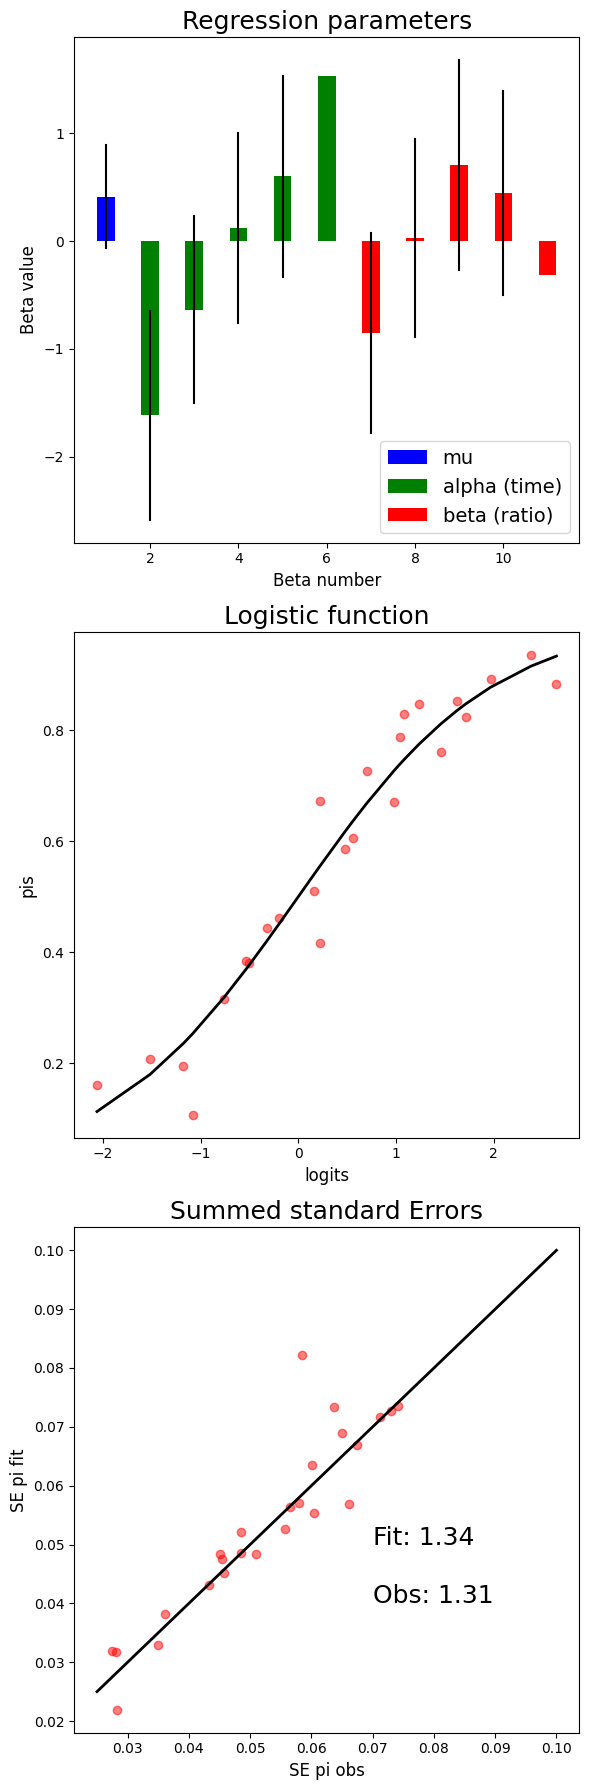

In [ ]:
# @title Logistic regression, cell infusion example {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit # logistic sigmoid function
from scipy.stats import binom

# define data
Nratio = 5;
Ntime  = 5;

thrived = np.array([
    [5,3,20,24,29],
    [15,36,43,56,66],
    [48,68,145,98,114],
    [29,35,57,38,72],
    [11,20,20,40,52]
])

colonies = np.array([
    [31,28,45,47,35],
    [77,78,71,71,74],
    [126,116,171,119,129],
    [92,52,85,50,77],
    [53,52,48,55,61]
])

design = np.array([
    [1,1,0,0,0,1,0,0,0],
    [1,0,1,0,0,1,0,0,0],
    [1,0,0,1,0,1,0,0,0],
    [1,0,0,0,1,1,0,0,0],
    [1,-1,-1,-1,-1,1,0,0,0],
    [1,1,0,0,0,0,1,0,0],
    [1,0,1,0,0,0,1,0,0],
    [1,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,1,0,0],
    [1,-1,-1,-1,-1,0,1,0,0],
    [1,1,0,0,0,0,0,1,0],
    [1,0,1,0,0,0,0,1,0],
    [1,0,0,1,0,0,0,1,0],
    [1,0,0,0,1,0,0,1,0],
    [1,-1,-1,-1,-1,0,0,1,0],
    [1,1,0,0,0,0,0,0,1],
    [1,0,1,0,0,0,0,0,1],
    [1,0,0,1,0,0,0,0,1],
    [1,0,0,0,1,0,0,0,1],
    [1,-1,-1,-1,-1,0,0,0,1],
    [1,1,0,0,0,-1,-1,-1,-1],
    [1,0,1,0,0,-1,-1,-1,-1],
    [1,0,0,1,0,-1,-1,-1,-1],
    [1,0,0,0,1,-1,-1,-1,-1],
    [1,-1,-1,-1,-1,-1,-1,-1,-1]
])

# collect matrix and observations

n = colonies.flatten()
X = design
y = thrived.flatten();

n_obs = n;
pi_obs = y / n;

# Negative log-likelihood for logistic regression
def neg_log_likelihood(beta, X, y, n):
 logits = X @ beta
 log_likelihood = y * logits - n * np.log(1 + np.exp(logits))
 return -np.sum(log_likelihood)

# Initial guess
beta_init = np.zeros(X.shape[1])

# Minimize negative log-likelihood
result = minimize(neg_log_likelihood, beta_init, args=(X, y, n), method='BFGS')

beta_fit = result.x;

logit_fit = X @ beta_fit
pi_fit = expit(logit_fit)

# Variance of beta's ========================================

Varpi = pi_fit * (1 - pi_fit);   # variance

W = np.diag( Varpi );

Hessian = X.T @ W @ X;
Hessian_inv = np.linalg.inv(Hessian);    # inverse Hessian

var_beta = np.diag( Hessian_inv )




# Output results ============================================
print( "Estimated pi's:", pi_fit.reshape(Nratio,Ntime) )

print("Estimated beta's:", beta_fit)

print("Variance beta's:\n", var_beta)


# Visualize results
fig, axs = plt.subplots( 3, 1, figsize=(6,18))

# Plot 1: Coefficients mu, alpha, beta
mu    = beta_fit[0]
alpha = beta_fit[1:5]
beta  = beta_fit[5:10]

errmu = np.sqrt(var_beta[0])
erralpha = np.sqrt(var_beta[1:5])
errbeta = np.sqrt(var_beta[5:10])

alphasum = np.sum(alpha)
betasum  = np.sum(beta)

alpha = np.append( alpha, -alphasum)
beta  = np.append( beta,  -betasum)

labels = ['mu', 'alpha', 'beta']

axs[0].bar( [1], mu, width=0.4, color='blue', label='mu' )
axs[0].plot( [1,1], [mu-errmu,mu+errmu], color='black')
axs[0].bar( np.arange(2,7), alpha, width=0.4, color='green', label='alpha (time)' )
for i in range(4):
    axs[0].plot( [i+2,i+2], [alpha[i]-erralpha[i],alpha[i]+erralpha[i]], color='black')
axs[0].bar( np.arange(7,12), beta, width=0.4, color='red', label='beta (ratio)' )
for i in range(4):
    axs[0].plot( [i+7,i+7], [beta[i]-errbeta[i],beta[i]+errbeta[i]], color='black')
axs[0].set_box_aspect(1/1)
axs[0].legend(loc='lower right', fontsize=14)
axs[0].set_xlabel('Beta number', fontsize=12)
axs[0].set_ylabel('Beta value', fontsize=12)
axs[0].set_title('Regression parameters', fontsize=18)

# Plot 2: Logistic fit: fitted pi values, observed pi values, against 25 logit values

indices = np.argsort(logit_fit)
logit_fit = logit_fit[indices]
pi_fit = pi_fit[indices]
pi_obs = pi_obs[indices]
n_obs = n_obs[indices]

axs[1].plot(logit_fit, pi_fit, 'k-', linewidth=2 )
axs[1].scatter(logit_fit, pi_obs, marker='o', color='red', alpha=0.5)
axs[1].set_box_aspect(1/1)
axs[1].set_xlabel('logits', fontsize=12)
axs[1].set_ylabel('pis', fontsize=12)
axs[1].set_title('Logistic function', fontsize=18)


# Plot 3: Squared standard errors: fitted against observed SE of pi values

SE_fit = np.sqrt( pi_fit * (1-pi_fit) / n_obs )
SE_obs = np.sqrt( pi_obs * (1-pi_obs) / n_obs )

axs[2].scatter(SE_obs, SE_fit, marker='o', color='red', alpha=0.5)
axs[2].plot([0.025,0.1], [0.025,0.1], 'k-', linewidth=2 )
axs[2].set_box_aspect(1/1)
axs[2].set_xlabel('SE pi obs', fontsize=12)
axs[2].set_ylabel('SE pi fit', fontsize=12)
axs[2].text( 0.07, 0.05,  f"Fit: {np.sum(SE_fit):.2f}", fontsize=18)
axs[2].text( 0.07, 0.04, f"Obs: {np.sum(SE_obs):.2f}", fontsize=18)
axs[2].set_title('Summed standard Errors', fontsize=18)


plt.tight_layout()
plt.show()


# **2. Generalized linear models**

Logistic regression is a special case of Generalized Linear Models (GLMs).  GLMs extend ordinary linear regression, that is least squares curve-fitting, to situations where the response variables are binomial, Poisson, gamma, beta, or in fact any exponential family form.

<br>

A one-parameter distribution in the exponential family is

<br>

$$
\left\{f_\lambda(y) = e^{\lambda y - \gamma(y)} \, f_0(y), \qquad \lambda \in \Lambda \right\}
$$

<br>

where $y$ is a data point from our experiment, $\lambda$ is the **natural parameter** of the distribution, $\gamma(\lambda)$ is the **normalizing function**, and $f_0(y)$ is the distribution for $\lambda=0$. For example, in case of the normal distribution, where $\sigma$ is assumed to be known

$$
f_\lambda(y) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left[-\frac{(y-\mu)^2}{2\sigma^2} \right]  =  \exp\left[ \frac{\mu y}{\sigma^2} - \frac{\mu^2}{2\sigma^2}\right] \, f_{\lambda_0}(y) = \exp\left[{\lambda y - \gamma(y)}\right] \, f_{\lambda_0}(y)
$$

where we have defined

$$
\lambda = \frac{\mu}{\sigma^2}, \qquad \gamma(\lambda) = \frac{\sigma^2\lambda^2}{2} = \frac{\mu^2}{2\sigma^2},\qquad f_0(y) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{y^2}{2\sigma^2} \right)
$$

<br>

We assume that each point from our data set ${\bf y} = (y_1, y_2, \ldots , y_N)$ independently samples members from this family of distributions, with corresponding natural parameters ${\boldsymbol \lambda} = (\lambda_1, \lambda_2, \ldots , \lambda_N)$

$$
y_i \sim f_\lambda( \lambda_i ), \qquad\qquad \mathrm{independently} \,\, i = 1, 2, \ldots , N
$$

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_exponential_family.png" width="600">

<br>

# Maximum likelihood fitting

The $N$ natural parameters $\lambda_i$ are fitted with a linear regression

$$
\hat{~\boldsymbol\lambda\,} = {\bf X} \cdot \boldsymbol\alpha
$$

where ${\bf X}$ is an $N\times P$ design matrix and $\boldsymbol\alpha$ is a $P\times i$ parameter vector, with $P\ll N$.

<br>

The likelihood distribution of the observations, given our model and its parameters, is then

<br>

$$
L(\boldsymbol\alpha) = \prod_i f_{\lambda_i}(y_i) = \exp\left[{\sum_i \left[\lambda_i y_i  - \gamma(\lambda_i) \right]}\right] \, \prod_i f_{0}(y_i)
$$

where the dot-product

$$
\sum_i y_i \lambda_i = \underbrace{{\bf y} \cdot {\bf X}}_{\bf z} \cdot \boldsymbol\alpha
$$

includes the sufficient statistic ${\bf z} = {\bf y} \cdot {\bf X}$ and the sum of gamma-terms

$$
\sum_i \gamma( \lambda_i ) = \sum_i \gamma\left({\bf x}_i \cdot \boldsymbol\alpha \right)
$$

involves the dot-products between rows of $\bf X$ and parameter vector $\boldsymbol\alpha$.

<br>

The univariate likelihood distributions are characterized by their respective means $\mu_\lambda$ and variances $\sigma^2_\lambda$

$$
y\sim \left(\mu_\lambda , \sigma^2_\lambda \right)
$$

and the multivariate distribution has mean $\boldsymbol\mu$ and variance $\boldsymbol\Sigma$, which is diagonal due to independence

$$
\boldsymbol y \sim \left(\boldsymbol\mu(\boldsymbol \alpha) , {\boldsymbol\Sigma} (\boldsymbol \alpha)  \right)
$$

The MLE $\hat{\,\boldsymbol\alpha}$ satisfies

$$
0 = {\bf X}^T \left[ {\bf y} - {\boldsymbol\mu}(\hat{\,\boldsymbol\alpha})\right]
$$

and is destributed as with mean and covariance

$$
\hat{\,\boldsymbol\alpha} \sim \left[\boldsymbol\alpha, \left({\bf X}^T \cdot {\boldsymbol\Sigma}(\boldsymbol\alpha) \cdot {\bf X} \right)^{-1} \right]
$$

and its numerical solution is facilitated by the convexity of $\bf L(\boldsymbol\alpha)$,

<br>

The MLE $\hat{\,\boldsymbol\alpha}$ minimizes the total divergence

$$
\sum_i D\left[y_i, \mu_i(\boldsymbol\alpha)\right], \qquad\qquad D\left[f_1, f_2\right] \equiv \int_y f_1(y) \log\frac{f_1(y)}{f_2(y)} dy
$$

# Conclusion

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_three_levels.png" width="600">



The inner circle of represents parametric statistics of normally distributed variables. Exact inferences—t-tests, F distributions, and multivariate analysis are feasible there.

The middle circle comprises some exact results relating
to a few special families: the binomial, Poisson, gamma, beta, and so on. Exponential family theory unifies this middle circle into a coherent whole. Even the approximations are more robust and convincing that in the outer circle ('general theory').

# **3. Gamma regression**

Gamma distributions arise from accumulations of multiple events, each of which occurs with exponentially distributed waiting times.

Examples include:

- Multistable perception: visual, auditory, and somatosensory perceptions and typically unstable, in the sense that they are eventually replaced with alternative perceptions, even when stimulation remains constant. The persistence duration of such perceptions is Gamma distributed.

- Gene Expression Levels: measured as mRNA or protein abundance, due to the stochastic nature of transcription and translation, where bursts of molecular synthesis occur at random intervals.


- Time to Cell Division: The time it takes for a cell to complete its cycle and divide (intermitotic time) can be gamma-distributed. This reflects the accumulation of multiple stochastic biochemical steps (e.g., DNA replication, checkpoint signaling) that must occur before division.

- Enzyme Kinetics: The time taken for an enzyme to catalyze a reaction or the number of substrate molecules processed in a given time can follow a gamma distribution. This is because enzymatic reactions often involve multiple intermediate steps, each with exponential-like waiting times.

- DNA Mutation Accumulation: The number of mutations accumulated in a genome over time, especially in rapidly dividing cells or under mutagenic stress, can follow a gamma distribution due to the independent occurrence of mutation events modulated by repair mechanisms.


# Binocular rivalry rexample

We investigated binocular rivalry in human observers at five different image contrasts. This produced five sets of 'perceptual dominance' periods (approximately 800 periods per set). We be believe that the different sets sample Gamma distributions with different rate parameters, but all with the same shape parameter $\nu \approx 3.5$.

Let $\bf n$ be a $(N_\mathit{sample}\times 1)$ vector of ones and $\bf c$ be a $(N_\mathit{sample}\times 1)$ vector of contrast values $c=1,2,\ldots,5$. Then we can define a design matrix

$$
\bf X = \left[\begin{array}{ccc} {\bf n}&  {\bf c} & {\bf n} \end{array}\right]
$$

for three unknown parameters ${\boldsymbol\alpha} = [\alpha_0, \alpha_1, \alpha_2]$.

<br>

The natural parameters $\lambda_{1,2} = \left(\frac{1}{\theta},\nu\right)$ of the Gamma distribution are the inverse scale (or rate) parameter $\frac{1}{\boldsymbol\theta}$ and shape parameter $\nu$, which we fit as

$$
\lambda_1  = X_0 \alpha_0 + X_1 \alpha_1, \qquad\qquad \lambda_2 = X_2 \alpha_2
$$

<br>

The Gamma distribution is defined as

$$\begin{eqnarray}
f_{\lambda}(y) &=& \frac{1}{ \Gamma(\nu)} \, \frac{y^{\nu-1}}{\theta^\nu} \, \exp\left(-\frac{y}{\theta}\right) =
\\
&=& \exp\left[-\frac{y}{\theta} + (\nu-1) \log y +  \nu \log \left(\frac{1}{\theta}\right)   - \log\Gamma(\nu) \right]=
\\
&=& \exp{\left[-\lambda_1 y +  (\lambda_2-1) \log y + \Psi \right]}
\end{eqnarray}$$

$$ \lambda_1 = \frac{1}{\theta}, \qquad \lambda_2=\nu,\qquad \Psi = \lambda_2 \log(\lambda_1) - \log\Gamma(\lambda_2)
$$

so that the parameter-dependent part of the log likelihood of observations, given parameters $(\alpha_0, \alpha_1, \alpha_2)$, is

$$
LL(\boldsymbol\alpha) = \sum_i \left[ -y_i \lambda_{1i}  +  (\lambda_{2i}-1) \log y_i + \lambda_{2i} \log(\lambda_{1i}) - \log\Gamma(\lambda_{2i})\right]
$$

The **negative** log-likelihood is what we want to **minimize**.

Observed shape: [2.56309542 3.04941737 3.2565268  4.06819666 2.65655882]
Observed scale: [1.14021258 0.92052397 0.86215625 0.48009958 0.6170693 ]
Optimization success: True
Fitted shape (shared) : 3.2823
Fitted intercept     : 1.0877
Fitted slope         : -0.5821


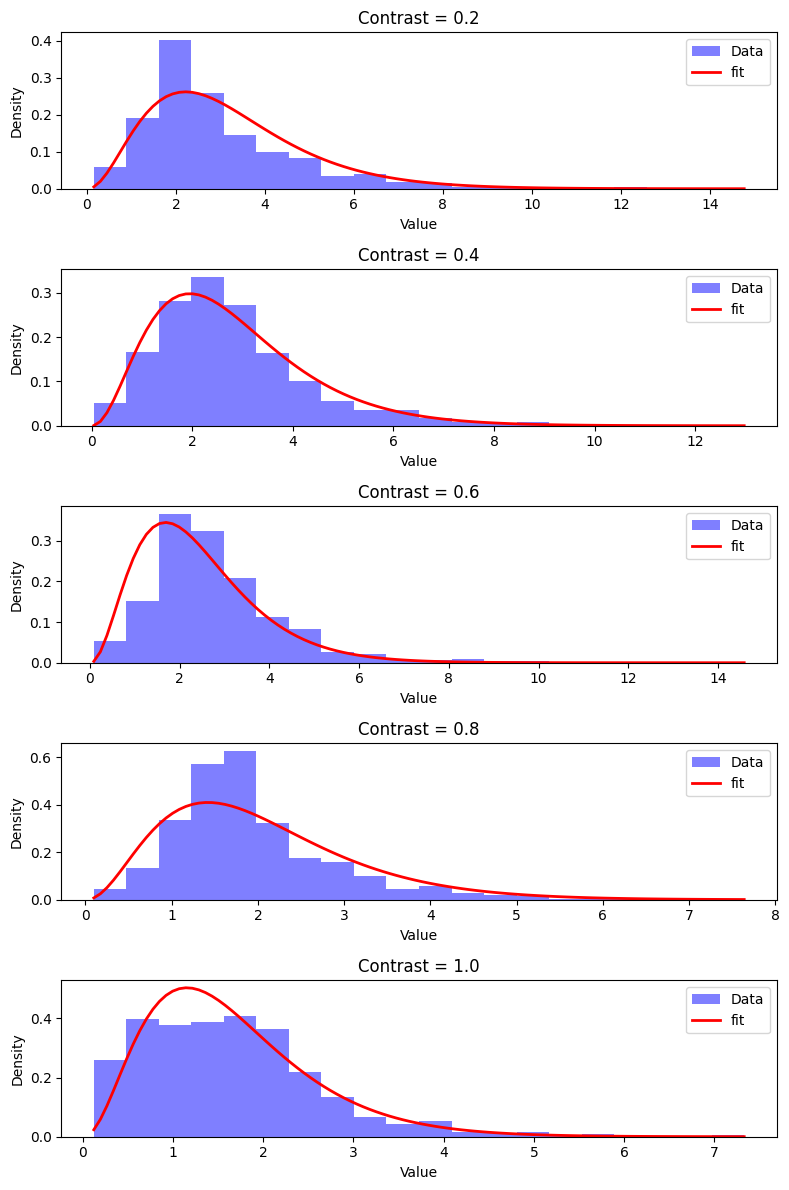

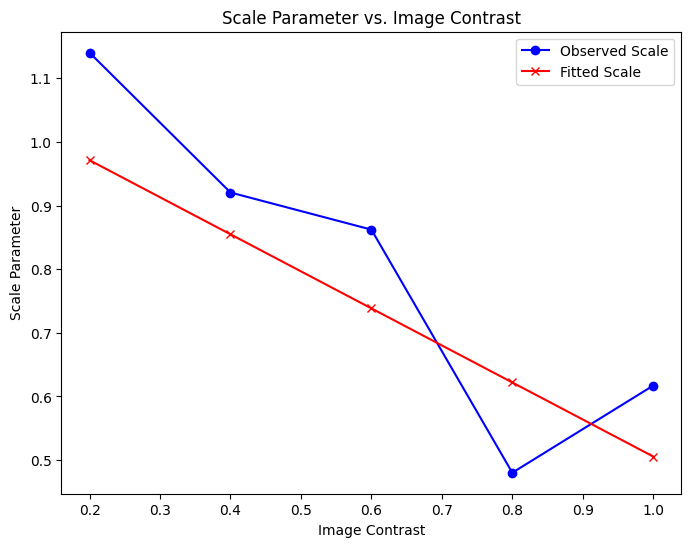

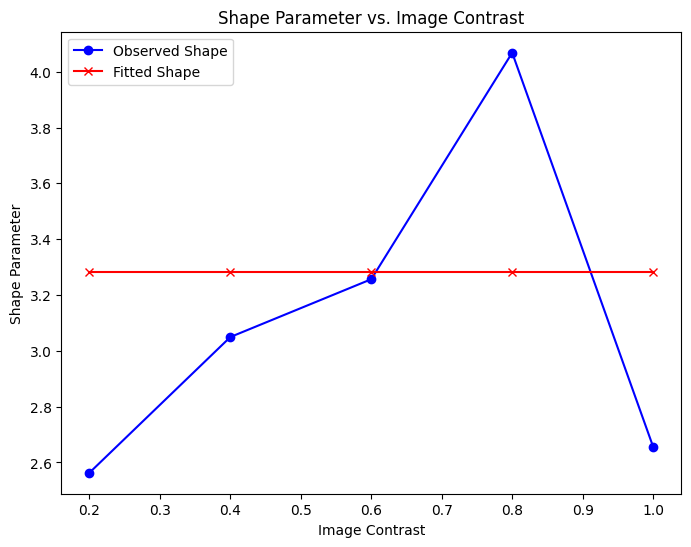

In [ ]:

# @title Gamma regression with binocular rivalry data {"vertical-output":true,"display-mode":"form"}
import numpy as np
from scipy.stats import gamma as gammadist
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# get rivalry data
def RivalryData():

    condition_list = [1, 2, 3, 4, 5]

    samples_per_condition = np.zeros(5,dtype='int')

    samples_per_condition[0] = 740;

    sample_1 = ([5.5853, 3.9241, 5.1557, 1.2603, 4.2964, 2.5778, 1.4178, 1.6756, 1.9620, 4.7117, 2.3630, 2.1052, 3.3941, 1.9763, 1.0025, 0.6731, 2.2485, 2.6352, 2.7067, 2.7497, 1.3462, 1.6899, 1.3605, 6.3730, 1.2747, 0.4296, 1.7902, 4.9552, 2.1482, 3.7665, 1.4178, 3.0505, 1.3032, 1.8474, 1.8045, 1.4465, 1.1027, 2.9072, 1.1027, 2.4924, 1.6494, 1.6127, 1.2095, 3.3354, 2.7856, 2.7490, 1.7962, 2.1992, 1.7594, 1.8326, 1.7958, 2.4191, 2.1992, 2.2358, 3.1155, 1.6860, 1.4296, 1.7958, 1.6862, 1.9793, 1.7594, 1.7593, 1.7227, 2.2358, 2.4924, 2.1992, 2.5657, 3.6286, 2.4191, 2.0892, 1.8693, 1.9793, 2.1992, 2.4191, 2.6392, 8.4669, 2.4191, 2.6757, 2.4924, 1.7960, 2.1992, 2.3459, 1.8328, 4.6183, 2.3825, 1.9794, 2.0892, 6.2677, 1.2462, 1.6860, 0.9896, 1.1363, 1.0996, 2.1991, 2.5291, 1.7227, 1.5394, 1.5394, 1.5394, 1.9426, 1.9793, 2.5291, 4.4717, 2.0892, 4.1783, 4.6183, 7.6972, 3.2621, 2.0526, 2.0893, 3.8486, 2.7121, 2.3091, 3.1888, 4.3984, 2.4924, 1.3561, 1.3195, 1.7593, 1.7593, 1.2096, 1.7228, 1.4295, 8.2836, 2.3824, 1.6860, 5.1681, 2.7122, 1.8327, 2.3091, 2.0159, 1.7227, 1.5394, 1.4294, 1.7594, 2.0157, 2.0526, 1.6127, 1.7594, 1.7961, 1.5394, 1.6860, 1.3195, 1.6860, 1.6494, 1.5394, 1.7960, 2.0892, 3.6651, 6.2308, 5.7912, 4.1785, 2.0892, 2.0892, 1.7593, 1.7593, 1.6860, 1.6128, 2.7490, 1.7593, 1.4661, 1.8693, 1.8693, 2.1992, 2.7856, 1.0263, 1.1731, 0.9896, 1.8694, 1.1729, 1.7593, 2.6390, 1.6494, 1.4296, 1.8326, 1.6494, 1.7592, 1.9794, 3.2621, 1.6494, 1.3195, 1.4295, 1.3930, 1.6494, 4.9114, 1.7593, 1.4295, 1.4294, 1.2096, 2.5290, 1.6860, 1.0263, 0.9530, 1.1729, 1.6494, 1.6127, 1.6129, 1.3928, 1.7593, 1.7593, 4.2884, 1.5028, 1.7960, 2.9689, 1.5397, 2.5291, 1.6494, 2.0526, 2.7490, 4.5450, 3.8486, 2.8589, 3.3721, 3.5899, 6.8561, 4.9481, 3.2017, 7.3412, 5.2068, 4.7540, 7.3736, 3.6221, 5.7242, 1.4877, 5.6919, 1.6170, 1.6494, 3.6221, 9.1199, 2.4255, 1.8434, 2.0698, 1.6494, 6.1123, 1.5847, 4.6570, 6.4034, 2.2315, 3.7191, 5.6272, 3.4604, 3.8808, 2.1991, 3.4604, 4.3336, 2.4255, 2.6196, 1.0672, 3.8808, 5.1421, 3.9132, 3.8485, 5.0127, 6.0476, 8.1174, 3.1370, 1.4553, 4.4306, 1.8434, 4.7217, 4.7540, 3.5251, 3.3310, 2.4255, 3.9132, 2.0372, 1.3583, 0.6792, 2.6519, 2.1991, 3.4281, 1.1644, 2.1021, 1.7787, 7.6970, 1.4876, 0.2587, 2.0374, 2.8136, 3.0076, 3.7838, 4.1395, 3.0723, 2.8460, 1.6303, 1.5397, 1.0718, 3.1399, 3.6683, 6.0836, 2.5662, 1.1171, 3.9853, 1.6757, 1.8115, 0.3321, 1.7209, 4.3476, 2.1134, 3.3211, 4.0759, 3.9853, 2.6871, 2.5814, 2.9890, 3.4871, 2.0077, 0.2264, 1.9474, 2.8078, 1.7662, 0.6340, 2.4757, 1.7209, 5.9176, 2.0832, 4.4382, 2.1738, 2.0379, 4.4231, 1.5247, 2.5814, 3.6683, 4.8321, 1.9329, 3.9480, 3.5162, 2.2002, 1.9534, 7.9165, 4.6882, 0.9253, 1.4805, 3.3517, 1.8095, 1.6861, 6.4977, 0.8636, 3.7218, 4.1330, 2.5497, 1.9329, 5.4902, 2.7142, 1.6861, 5.7780, 3.5367, 4.3798, 0.7197, 3.5573, 3.0844, 3.3517, 0.5132, 3.7289, 0.6414, 5.4565, 9.8525, 6.7308, 3.0532, 2.4460, 1.7533, 2.0783, 1.1289, 1.5138, 0.1539, 1.4368, 0.2993, 5.2170, 4.3019, 3.0447, 0.3678, 4.3789, 0.6928, 3.1559, 1.5037, 2.3630, 1.4178, 2.0480, 1.2889, 0.6874, 3.3226, 1.0311, 3.2939, 1.6326, 2.0623, 1.4608, 4.3107, 2.4919, 3.5660, 3.0361, 0.4726, 6.0579, 4.2105, 1.8904, 1.8904, 0.6445, 2.4346, 1.2030, 2.6924, 5.6569, 2.5922, 2.7927, 3.3942, 0.8593, 1.4751, 0.1575, 1.2603, 1.7329, 0.9882, 3.2223, 1.3195, 2.3458, 1.7593, 2.3091, 6.6709, 6.4509, 3.6287, 5.0213, 3.1888, 3.7752, 2.4193, 2.6024, 3.9585, 2.1992, 2.2725, 2.7123, 2.4557, 2.3826, 2.8223, 2.4923, 2.1992, 2.0892, 1.9060, 2.3092, 1.9793, 2.3091, 2.3092, 5.2781, 2.0526, 1.7593, 2.3091, 3.7386, 2.7490, 2.6390, 2.5289, 2.0892, 1.9793, 2.3091, 2.2358, 1.9426, 2.7490, 1.8692, 2.7489, 2.6757, 3.8486, 3.1887, 2.1992, 7.7338, 1.7594, 2.1625, 2.0526, 2.8589, 1.5028, 2.9689, 2.5287, 9.4198, 5.0581, 3.0789, 3.5553, 4.7283, 2.7856, 2.2725, 5.2047, 4.0685, 5.7545, 4.5083, 4.1784, 12.4254, 13.5983, 5.0948, 6.5243, 5.8278, 3.3353, 2.9322, 3.2257, 3.8486, 14.7712, 10.4095, 2.8956, 0.6964, 1.0630, 4.0685, 1.9793, 1.3562, 1.6127, 3.5553, 1.7592, 2.0892, 2.4191, 3.1888, 2.4191, 1.9794, 2.4558, 4.5083, 5.2781, 2.4191, 1.8693, 2.1993, 2.6757, 2.1626, 3.0789, 3.4454, 2.8956, 3.5187, 2.0891, 4.6916, 2.6024, 4.8382, 2.7123, 2.0892, 3.0788, 0.9530, 1.6496, 2.4193, 2.0159, 2.8956, 3.1522, 2.3091, 6.3043, 5.5713, 4.6183, 3.7386, 2.4923, 4.4716, 2.0892, 2.8589, 5.0215, 2.7490, 2.9689, 2.7123, 0.8797, 1.3195, 1.8691, 3.8486, 1.6860, 1.6494, 1.6860, 2.7123, 2.1992, 1.9058, 1.8693, 1.4296, 1.9060, 2.4190, 2.1992, 1.8693, 1.6860, 1.4661, 1.7592, 2.0160, 7.3673, 2.1992, 1.4662, 1.9426, 4.7283, 6.1211, 5.4613, 3.8486, 2.4558, 2.9689, 2.1259, 2.5291, 3.3352, 6.3776, 2.6390, 2.4191, 3.6653, 2.1259, 2.8223, 2.4191, 6.5973, 12.2054, 7.9537, 2.3458, 3.2621, 9.5298, 4.5083, 7.8437, 3.6867, 2.0374, 1.7140, 6.5004, 2.5225, 1.7140, 3.2987, 7.2442, 6.1123, 6.4034, 2.0051, 8.5378, 5.1421, 4.8510, 3.7838, 2.6843, 1.0672, 2.8783, 1.5200, 1.7140, 0.3234, 7.0825, 2.4902, 3.3957, 5.3038, 1.1966, 6.2093, 4.7540, 3.9132, 1.4553, 3.9778, 3.7515, 2.1345, 1.1643, 5.2068, 5.2391, 2.4902, 3.1370, 7.2766, 7.5028, 3.2987, 5.5302, 3.3633, 7.1795, 4.5600, 4.6893, 2.7489, 3.6868, 4.5600, 2.6519, 1.7140, 1.3260, 1.1966, 2.5225, 1.9081, 1.2613, 1.8757, 2.2315, 4.2689, 1.4553, 1.8111, 2.0373, 2.1345, 4.4953, 4.3659, 3.0400, 4.3659, 4.5600, 5.0774, 3.1047, 2.3283, 3.1852, 2.0077, 0.5887, 2.1436, 0.4076, 2.8682, 4.7401, 3.9098, 2.5059, 1.9474, 2.4002, 2.8984, 2.9890, 2.3248, 3.6382, 2.2493, 3.2909, 5.2383, 2.5361, 3.1097, 1.5851, 2.7927, 0.6944, 2.3097, 0.4982, 2.7927, 3.6230, 3.0041, 2.5210, 2.4002, 2.1134, 2.9286, 2.4757, 0.5887, 2.7022, 0.3774, 2.7776, 2.7965, 3.6807, 0.5552, 1.5422, 1.4188, 7.1763, 4.1947, 4.1330, 1.6861, 2.0974, 2.7759, 2.8582, 1.8506, 0.9870, 2.5497, 2.1590, 7.3613, 3.0638, 4.6882, 2.2619, 4.9966, 2.4058, 4.2564, 4.2564, 4.8116, 2.7348, 2.2493, 2.6427, 4.3618, 3.5835, 3.0618, 2.4888, 1.7960, 0.7783, 1.1460, 0.8125, 1.8901, 5.2170, 1.6421, 3.0789, 2.6513, 1.4112, 2.3177, 1.0349]);

    samples_per_condition[1] = 764;

    sample_2 = np.array([2.3487, 5.2703, 0.0430, 1.6326, 3.3082, 5.1557, 2.0480, 4.1675, 3.9813, 2.6638, 0.7017, 3.3369, 3.3512, 6.5019, 1.2603, 3.9097, 6.8313, 0.9166, 6.9602, 3.5087, 3.6806, 5.5710, 0.6015, 0.7304, 5.5710, 0.8736, 0.1718, 2.2341, 3.2366, 2.1339, 3.4371, 1.2889, 3.7808, 2.1768, 1.0629, 1.3196, 1.3195, 1.8327, 1.7594, 2.0526, 4.1785, 1.9426, 2.1992, 5.4979, 2.2725, 4.1784, 2.6024, 4.9481, 3.1155, 2.6390, 2.7490, 2.1992, 2.8589, 4.6549, 3.8852, 3.1888, 3.2988, 2.3458, 5.4980, 3.1155, 2.4191, 3.3354, 1.1362, 3.2988, 2.2725, 1.5761, 5.0215, 1.9059, 2.6390, 4.4717, 2.4924, 2.7490, 3.4087, 2.5657, 7.9904, 3.0421, 2.0526, 1.9793, 1.0996, 1.8327, 1.6860, 1.7960, 1.8693, 1.8327, 2.0159, 2.0159, 2.3458, 1.7960, 2.3092, 2.8589, 2.1259, 3.3354, 2.0526, 2.2358, 2.8589, 2.3458, 2.9322, 3.0422, 2.8956, 2.8589, 1.7593, 2.3091, 2.0892, 2.6390, 1.8693, 1.8693, 2.4558, 2.6390, 3.2988, 2.7490, 3.1888, 3.5920, 6.1577, 1.9793, 2.1992, 2.3091, 2.5291, 1.9426, 1.8693, 1.8693, 1.0996, 1.2828, 1.4661, 1.3562, 1.8693, 1.8693, 1.6858, 1.6860, 1.5761, 1.6860, 1.8693, 1.8327, 1.6127, 1.6127, 1.7593, 2.8956, 2.3091, 2.2358, 2.3458, 2.7491, 1.8324, 2.4558, 2.2358, 1.7227, 1.9793, 1.7594, 2.1992, 3.1888, 2.1992, 2.4190, 2.7490, 3.7386, 4.2518, 1.4295, 1.7227, 4.3984, 2.4188, 2.5291, 2.2361, 1.7593, 1.7227, 3.2988, 8.9433, 1.3928, 1.6494, 1.5028, 1.4295, 1.4295, 1.3928, 1.5394, 1.4295, 1.4661, 1.2829, 1.8693, 2.6390, 2.1625, 1.7227, 2.0892, 2.3091, 1.5761, 1.3928, 2.0892, 1.7960, 1.7593, 2.0159, 2.7856, 1.9793, 1.9793, 1.9426, 2.4924, 2.1625, 2.2358, 3.0788, 2.2358, 1.8327, 2.3092, 1.8326, 1.6861, 1.7960, 2.3825, 1.4295, 2.3458, 2.3091, 2.4924, 2.4191, 3.3354, 2.7490, 2.7490, 2.1668, 3.8485, 3.0076, 1.4552, 2.0374, 1.7787, 6.5004, 0.9055, 2.2315, 4.2689, 3.4604, 4.4306, 3.0077, 3.3310, 3.7838, 2.3285, 6.6944, 3.5898, 4.3659, 5.8859, 3.5574, 0.5821, 1.0672, 1.2613, 1.2289, 2.3932, 2.0374, 2.9106, 0.8085, 1.2936, 3.9455, 3.5898, 3.0723, 2.4902, 2.7166, 2.1021, 1.5847, 2.8136, 1.9081, 2.1668, 2.7489, 2.0374, 2.2962, 3.6868, 2.7166, 2.5549, 1.1644, 0.9379, 1.7142, 5.4331, 3.0723, 0.9379, 1.5200, 1.7464, 1.7787, 2.1021, 2.6196, 1.4553, 2.9430, 3.1370, 4.3983, 0.8732, 4.2689, 3.8808, 3.1047, 4.0749, 1.2613, 0.8732, 4.6893, 1.0996, 1.2613, 2.1021, 0.8732, 2.7489, 1.6170, 3.2340, 2.5227, 0.3234, 1.2613, 4.0749, 2.7813, 1.9404, 1.1643, 1.8111, 4.6247, 2.5549, 2.6719, 3.6834, 4.3929, 2.3549, 3.3965, 1.8719, 2.0228, 2.4756, 3.9400, 1.1926, 0.9510, 2.9739, 3.5022, 0.4830, 5.2986, 5.3892, 2.2342, 1.6304, 1.3133, 1.3888, 1.2982, 0.4982, 1.6304, 1.5398, 1.2681, 4.1665, 6.0685, 2.4908, 3.7136, 1.0416, 1.2954, 4.5032, 1.8506, 2.3235, 0.6580, 4.3387, 4.2564, 1.0898, 0.7608, 1.9329, 3.0021, 1.3777, 0.9664, 2.5292, 0.8431, 2.3235, 1.3777, 4.8527, 1.6244, 0.9048, 0.2879, 3.3311, 1.4805, 1.6244, 3.0844, 2.2617, 3.2283, 1.3982, 2.6320, 1.0076, 3.3928, 0.2468, 4.7499, 0.8842, 2.5292, 3.5367, 2.7142, 2.4058, 3.4339, 0.5140, 3.8572, 10.9985, 4.3190, 5.0289, 0.3592, 1.6421, 3.0276, 3.3697, 1.5908, 2.9250, 5.4650, 3.2927, 5.6960, 1.5737, 2.8565, 3.8572, 3.1986, 2.8480, 2.0909, 3.1937, 2.5635, 3.0934, 3.0075, 3.1221, 2.2198, 2.2055, 2.5062, 0.6731, 1.9763, 1.4608, 0.6874, 3.1364, 3.0361, 0.5988, 1.1743, 1.0455, 2.4060, 1.0455, 0.9882, 0.9452, 2.4060, 2.1766, 1.2460, 1.5467, 0.2148, 2.1482, 0.5156, 1.8188, 0.7697, 1.6860, 2.0525, 1.1362, 2.4191, 1.9426, 4.7282, 2.1259, 2.4191, 2.5657, 2.6390, 1.5761, 3.6287, 1.5394, 3.6287, 2.1625, 3.8486, 2.3458, 2.3824, 6.8175, 4.7649, 2.3824, 2.6390, 1.7227, 1.1729, 2.6390, 3.1522, 2.3091, 3.5920, 4.6183, 2.8589, 6.4143, 3.2621, 2.8956, 3.3721, 3.1155, 3.1155, 2.7490, 5.1681, 2.6390, 2.3091, 5.4247, 1.7960, 2.0892, 1.4661, 1.8693, 1.8326, 1.9793, 2.3091, 2.0892, 2.3824, 2.1625, 2.2725, 2.3824, 3.4087, 3.0789, 4.5816, 2.9689, 3.6653, 3.9585, 3.5920, 12.9752, 2.8956, 2.5291, 5.0215, 4.9482, 1.8693, 1.0996, 3.8486, 4.0685, 4.0685, 2.6757, 3.7019, 4.3984, 3.0788, 6.5976, 4.8749, 5.4980, 3.3354, 6.3410, 4.7282, 8.7967, 8.5402, 3.1155, 3.6286, 0.9896, 1.6861, 1.8693, 1.9426, 2.1625, 2.5291, 2.0894, 2.8223, 6.4509, 2.9322, 2.1625, 2.6757, 2.4558, 3.2988, 3.6287, 7.2573, 4.9482, 4.4717, 6.4876, 2.0526, 3.1522, 6.0845, 3.1888, 4.6916, 4.1785, 2.4557, 4.5083, 5.8278, 2.6757, 2.1992, 2.1260, 3.8119, 3.4820, 5.4980, 5.3880, 2.0892, 2.6393, 3.2988, 4.4350, 4.0315, 2.2358, 0.7697, 4.5083, 3.0422, 0.8064, 2.3091, 3.5554, 2.3091, 2.3091, 3.0789, 5.1681, 2.4924, 6.2677, 9.0166, 2.7490, 2.3091, 2.0159, 2.7856, 4.2151, 3.0422, 7.0374, 3.9585, 2.7856, 2.6024, 6.3776, 2.0892, 2.6024, 4.2517, 2.3091, 2.3458, 2.5657, 4.8749, 2.5290, 3.0789, 5.3513, 8.0270, 3.2988, 2.6757, 1.6494, 4.0684, 3.5187, 6.3776, 3.4087, 3.7020, 7.6238, 6.8541, 2.8223, 4.4717, 2.5291, 1.5847, 1.1319, 0.9055, 2.1345, 1.4876, 1.8111, 2.1668, 1.4876, 1.9404, 2.6842, 4.4628, 2.8459, 2.8459, 2.6519, 2.8459, 3.6221, 1.8434, 2.4579, 2.4578, 3.5898, 3.3957, 3.4927, 0.9702, 1.2288, 0.9702, 2.4255, 0.8408, 3.0076, 1.0672, 1.1642, 2.3285, 1.2289, 2.7489, 2.5549, 2.4255, 1.2936, 1.4230, 1.4553, 2.1345, 1.3583, 1.2613, 2.5872, 1.2613, 1.9081, 0.9702, 1.0672, 2.1991, 2.8783, 3.5898, 2.8136, 0.5820, 1.4877, 2.5225, 3.3957, 6.7915, 2.8459, 2.0698, 3.6868, 2.8136, 1.5847, 2.8459, 2.5226, 2.8136, 0.2911, 4.5600, 2.7166, 2.8783, 3.0076, 3.5251, 3.7191, 4.1396, 2.6196, 3.1047, 0.7762, 1.6493, 1.3583, 1.7787, 6.2740, 4.3013, 3.1047, 4.9480, 3.1370, 7.5999, 2.4578, 3.4281, 9.3140, 2.4579, 2.6196, 3.1370, 6.5004, 4.2042, 4.3336, 4.7540, 1.9404, 3.7136, 4.9816, 6.4761, 4.4231, 1.3133, 0.3019, 0.5284, 3.1852, 2.7474, 1.9323, 0.3623, 0.9963, 0.9360, 2.0379, 3.2154, 3.2154, 7.6385, 1.4945, 2.6116, 0.2264, 3.8192, 2.2342, 10.0085, 1.2680, 2.7474, 2.1285, 0.2566, 4.4533, 3.7438, 3.2305, 1.5398, 5.9327, 8.4386, 3.0796, 2.4002, 5.0583, 1.6039, 1.7478, 2.1590, 5.6341, 4.5854, 4.5443, 2.5497, 1.7272, 2.0357, 4.4003, 1.3982, 3.0844, 1.5422, 1.4805, 0.8019, 2.9404, 3.0021, 0.4729, 3.5162, 3.9068, 2.8377, 4.4415, 2.6937, 2.8993, 3.7012, 4.5648, 2.8787, 1.0898, 4.9350, 2.3852, 0.8636, 3.4339, 0.7402, 5.3282, 6.8848, 4.2591, 0.8467, 3.1986, 1.5138, 2.9848, 3.8315, 3.0276, 3.5236, 3.1302, 1.5822, 1.6677, 2.3605, 2.2579]);

    samples_per_condition[2] = 776;

    sample_3 = np.array([3.1650, 3.2366, 2.7497, 0.6301, 4.2821, 2.4919, 3.4371, 3.8238, 1.8045, 2.2055, 3.3369, 2.0193, 0.6015, 1.4035, 1.2746, 3.6949, 2.0193, 2.2485, 3.0504, 2.8356, 6.1868, 0.8163, 0.5156, 2.4919, 0.4440, 5.9720, 3.7952, 3.8668, 4.5112, 3.5947, 5.3991, 3.7522, 4.4682, 1.6899, 5.5710, 3.1364, 1.6127, 1.8693, 1.8327, 1.9059, 1.7227, 1.9060, 1.6494, 2.6390, 2.6390, 3.0422, 3.1888, 3.0788, 2.8589, 2.7490, 3.7020, 2.6390, 2.9322, 1.9426, 2.6024, 2.5657, 1.5394, 1.8693, 1.9425, 2.0892, 2.0892, 2.8589, 2.2725, 4.9848, 2.7490, 2.6757, 7.2573, 2.2358, 3.5187, 3.4087, 3.4821, 4.1051, 2.4924, 3.2621, 5.7179, 8.8334, 3.6286, 1.2097, 1.3195, 1.9426, 1.5761, 1.8327, 1.7593, 1.8327, 1.7593, 1.5394, 2.2725, 2.7490, 2.5291, 2.0892, 2.0892, 2.6024, 2.5291, 1.7594, 2.4924, 1.6860, 1.6860, 1.7227, 1.9793, 2.0526, 2.1992, 1.9426, 1.8693, 1.5395, 1.6860, 2.6757, 2.1259, 1.7594, 1.9426, 2.3091, 2.0892, 2.0159, 3.4454, 3.9585, 4.6183, 2.1992, 1.6860, 2.3458, 2.7856, 1.9793, 2.6389, 1.2095, 1.2829, 1.6494, 1.6127, 2.1259, 1.5761, 1.4295, 1.9060, 2.1625, 3.5187, 1.7958, 1.9793, 1.5761, 1.4296, 2.0892, 1.6860, 2.6024, 2.9689, 1.7593, 6.4876, 3.1888, 3.1888, 3.0789, 2.3458, 3.0789, 1.8693, 1.6494, 2.1992, 4.4717, 2.3824, 1.7594, 2.3458, 1.9426, 2.8956, 2.1259, 1.9793, 2.6024, 1.8693, 2.6757, 4.1784, 1.9792, 2.6390, 1.2096, 2.7490, 3.2988, 3.6286, 2.4924, 2.3091, 1.5028, 1.6494, 1.9793, 1.6494, 1.5761, 1.5763, 1.5394, 1.3195, 1.5394, 2.1992, 2.1259, 1.7227, 2.1259, 2.1992, 3.1522, 2.7123, 2.9689, 2.9322, 2.3824, 2.5657, 1.4295, 2.4191, 2.4924, 1.3195, 3.8852, 1.3192, 1.6860, 1.5394, 1.6494, 2.5291, 3.4087, 2.6024, 2.7856, 2.1992, 1.4295, 1.7227, 1.8693, 1.9426, 1.7960, 2.4191, 2.3091, 2.4191, 2.1992, 3.6287, 1.8327, 2.8223, 1.7227, 1.5523, 2.3285, 2.2638, 1.7464, 2.0374, 2.6519, 4.4953, 3.3957, 4.4306, 2.7489, 2.5225, 1.2936, 2.2962, 3.2017, 4.2366, 1.9727, 3.1047, 1.9081, 1.0672, 1.4553, 4.5923, 4.6570, 4.2366, 4.1072, 2.2315, 3.1693, 1.9081, 1.5847, 0.9055, 2.6519, 6.6944, 3.2987, 3.5898, 3.6868, 0.1940, 2.2961, 1.2613, 3.6221, 2.2315, 3.2340, 2.1345, 4.2042, 5.1097, 2.5872, 3.6868, 4.0749, 0.7438, 0.9702, 2.7166, 14.5855, 6.0153, 5.8859, 9.7344, 6.9208, 4.8511, 6.0476, 9.0229, 4.5600, 4.5600, 6.3710, 4.4630, 4.9804, 0.6791, 0.2264, 0.7762, 0.5174, 1.6817, 0.8732, 2.5225, 0.5498, 4.1719, 1.6170, 2.7167, 2.7166, 1.5847, 1.1643, 6.4034, 1.0349, 1.8434, 1.1641, 2.3285, 1.0349, 1.9404, 1.4230, 1.5200, 1.7464, 0.8732, 0.9058, 0.8303, 0.7548, 1.2530, 0.8152, 2.1738, 2.5210, 3.9098, 1.9927, 0.4529, 2.0077, 3.8042, 2.0379, 2.8682, 2.1436, 4.4231, 1.2379, 0.3472, 3.1248, 4.7703, 0.7246, 3.7589, 0.8001, 1.6002, 4.1815, 1.7360, 1.9323, 4.5740, 3.7589, 3.7740, 3.9400, 3.1852, 4.9212, 2.9739, 2.2413, 3.3928, 0.9664, 3.8863, 4.8527, 2.1179, 2.9610, 2.6525, 1.2954, 2.0974, 1.6245, 1.6244, 7.5465, 2.2207, 2.4880, 1.5833, 0.4318, 1.8506, 3.0227, 1.3571, 3.2694, 2.4264, 3.7424, 1.6861, 2.7348, 2.1590, 2.9610, 1.6039, 2.8052, 4.1480, 4.2677, 2.2835, 4.4644, 1.4881, 4.1309, 2.9934, 0.3079, 2.8223, 3.6263, 1.6421, 1.1802, 4.5927, 2.1809, 3.5407, 1.1118, 2.0098, 2.8309, 1.4112, 1.9500, 1.6934, 3.2157, 3.0019, 1.4608, 2.9788, 3.2366, 2.5922, 2.1912, 3.5087, 1.5897, 2.8929, 1.6756, 2.7497, 1.9334, 1.2889, 2.6208, 2.0050, 3.4228, 2.7354, 1.3319, 1.8904, 3.4228, 2.6638, 3.0504, 2.7354, 0.5012, 2.1482, 3.2223, 1.7329, 2.4489, 0.0859, 2.3344, 3.2254, 1.6494, 1.6860, 1.7593, 1.6494, 5.0581, 2.4924, 2.5291, 2.5657, 2.7856, 3.2988, 3.9952, 3.4820, 5.8645, 2.6390, 3.2988, 3.3354, 3.6653, 2.4191, 4.5450, 3.1522, 3.0055, 1.8693, 1.8327, 0.7697, 2.0892, 1.7594, 3.0789, 2.4557, 2.4191, 2.1625, 2.1992, 3.1888, 4.5816, 1.6494, 2.5657, 2.9689, 3.1155, 2.3458, 4.0318, 2.6024, 3.7017, 2.0891, 3.0055, 3.6286, 2.7490, 2.3091, 2.4557, 3.1888, 2.1992, 2.0159, 3.0789, 2.3091, 3.1888, 2.8589, 4.9848, 5.2780, 2.3091, 3.9952, 5.0581, 5.1314, 2.7856, 2.8589, 3.2255, 4.5083, 7.7338, 6.4876, 3.6287, 4.5082, 4.3617, 4.9115, 3.2621, 2.4557, 3.9585, 2.3091, 2.4557, 4.6916, 4.8382, 3.5920, 3.7386, 2.7490, 2.3824, 8.5402, 3.7386, 3.4088, 5.6446, 1.5761, 1.8693, 2.1259, 2.5291, 1.8327, 2.0159, 2.2725, 1.9793, 2.9689, 2.6392, 2.0892, 5.1681, 2.0892, 1.8325, 4.1785, 5.3880, 3.5187, 2.0892, 3.6287, 2.9689, 2.6757, 2.7856, 2.6024, 5.0215, 3.4087, 2.0892, 2.1258, 1.9793, 2.5657, 1.8693, 2.4191, 2.9689, 3.2988, 8.6501, 2.0892, 2.6757, 4.3250, 2.7490, 2.3091, 2.1625, 2.7490, 0.6597, 0.9163, 2.2725, 1.6494, 2.5657, 1.9792, 1.0263, 1.4295, 1.7594, 2.0159, 2.4191, 4.0318, 5.1312, 3.4087, 3.2988, 3.6287, 3.7386, 2.6024, 2.3091, 3.8119, 2.7856, 3.2255, 3.5187, 2.4558, 2.4558, 2.5291, 2.7856, 2.7856, 3.1522, 3.6286, 3.1888, 11.5091, 1.8327, 1.8693, 2.5291, 2.4191, 2.1992, 8.7601, 3.0055, 3.2255, 3.9585, 3.9952, 2.8589, 3.1522, 2.8589, 3.1888, 2.9689, 3.6287, 2.6390, 2.6757, 3.8852, 4.0685, 1.1966, 1.3906, 1.4553, 1.6170, 1.5523, 2.2638, 3.2987, 1.7142, 4.5600, 1.1643, 5.4332, 4.2689, 2.9106, 2.8136, 4.4630, 1.4553, 3.0076, 3.0076, 3.5573, 2.1345, 8.1821, 4.3659, 3.7838, 5.9183, 1.5523, 1.9727, 2.8136, 1.6494, 1.5523, 3.5898, 3.2017, 5.3361, 3.4927, 1.2938, 4.4630, 1.9404, 1.2613, 3.5898, 1.0026, 3.0076, 1.5200, 3.2987, 2.8136, 3.4281, 1.0026, 2.8783, 1.0672, 3.8485, 4.9481, 4.1072, 2.0374, 4.2042, 0.7762, 8.0527, 4.0102, 5.1098, 4.4630, 5.5302, 3.1370, 4.5923, 4.3983, 1.9404, 8.6348, 5.6595, 1.4877, 2.6196, 5.2391, 3.8485, 2.3285, 2.2638, 9.9285, 0.6791, 0.9379, 0.9702, 1.3583, 0.8732, 1.9404, 3.6868, 2.9106, 3.4281, 2.6519, 9.1523, 3.7515, 1.3260, 2.2315, 2.8783, 2.8136, 1.4877, 1.0025, 2.1021, 2.6519, 2.1345, 1.2228, 1.2228, 1.2681, 2.2493, 0.8152, 2.2946, 2.9739, 3.5022, 2.4606, 2.5814, 0.4982, 3.7890, 4.6193, 1.4945, 1.2681, 2.8229, 1.5851, 2.8531, 2.8984, 2.6267, 4.3174, 1.9927, 2.4002, 2.7173, 2.5059, 1.8568, 1.8719, 3.8494, 5.6308, 3.8041, 4.6344, 2.8078, 5.8723, 0.6793, 0.4529, 4.8527, 3.7835, 3.3928, 3.5162, 6.1481, 1.4599, 1.3982, 1.9123, 3.2694, 2.5292, 3.6190, 0.9664, 7.5875, 6.2304, 3.4339, 4.6265, 4.9966, 4.6265, 2.2824, 6.6622, 3.8863, 2.4881, 3.6395, 3.3517, 2.1179, 2.7554, 3.5573, 2.9815, 2.1590, 4.1330, 1.8730, 2.4375, 0.2138, 3.5578, 2.1894, 1.5394, 1.0605, 1.4112, 2.1723, 4.0368, 1.4710, 1.1546, 0.8210, 2.0269, 0.5474, 1.5223, 1.0263, 0.7184, 1.7019, 1.4368, 2.7796, 1.4881]);

    samples_per_condition[3] = 1159;

    sample_4 = np.array([0.5729, 2.5778, 3.8811, 1.0311, 2.7927, 2.2485, 0.9882, 2.9931, 0.6445, 1.8904, 3.2080, 3.3512, 0.8450, 3.4801, 1.6326, 1.9620, 2.0766, 1.2889, 2.3918, 1.0311, 1.7615, 1.5181, 2.2485, 4.0100, 0.9882, 2.3057, 6.1009, 5.1557, 5.4278, 0.9452, 1.3748, 6.1439, 2.1482, 2.8356, 3.7952, 2.1339, 1.5324, 2.7497, 1.0263, 1.2096, 1.4295, 1.3194, 1.3928, 1.4661, 1.2830, 1.3928, 1.6863, 1.7960, 1.5394, 1.7227, 1.4295, 1.5394, 1.5761, 1.6860, 1.5394, 1.5394, 1.6127, 1.7593, 1.8693, 1.4295, 1.4295, 1.3562, 1.5394, 1.8327, 1.3195, 1.2462, 1.4661, 1.5761, 1.5394, 1.6494, 1.5394, 1.7960, 1.8327, 1.2096, 1.6860, 3.5553, 1.7593, 1.5761, 1.5028, 1.7227, 1.6494, 1.5394, 1.4295, 1.3562, 1.7593, 1.8693, 1.6494, 1.7593, 1.9060, 2.0159, 1.9426, 1.9059, 2.0892, 1.6494, 1.9793, 1.8693, 1.8326, 1.8693, 1.8327, 2.0526, 1.5761, 1.9793, 1.8693, 1.4295, 1.5761, 1.8693, 1.5395, 0.7697, 0.7697, 1.2096, 1.0996, 1.0263, 1.5028, 1.0265, 1.1729, 1.3928, 1.0996, 1.2096, 1.4295, 1.3928, 1.0996, 1.2096, 1.3562, 1.4294, 1.1729, 1.4295, 1.0263, 1.5028, 3.4820, 1.5028, 1.4295, 1.3195, 1.3928, 1.3195, 1.6494, 1.2462, 1.6494, 1.4298, 1.3195, 1.7593, 1.7593, 1.4661, 1.8327, 1.5028, 1.5761, 1.7960, 1.6494, 1.7593, 1.4661, 0.6598, 1.5028, 1.2829, 1.5028, 1.1362, 0.6598, 1.5028, 1.1362, 1.5761, 1.3928, 1.1362, 1.3195, 1.7593, 2.1625, 1.8693, 1.9793, 1.9793, 1.9793, 1.9060, 1.9793, 2.0159, 1.3195, 1.4661, 1.2829, 0.8064, 1.0263, 0.8797, 1.0996, 1.0629, 1.0263, 1.0996, 1.0996, 1.3195, 1.5394, 1.4661, 1.2095, 1.2095, 1.0996, 1.3195, 1.2096, 1.2095, 1.2096, 1.6494, 1.6494, 1.3195, 0.9896, 1.3195, 1.5028, 1.2095, 1.3562, 1.3195, 1.5394, 1.9793, 1.2096, 1.2462, 1.3562, 1.2095, 1.2095, 1.0996, 1.2829, 1.0996, 2.3091, 1.2095, 1.1729, 1.3928, 1.5394, 1.7960, 1.0263, 0.8797, 1.4661, 1.2462, 1.6860, 1.4295, 2.1992, 3.0788, 1.6127, 1.9793, 1.5394, 0.8797, 2.7490, 1.0996, 0.8064, 1.2096, 1.4295, 1.2096, 0.5498, 1.3928, 1.1729, 2.0892, 2.1625, 1.4295, 1.9793, 1.0996, 1.1362, 1.3562, 1.2829, 1.2462, 1.5028, 1.4295, 1.0996, 1.5394, 1.5394, 1.3195, 1.4661, 1.2462, 1.4661, 1.5394, 1.4295, 1.2829, 1.2095, 1.2095, 1.0996, 1.3195, 1.6860, 1.6494, 1.7227, 1.6494, 1.4661, 1.5394, 1.7593, 1.6494, 1.4662, 1.5394, 1.3195, 1.5394, 1.9793, 1.9793, 2.7856, 1.7960, 0.8064, 1.7960, 2.0526, 1.8327, 1.7227, 1.4661, 1.5394, 1.5028, 1.3928, 1.6860, 1.3195, 1.5028, 1.5761, 1.6494, 1.5394, 1.6494, 1.7593, 1.7227, 1.7227, 1.6127, 1.7227, 1.7227, 1.9060, 1.9426, 1.7593, 2.3458, 1.9793, 1.4295, 1.7227, 1.5394, 2.0892, 2.0159, 2.0892, 1.5394, 1.7227, 2.0892, 1.6127, 1.9060, 1.9793, 1.8327, 1.9793, 2.1992, 1.6494, 1.9793, 1.9060, 2.1259, 2.0051, 2.1668, 1.4876, 1.6170, 3.7838, 1.4553, 0.9702, 3.0723, 2.2315, 3.0076, 1.7141, 2.5872, 2.1668, 1.3259, 3.8808, 1.8757, 1.9728, 0.6791, 2.1668, 2.3285, 1.3583, 2.2962, 1.8757, 2.1668, 3.1370, 2.7166, 3.1694, 1.0025, 1.4553, 0.8409, 1.5200, 1.5523, 1.8111, 2.2315, 1.9728, 1.4553, 2.1345, 1.3259, 2.7163, 2.5225, 1.3260, 2.2638, 1.6817, 1.2613, 1.9081, 4.1719, 2.6195, 2.5549, 2.2315, 2.7489, 1.5523, 1.1966, 3.2987, 2.2962, 2.6519, 3.2664, 1.3260, 2.7489, 3.2987, 3.2987, 4.5923, 3.4604, 2.6842, 2.4255, 0.7438, 1.0025, 3.2987, 3.7838, 2.8136, 4.5276, 3.1047, 4.9481, 2.2315, 1.4553, 1.0996, 1.7787, 0.7762, 1.2289, 1.5523, 1.9404, 1.9081, 3.1047, 3.0076, 1.7140, 0.9702, 3.6868, 2.6844, 4.1716, 0.8732, 3.7515, 1.1643, 2.5549, 2.0374, 2.0374, 3.0076, 1.3906, 2.8136, 2.9753, 3.9778, 1.6493, 1.6493, 2.7166, 2.3285, 2.1021, 3.3633, 2.0698, 2.1991, 3.2017, 2.7813, 1.4553, 5.2715, 3.2664, 4.3659, 2.9106, 1.9404, 2.6519, 3.1370, 4.7540, 1.6817, 4.6247, 4.2689, 2.7813, 0.9055, 0.3557, 0.6791, 0.4528, 0.7762, 0.9702, 1.1643, 1.6493, 1.3583, 2.2638, 1.0349, 1.0672, 1.4553, 2.1021, 1.2613, 0.9379, 0.7761, 0.8408, 3.9778, 1.1966, 1.0349, 2.4255, 2.7166, 1.8434, 2.3608, 0.9702, 2.0698, 1.8434, 3.1047, 2.8459, 1.1171, 1.5398, 2.1285, 3.1248, 1.7964, 3.2607, 1.6907, 2.4002, 1.3133, 2.9890, 1.9927, 2.2191, 2.5361, 1.4492, 0.5434, 1.3586, 3.1248, 2.1436, 3.0343, 0.2415, 1.2077, 0.5284, 0.7699, 0.3774, 1.2228, 3.0343, 0.4227, 1.6002, 4.9363, 6.1591, 1.5851, 0.6340, 0.6793, 1.4190, 0.2717, 0.9058, 1.3435, 2.2644, 2.4757, 0.6038, 2.9588, 2.6569, 1.1104, 0.9253, 1.1926, 1.2954, 3.2077, 3.1666, 1.1104, 1.5216, 1.0487, 2.1590, 1.6244, 1.3571, 3.1872, 2.0357, 1.4807, 0.3701, 1.7683, 3.1872, 3.2927, 1.4625, 2.3862, 0.8467, 3.4124, 2.3519, 2.8993, 1.8559, 1.7704, 1.8644, 0.6158, 0.9493, 0.9836, 0.7954, 1.1375, 1.6421, 3.2243, 2.8736, 2.1210, 2.8822, 3.9256, 1.4796, 1.1289, 1.2059, 1.1717, 1.7105, 0.8980, 1.0520, 1.1375, 1.8987, 0.3849, 0.5901, 0.9664, 0.9452, 3.4371, 1.3749, 2.0766, 1.8475, 0.3867, 1.9763, 1.5181, 3.4371, 2.3057, 1.3032, 1.1742, 1.1887, 2.1052, 1.9477, 0.6445, 0.8306, 0.6158, 0.2005, 1.8475, 2.6065, 4.6831, 1.2889, 2.6781, 1.3319, 1.2030, 1.8188, 3.9527, 2.4060, 4.2964, 1.1600, 2.8786, 1.4178, 0.6597, 1.1729, 1.5394, 1.8694, 1.7960, 1.8693, 1.8693, 1.7958, 1.5394, 1.7225, 1.5394, 2.3458, 1.8693, 2.1259, 2.0526, 1.8327, 1.9426, 1.6860, 2.4191, 1.9793, 1.8693, 2.0892, 2.3091, 2.5291, 2.4924, 3.9951, 3.5187, 1.7593, 2.0526, 2.1625, 1.7593, 1.9426, 1.9059, 2.0892, 2.3091, 5.4979, 2.9689, 4.5816, 0.7331, 1.9793, 2.6390, 1.7960, 1.7593, 2.0892, 1.7594, 1.7593, 1.8327, 1.6494, 1.8693, 1.7593, 1.8693, 1.9426, 2.1992, 1.9793, 2.5291, 2.4191, 1.8693, 2.6757, 2.5291, 2.0892, 1.7960, 2.0159, 1.3195, 1.6127, 2.3458, 2.3824, 1.8693, 2.0892, 1.8326, 0.9163, 1.3928, 1.2096, 1.6494, 1.7593, 1.8693, 1.8693, 1.8691, 1.7960, 1.7593, 1.7593, 1.7593, 2.0159, 1.7960, 2.2725, 1.8693, 2.2725, 2.0159, 1.9060, 1.5394, 1.7594, 2.2358, 2.0159, 4.2151, 2.1625, 2.0159, 2.3091, 2.5291, 1.7227, 2.4924, 2.8589, 1.6494, 2.4188, 2.0892, 1.7960, 1.9426, 2.3091, 2.1259, 1.9793, 2.2725, 3.9219, 2.6390, 2.1992, 2.9322, 1.6860, 2.2725, 3.9952, 1.9793, 3.9219, 3.0055, 2.0892, 2.2725, 3.0789, 2.5291, 2.9322, 2.4191, 2.6757, 2.3091, 2.8589, 2.3091, 2.4191, 2.7490, 2.4191, 2.9322, 2.3458, 2.5657, 3.9219, 2.3091, 2.4191, 0.8430, 1.8326, 1.7227, 1.6494, 1.4661, 1.8693, 1.5028, 1.6494, 1.7593, 1.5394, 1.6494, 1.5028, 2.0892, 1.8693, 1.7593, 1.9792, 1.5394, 1.4661, 1.8326, 1.6494, 1.4661, 1.3928, 1.9060, 1.6494, 1.5394, 1.7593, 1.7593, 1.6494, 2.6390, 1.7593, 1.5394, 2.0526, 2.0526, 1.8693, 1.7960, 2.4191, 1.7593, 1.8693, 1.7593, 1.7960, 1.9059, 1.5761, 1.6127, 1.7227, 1.5028, 1.3195, 1.5028, 1.3928, 1.3928, 1.5394, 1.5394, 1.7227, 1.5761, 2.3825, 1.5394, 1.9793, 1.0263, 2.4191, 1.7593, 2.1992, 1.9426, 2.4191, 2.4191, 2.1259, 1.5761, 1.6494, 2.8956, 1.7593, 2.1259, 1.7227, 1.3928, 1.4295, 1.8693, 2.1992, 2.3458, 2.1259, 1.7593, 2.7490, 1.4295, 1.3928, 1.5028, 1.6494, 1.5028, 1.5761, 1.3562, 1.3195, 0.9896, 2.0892, 1.5394, 1.3928, 1.5761, 1.7960, 1.6127, 2.0526, 1.7960, 1.7227, 1.8693, 1.7226, 1.8693, 1.6494, 2.0892, 2.1992, 2.3091, 2.0526, 2.2725, 1.5028, 2.5291, 3.7753, 1.5394, 2.1625, 2.6390, 1.9793, 1.5761, 1.8693, 2.2725, 3.9952, 2.0892, 1.7227, 1.8693, 2.0892, 1.6494, 1.9793, 1.3561, 1.4661, 1.7960, 1.5761, 2.0892, 1.5394, 1.6494, 1.5761, 1.8693, 1.4295, 1.4295, 1.4661, 1.4295, 1.8693, 1.9793, 1.9792, 1.7227, 1.4661, 1.6494, 1.5761, 1.7593, 2.1625, 1.9060, 2.0892, 1.8693, 1.6494, 1.9793, 1.7593, 1.7227, 2.7493, 1.3583, 2.4255, 1.6170, 1.5523, 2.6519, 1.7464, 2.1991, 2.5549, 1.0349, 1.7787, 2.9106, 2.1991, 1.5523, 4.5923, 1.2936, 3.4281, 3.3634, 3.3634, 2.0051, 1.6817, 2.5225, 2.4255, 2.6196, 2.1344, 3.0400, 3.7838, 3.4281, 0.9055, 1.5200, 1.2936, 4.8510, 1.0996, 2.2638, 1.0996, 1.7464, 2.1991, 1.2613, 3.2987, 2.1345, 2.1021, 1.5523, 2.0374, 4.8510, 1.7464, 2.1991, 0.9379, 0.1617, 2.3285, 2.1021, 1.9404, 2.6842, 2.7166, 1.1643, 1.8434, 2.6196, 2.9106, 2.0698, 1.1966, 3.9132, 1.9727, 3.5251, 1.6817, 0.6791, 1.2613, 2.8136, 1.6494, 2.5226, 3.5574, 1.3259, 3.0076, 1.8111, 2.2638, 3.5574, 3.2987, 3.6546, 4.0749, 4.0749, 2.4579, 3.0076, 3.2664, 0.9055, 1.1319, 1.0025, 1.6494, 1.3583, 2.4255, 1.6494, 1.7464, 2.8136, 2.1345, 2.0374, 2.8783, 3.7838, 4.0749, 3.5898, 1.0349, 3.1047, 0.8085, 2.6196, 0.5820, 5.0451, 4.5276, 3.2017, 2.0374, 2.0051, 4.8510, 6.5327, 0.6792, 1.3260, 3.0723, 2.7489, 2.7489, 2.1668, 2.9430, 0.8408, 3.1047, 1.3583, 1.5847, 2.3608, 0.0970, 4.4953, 3.2017, 2.9106, 1.1319, 3.0076, 3.2987, 2.8136, 4.2042, 3.3957, 1.1319, 2.5225, 2.8136, 2.9430, 2.2315, 0.3881, 0.8085, 0.3234, 0.5821, 0.7438, 1.0025, 1.0996, 1.2936, 0.5821, 0.8408, 0.9702, 1.0672, 0.4204, 0.9702, 1.1966, 2.7166, 2.1345, 2.8783, 4.0749, 1.0673, 2.7489, 1.6170, 1.2613, 2.3285, 2.4255, 1.7464, 2.3932, 1.4877, 3.5251, 2.7166, 1.5700, 1.0416, 3.7136, 3.0343, 4.4232, 3.8947, 3.2305, 2.5059, 3.0947, 1.1020, 1.6304, 3.8494, 1.9776, 1.5549, 1.1775, 0.4378, 0.9058, 0.6793, 0.4076, 1.0718, 1.3133, 3.3512, 1.9021, 0.4831, 1.0416, 1.3888, 1.4039, 1.4945, 1.6454, 5.2534, 4.2117, 7.6385, 1.3435, 1.0416, 1.4492, 1.3133, 1.3133, 1.3586, 1.6153, 0.7246, 3.7437, 0.9963, 0.6793, 1.0416, 0.9510, 0.9870, 2.4880, 0.9459, 1.4599, 7.0323, 7.3613, 5.3668, 1.4188, 2.1590, 3.3311, 2.8170, 0.6374, 3.5162, 4.0096, 4.3798, 1.8506, 5.0583, 5.1817, 4.6060, 0.7402, 0.6786, 1.3777, 1.0898, 0.8636, 0.4935, 0.8431, 0.3496, 1.1722, 1.0006, 1.6677, 1.0947, 2.8993, 0.6756, 1.1888, 2.4033, 1.4283, 0.8724, 0.5645, 2.1210, 0.5388, 0.4105, 1.6677, 1.3598, 0.6243, 1.4881, 1.0776, 3.3355, 4.9605, 1.8302, 3.0532, 1.1802, 1.4454, 2.0013, 0.9835, 1.1289, 2.6684, 1.5309, 1.6335]);

    samples_per_condition[4] = 958;

    sample_5 = np.array([0.4296, 0.8163, 0.7590, 1.0311, 1.7186, 1.0168, 2.6208, 1.2030, 2.2341, 1.0311, 0.8163, 0.6015, 1.9620, 1.5753, 1.2030, 2.1768, 1.3462, 2.7783, 3.8381, 2.7497, 3.8524, 1.9763, 3.6519, 0.8593, 4.6401, 0.9022, 0.4726, 2.9788, 2.0623, 1.2030, 4.0959, 3.7808, 0.7733, 1.9763, 1.6756, 1.2460, 3.7665, 3.8811, 2.9502, 2.8356, 1.4894, 2.0480, 0.7161, 3.1937, 1.5037, 3.8668, 3.5230, 1.3195, 1.0263, 0.9896, 1.3195, 1.8327, 1.5394, 1.3928, 1.9793, 2.2725, 1.9793, 1.8693, 2.6024, 1.6127, 1.4295, 1.9060, 1.6127, 1.3562, 1.4295, 1.3928, 1.5394, 1.2095, 1.4661, 1.3562, 1.7593, 2.3091, 1.6860, 1.2462, 1.9060, 1.2828, 1.3195, 2.0526, 0.8797, 1.4295, 1.6860, 2.2725, 0.8797, 1.2095, 1.3193, 1.3562, 1.3928, 1.2097, 1.6127, 1.8693, 1.6860, 1.4295, 2.3091, 2.0159, 1.6860, 1.6494, 3.8486, 1.4661, 1.6494, 2.0159, 1.5394, 0.8797, 1.8327, 1.5394, 1.4294, 1.3195, 2.1259, 1.6494, 1.5394, 1.8693, 1.1729, 1.5394, 1.3195, 1.4295, 1.2096, 1.5028, 1.4295, 1.6494, 1.5394, 1.2095, 1.2096, 1.5028, 1.3928, 1.6860, 1.7960, 1.7593, 1.5395, 1.5761, 1.5394, 1.6494, 1.7225, 1.8326, 1.5761, 1.6127, 1.6860, 1.9793, 1.9426, 1.7960, 2.0892, 1.6857, 1.9793, 1.9793, 2.6390, 1.9426, 1.9792, 2.8585, 2.0526, 1.9792, 2.0892, 1.8693, 2.6390, 2.3091, 2.9689, 2.5291, 2.8589, 3.8486, 3.5187, 1.7593, 1.6494, 1.7960, 2.0892, 2.2358, 2.3824, 2.0892, 1.7960, 1.6860, 1.7593, 1.9792, 1.6857, 2.2358, 1.7593, 1.6494, 4.0318, 1.9793, 1.5394, 1.4661, 2.4924, 1.9792, 2.1992, 1.7960, 1.8693, 2.7490, 2.0159, 2.2725, 1.9793, 2.0892, 2.4191, 1.6494, 1.3561, 1.7593, 1.2462, 2.0892, 2.1992, 1.2829, 0.2199, 1.4295, 2.0159, 2.1259, 1.9426, 3.3354, 2.4557, 2.4191, 1.0263, 1.1362, 1.4661, 1.6127, 1.3195, 1.4661, 3.1888, 3.3720, 2.6757, 3.0055, 3.8852, 3.7020, 1.2462, 1.7960, 1.6494, 1.7227, 1.9059, 1.6127, 1.6494, 1.5394, 1.1362, 1.0629, 1.6860, 4.1051, 1.9793, 3.7386, 1.6494, 2.0526, 5.6079, 1.7593, 1.9793, 2.1259, 2.0526, 2.0892, 1.7591, 2.3091, 2.6024, 2.4191, 2.3458, 2.1259, 1.8693, 2.0892, 1.8693, 2.7490, 3.1888, 2.6390, 2.8589, 3.2988, 3.2988, 3.3354, 1.9793, 3.1522, 2.5291, 1.8693, 2.4924, 2.3091, 4.5449, 2.4191, 3.3721, 2.6756, 2.6390, 4.6183, 1.8757, 2.1668, 1.2613, 1.3259, 1.5847, 0.9702, 1.5523, 0.8732, 0.7115, 0.6792, 2.3932, 1.8757, 1.5200, 1.2289, 0.4851, 0.6468, 1.4553, 0.8732, 0.6468, 0.6468, 0.4851, 0.5174, 0.9379, 1.0349, 0.9055, 1.2613, 0.8085, 0.5498, 0.6467, 1.4877, 0.4204, 0.3234, 0.3234, 0.4851, 0.4851, 0.4851, 0.5821, 0.8408, 0.8409, 0.8085, 1.0672, 1.0349, 1.3259, 0.7115, 0.5175, 0.7438, 0.8409, 0.5498, 0.8085, 1.1319, 1.2289, 0.4204, 0.3558, 0.3234, 0.3881, 0.2911, 0.6468, 0.5821, 0.3234, 0.7761, 1.0672, 0.6145, 0.6145, 0.4528, 0.6791, 0.5498, 0.6468, 0.7762, 0.4528, 0.6145, 0.9702, 0.7115, 1.0025, 1.1020, 0.8907, 0.9058, 1.0416, 0.9058, 0.9510, 0.5435, 1.2983, 1.2681, 1.1775, 1.4039, 1.6454, 1.2379, 0.8605, 1.3133, 1.8115, 1.1775, 1.8568, 1.8719, 1.0567, 1.1171, 1.7661, 0.4831, 1.0869, 1.0869, 0.8454, 0.6038, 1.5247, 1.2530, 2.7022, 0.8152, 1.1473, 1.3586, 1.0567, 1.1775, 1.1473, 1.1473, 0.7095, 0.7850, 2.2191, 1.2228, 0.7699, 1.1473, 1.2077, 0.7095, 3.6381, 1.2379, 1.3133, 0.4680, 0.2264, 0.7397, 2.0379, 2.4455, 2.0832, 1.7813, 0.1510, 2.2191, 1.9474, 0.4982, 0.8605, 1.4341, 0.2717, 0.3019, 2.0379, 2.8531, 1.1322, 0.3701, 0.6786, 0.2056, 2.1385, 0.4729, 0.5963, 0.8225, 1.1104, 0.9322, 0.6414, 0.7868, 1.1802, 1.2914, 0.7954, 0.9237, 3.3697, 2.5230, 1.7533, 1.9842, 2.0954, 1.4026, 0.8552, 1.2059, 3.5664, 2.2921, 1.0006, 1.4112, 0.2993, 0.8553, 1.1118, 0.7184, 0.4533, 0.5388, 0.3506, 0.5987, 0.4875, 0.4362, 0.3507, 0.3849, 0.2908, 0.3507, 0.2993, 0.3592, 0.4618, 0.4105, 0.4105, 0.5303, 0.5901, 0.4618, 0.3592, 0.5474, 0.2822, 0.3335, 0.7441, 0.4704, 0.8809, 0.7441, 0.8895, 0.4447, 0.4362, 1.0434, 0.5729, 1.7759, 2.4490, 0.1289, 2.0336, 1.3605, 2.3057, 1.0025, 1.9763, 2.7927, 1.5037, 1.1600, 2.3773, 1.2460, 2.9216, 2.2914, 2.1625, 1.7615, 1.3748, 1.6040, 0.5156, 1.1600, 1.3748, 2.7783, 0.9309, 0.9452, 2.8786, 0.8163, 1.0741, 0.4726, 0.7734, 2.5492, 1.8475, 1.9047, 0.9309, 0.7304, 2.1482, 0.3437, 1.7329, 1.6613, 1.2889, 1.8045, 1.7329, 1.5394, 1.7593, 1.6127, 2.4191, 1.7960, 1.8693, 1.5761, 1.7593, 1.7960, 1.7593, 2.3091, 2.5657, 2.1259, 1.7593, 1.9793, 1.8693, 2.4191, 2.2725, 2.1259, 2.1992, 1.7594, 1.9793, 2.8223, 2.0892, 1.9426, 2.0892, 2.0892, 1.7227, 1.8694, 1.9792, 2.7856, 1.5394, 3.4454, 4.9115, 6.2676, 2.2358, 1.9426, 1.8693, 1.9795, 1.9793, 1.9793, 2.0159, 2.0891, 1.5761, 2.4191, 1.9060, 2.0526, 1.5761, 1.9793, 2.2725, 2.3091, 2.3824, 2.6390, 2.1625, 2.1992, 1.6494, 1.2095, 2.1259, 1.6494, 1.7594, 1.9793, 3.7386, 3.5920, 2.7490, 2.7856, 0.9163, 2.1992, 2.3091, 2.2358, 2.6023, 2.4557, 2.8589, 3.0789, 3.2988, 2.7856, 2.0526, 2.8222, 1.7960, 2.3091, 2.3824, 3.9219, 3.7752, 2.4923, 3.1521, 4.1784, 2.7858, 3.1155, 3.0788, 2.4191, 0.4398, 1.9426, 2.0159, 2.4191, 2.5290, 2.8226, 2.9322, 2.6390, 2.1992, 2.7856, 2.3091, 2.5295, 3.5920, 2.4191, 2.4191, 2.6390, 1.3195, 1.8693, 2.6390, 2.6390, 3.4087, 3.2988, 2.6390, 2.8589, 2.5291, 1.5761, 2.2725, 7.0007, 3.1888, 4.2151, 2.3091, 1.1362, 3.6653, 1.6127, 1.8326, 1.8693, 1.8697, 2.3824, 2.0526, 1.7593, 2.4557, 2.3091, 1.5394, 1.9793, 1.5394, 2.1259, 2.1625, 1.9793, 2.0526, 2.0892, 0.8797, 1.4295, 1.6494, 1.8693, 5.1314, 2.0526, 1.3195, 1.6127, 1.7594, 1.3928, 2.0892, 1.7960, 1.9426, 4.9481, 2.7123, 1.2829, 5.6079, 1.9793, 1.7227, 1.9426, 3.0788, 4.6183, 2.1625, 1.8693, 0.9530, 2.3458, 1.6860, 2.0526, 3.1521, 3.8852, 5.8278, 3.0422, 7.3306, 2.5290, 2.7490, 1.8327, 1.6127, 1.5761, 2.4191, 1.9793, 1.9793, 1.7593, 1.8693, 3.0789, 2.3091, 5.2780, 2.9322, 1.7960, 2.3824, 2.4557, 3.3354, 2.1992, 2.1625, 2.1992, 2.6390, 1.9059, 2.3094, 3.8119, 3.3354, 2.6390, 2.9689, 2.1625, 2.0892, 1.8693, 2.8589, 3.5187, 2.4191, 2.6390, 2.7490, 2.9689, 3.8486, 2.1992, 4.1051, 1.9059, 1.8326, 3.0055, 1.5028, 2.9322, 2.6757, 5.1681, 5.3880, 4.8382, 3.0055, 1.9404, 3.8808, 1.0996, 2.0374, 1.4877, 1.8757, 1.1642, 1.2613, 2.9106, 1.2289, 1.5523, 1.9404, 1.5523, 1.3260, 1.5200, 0.9379, 1.3260, 1.2289, 0.7115, 0.6792, 0.3881, 0.3234, 0.9702, 1.0349, 1.7464, 1.3583, 0.5821, 0.4852, 0.6468, 0.5498, 0.3232, 0.7762, 0.5821, 0.8732, 0.1940, 1.1642, 1.0025, 1.0025, 1.0349, 1.1319, 1.0026, 1.0025, 0.6791, 0.4851, 0.8732, 0.7115, 0.7762, 1.1642, 1.4877, 0.3881, 0.3557, 0.3234, 0.1940, 0.3557, 0.3881, 0.4851, 0.5821, 0.6145, 0.7115, 0.7762, 0.7115, 0.7762, 1.1642, 1.1642, 0.9055, 0.6791, 0.5821, 0.6791, 1.1643, 0.6791, 0.5175, 0.7762, 0.6467, 1.0672, 0.9055, 0.8732, 0.9379, 1.4553, 0.3881, 0.3234, 0.3557, 0.2264, 0.2587, 0.3557, 0.2911, 0.4851, 0.4851, 0.4204, 0.4204, 0.5174, 0.7438, 0.6791, 0.6791, 0.4851, 0.8408, 0.4204, 0.7115, 0.8732, 0.7115, 0.7438, 0.4204, 0.9702, 0.6340, 1.2982, 0.9963, 1.1171, 0.8303, 1.0416, 2.0983, 0.5585, 0.9963, 1.2378, 1.7058, 1.3284, 2.0228, 1.7662, 0.7246, 0.9661, 2.0077, 1.7813, 1.4492, 0.6642, 1.4341, 1.7662, 0.8605, 1.4039, 0.9661, 1.5548, 1.7662, 1.2228, 0.9359, 1.5700, 3.0343, 0.9661, 0.8906, 0.7699, 0.8605, 1.3133, 0.3472, 1.0869, 1.4039, 0.8001, 1.1322, 1.1926, 0.8605, 0.7246, 1.3436, 0.4831, 1.3888, 1.7209, 0.9058, 3.0343, 1.4341, 1.0566, 1.3435, 1.3435, 1.9021, 1.8115, 2.5663, 1.1624, 2.7475, 0.9510, 1.3133, 1.3435, 0.8756, 0.3321, 2.9135, 0.9510, 0.2879, 1.0281, 0.4935, 0.6169, 0.5550, 0.3701, 1.5627, 0.4524, 0.6786, 0.1234, 0.8296, 0.9322, 1.2829, 1.1032, 1.5908, 1.8302, 1.4625, 1.1033, 1.3000, 1.9243, 0.7697, 1.0520, 1.3598, 0.4105, 1.9329, 0.9066, 1.0520, 1.0947, 1.1717, 0.6842, 0.7099, 0.5645, 0.4704, 0.5388, 0.4618, 0.5131, 0.4191, 0.4704, 0.2053, 0.2309, 0.2566, 0.4105, 0.4020, 0.3849, 0.5559, 0.3335, 0.7099, 0.5730, 0.5559, 0.1882, 0.5901, 0.5730, 0.7441, 0.5901, 0.6158, 0.5388, 0.7184, 0.7441, 0.8980, 0.9493, 0.3849])

    # shape_param = 3.4752;

    return condition_list, samples_per_condition, sample_1, sample_2, sample_3, sample_4, sample_5

# Make observation vector
def make_observation_vector(sample_1, sample_2, sample_3, sample_4, sample_5):

    y = np.concatenate((sample_1, sample_2, sample_3, sample_4, sample_5))

    return y

# Make design matrix
def make_design_matrix(samples_per_condition, contrasts):

    Nsample = np.sum(samples_per_condition)

    # design matrix
    n1 = np.ones(samples_per_condition[0])
    n2 = np.ones(samples_per_condition[1])
    n3 = np.ones(samples_per_condition[2])
    n4 = np.ones(samples_per_condition[3])
    n5 = np.ones(samples_per_condition[4])

    nn = np.concatenate((n1, n2, n3, n4, n5))

    c1 = contrasts[0]*n1
    c2 = contrasts[1]*n2
    c3 = contrasts[2]*n3;
    c4 = contrasts[3]*n4;
    c5 = contrasts[4]*n5;

    cc = np.concatenate((c1, c2, c3, c4, c5))

    nn = np.reshape(nn, (Nsample, 1))
    cc = np.reshape(cc, (Nsample, 1))

    X = np.concatenate( (nn, nn, cc), axis=1)

    return X


# Define negative log-likelihood for Gamma distribution
def neg_log_likelihood(alpha, X, y):
    shape = X[:,0] * alpha[0];
    scale = X[:,1] * alpha[1] + X[:,2] * alpha[2];

    # Prevent invalid parameters
    if np.any(shape <= 0) or np.any(scale <= 0):
        return 1e10

    # Negative log-likelihood
    nll = -np.sum(gammadist.logpdf(y, a=shape, scale=scale))

    return nll


def fit_and_show_binocular_rivalry_data():

    # get binocular rivalry data

    (condition_list, samples_per_condition, sample_1, sample_2, sample_3, sample_4, sample_5) = RivalryData()

    # contrasts of conditions

    contrasts = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
    Ncontrast = len(contrasts)

    # Get observed shape and and scale parameters

    scale_obs = np.zeros(5)
    shape_obs = np.zeros(5)

    for i in range(5):
        cond = condition_list[i];

        if   cond == 1:
            values = sample_1;
        elif cond == 2:
            values = sample_2;
        elif cond == 3:
            values = sample_3;
        elif cond == 4:
            values = sample_4;
        elif cond == 5:
            values = sample_5;

        ysample = values;

        # Observed scale parameter
        scale_obs[i] = np.var(ysample) / np.mean(ysample);

        # Observed shape parameter
        shape_obs[i] = np.mean(ysample)**2 / np.var(ysample);

    print( 'Observed shape:', shape_obs )
    print( 'Observed scale:', scale_obs )

    # collect observed samples into vector

    y = make_observation_vector(sample_1, sample_2, sample_3, sample_4, sample_5)

    # make design matrix

    X = make_design_matrix(samples_per_condition, contrasts)


    # Initial guess: shape, intercept, slope
    initial_alpha = [3.0, 1.0, -0.1]

    # minimize likelihood

    result = minimize(
        neg_log_likelihood,
        x0=initial_alpha,
        args=(X, y),
        method='L-BFGS-B',
        bounds=[(0.01, None), (0.01, None), (None, None)]  # shape and scales > 0
    )

    alpha0, alpha1, alpha2 = result.x

    print("Optimization success:", result.success)
    print(f"Fitted shape (shared) : {alpha0:.4f}")
    print(f"Fitted intercept     : {alpha1:.4f}")
    print(f"Fitted slope         : {alpha2:.4f}")



    # Gamma scale = mean / shape = variance / mean
    shape_est = np.full( Ncontrast, alpha0)
    scale_est = alpha1 + alpha2 * contrasts


    # Visualize results
    fig, axes = plt.subplots(Ncontrast, 1, figsize=(8,12), sharex=False)
    start_idx = 0
    for i in range(Ncontrast):
        # Split samples back into sets
        ix = np.arange( start_idx, start_idx+samples_per_condition[i], 1 );
        start_idx = start_idx + samples_per_condition[i];
        ysample = y[ix]

        # Plot histogram of data
        ax = axes[i]
        ax.hist(ysample, bins=20, density=True, alpha=0.5, color='b', label='Data')

        # Plot fitted Gamma PDF
        ymin = min(ysample)
        ymax = max(ysample)
        x_range = np.linspace(ymin, ymax, 100)

        pdf_fit = gammadist.pdf(x_range, a=shape_est[i], scale=scale_est[i])
        ax.plot(x_range, pdf_fit, 'r-', lw=2, label='fit')

        ax.set_title(f'Contrast = {contrasts[i]:.1f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Plot scale vs. contrast
    plt.figure(figsize=(8,6))
    plt.plot(contrasts, scale_obs, 'bo-', label='Observed Scale')
    plt.plot(contrasts, scale_est, 'rx-', label='Fitted Scale')
    plt.xlabel('Image Contrast')
    plt.ylabel('Scale Parameter')
    plt.title('Scale Parameter vs. Image Contrast')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,6))
    plt.plot(contrasts, shape_obs, 'bo-', label='Observed Shape')
    plt.plot(contrasts, shape_est, 'rx-', label='Fitted Shape')
    plt.xlabel('Image Contrast')
    plt.ylabel('Shape Parameter')
    plt.title('Shape Parameter vs. Image Contrast')
    plt.legend()
    plt.show()


# run the function
fit_and_show_binocular_rivalry_data()



(4397, 2)
GLM Fit Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4397
Model:                            GLM   Df Residuals:                     4395
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                         0.33225
Method:                          IRLS   Log-Likelihood:                -6814.3
Date:                Wed, 29 Apr 2026   Deviance:                       1417.4
Time:                        17:42:49   Pearson chi2:                 1.46e+03
No. Iterations:                    11   Pseudo R-squ. (CS):             0.1290
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3323    

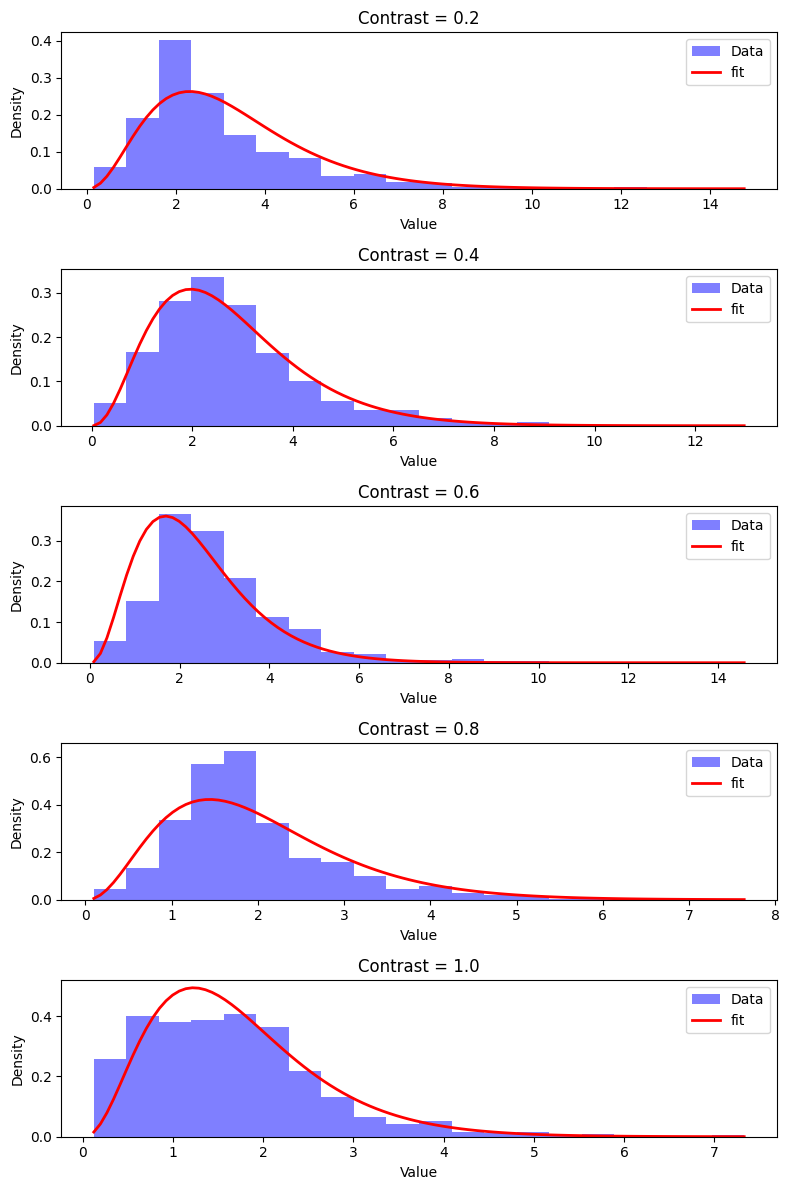

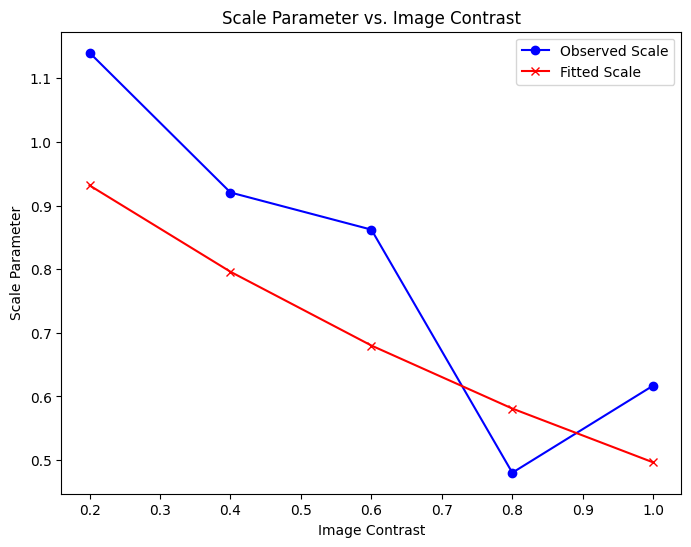

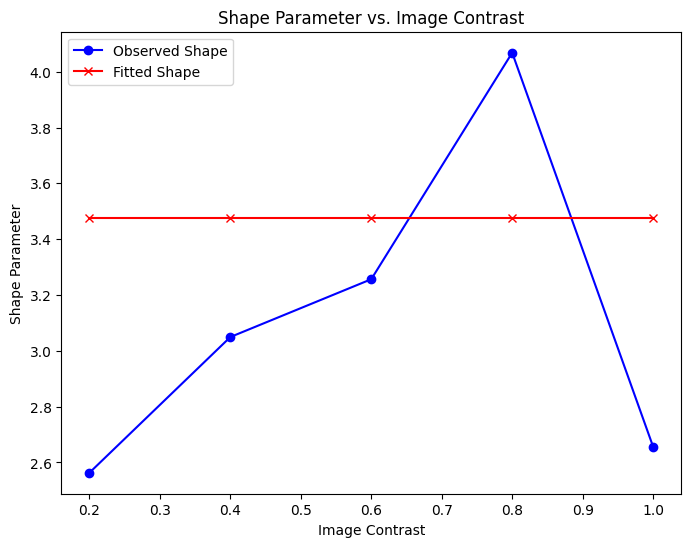

In [ ]:

# @title Gamma regression with statsmodel GLM {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm
from scipy.special import gamma as gammafunc
from scipy.stats import gamma as gammadist

def RivalryData():

    sample_size = np.zeros(5,dtype='int')

    sample_size[0] = 740;

    sample_0 = ([5.5853, 3.9241, 5.1557, 1.2603, 4.2964, 2.5778, 1.4178, 1.6756, 1.9620, 4.7117, 2.3630, 2.1052, 3.3941, 1.9763, 1.0025, 0.6731, 2.2485, 2.6352, 2.7067, 2.7497, 1.3462, 1.6899, 1.3605, 6.3730, 1.2747, 0.4296, 1.7902, 4.9552, 2.1482, 3.7665, 1.4178, 3.0505, 1.3032, 1.8474, 1.8045, 1.4465, 1.1027, 2.9072, 1.1027, 2.4924, 1.6494, 1.6127, 1.2095, 3.3354, 2.7856, 2.7490, 1.7962, 2.1992, 1.7594, 1.8326, 1.7958, 2.4191, 2.1992, 2.2358, 3.1155, 1.6860, 1.4296, 1.7958, 1.6862, 1.9793, 1.7594, 1.7593, 1.7227, 2.2358, 2.4924, 2.1992, 2.5657, 3.6286, 2.4191, 2.0892, 1.8693, 1.9793, 2.1992, 2.4191, 2.6392, 8.4669, 2.4191, 2.6757, 2.4924, 1.7960, 2.1992, 2.3459, 1.8328, 4.6183, 2.3825, 1.9794, 2.0892, 6.2677, 1.2462, 1.6860, 0.9896, 1.1363, 1.0996, 2.1991, 2.5291, 1.7227, 1.5394, 1.5394, 1.5394, 1.9426, 1.9793, 2.5291, 4.4717, 2.0892, 4.1783, 4.6183, 7.6972, 3.2621, 2.0526, 2.0893, 3.8486, 2.7121, 2.3091, 3.1888, 4.3984, 2.4924, 1.3561, 1.3195, 1.7593, 1.7593, 1.2096, 1.7228, 1.4295, 8.2836, 2.3824, 1.6860, 5.1681, 2.7122, 1.8327, 2.3091, 2.0159, 1.7227, 1.5394, 1.4294, 1.7594, 2.0157, 2.0526, 1.6127, 1.7594, 1.7961, 1.5394, 1.6860, 1.3195, 1.6860, 1.6494, 1.5394, 1.7960, 2.0892, 3.6651, 6.2308, 5.7912, 4.1785, 2.0892, 2.0892, 1.7593, 1.7593, 1.6860, 1.6128, 2.7490, 1.7593, 1.4661, 1.8693, 1.8693, 2.1992, 2.7856, 1.0263, 1.1731, 0.9896, 1.8694, 1.1729, 1.7593, 2.6390, 1.6494, 1.4296, 1.8326, 1.6494, 1.7592, 1.9794, 3.2621, 1.6494, 1.3195, 1.4295, 1.3930, 1.6494, 4.9114, 1.7593, 1.4295, 1.4294, 1.2096, 2.5290, 1.6860, 1.0263, 0.9530, 1.1729, 1.6494, 1.6127, 1.6129, 1.3928, 1.7593, 1.7593, 4.2884, 1.5028, 1.7960, 2.9689, 1.5397, 2.5291, 1.6494, 2.0526, 2.7490, 4.5450, 3.8486, 2.8589, 3.3721, 3.5899, 6.8561, 4.9481, 3.2017, 7.3412, 5.2068, 4.7540, 7.3736, 3.6221, 5.7242, 1.4877, 5.6919, 1.6170, 1.6494, 3.6221, 9.1199, 2.4255, 1.8434, 2.0698, 1.6494, 6.1123, 1.5847, 4.6570, 6.4034, 2.2315, 3.7191, 5.6272, 3.4604, 3.8808, 2.1991, 3.4604, 4.3336, 2.4255, 2.6196, 1.0672, 3.8808, 5.1421, 3.9132, 3.8485, 5.0127, 6.0476, 8.1174, 3.1370, 1.4553, 4.4306, 1.8434, 4.7217, 4.7540, 3.5251, 3.3310, 2.4255, 3.9132, 2.0372, 1.3583, 0.6792, 2.6519, 2.1991, 3.4281, 1.1644, 2.1021, 1.7787, 7.6970, 1.4876, 0.2587, 2.0374, 2.8136, 3.0076, 3.7838, 4.1395, 3.0723, 2.8460, 1.6303, 1.5397, 1.0718, 3.1399, 3.6683, 6.0836, 2.5662, 1.1171, 3.9853, 1.6757, 1.8115, 0.3321, 1.7209, 4.3476, 2.1134, 3.3211, 4.0759, 3.9853, 2.6871, 2.5814, 2.9890, 3.4871, 2.0077, 0.2264, 1.9474, 2.8078, 1.7662, 0.6340, 2.4757, 1.7209, 5.9176, 2.0832, 4.4382, 2.1738, 2.0379, 4.4231, 1.5247, 2.5814, 3.6683, 4.8321, 1.9329, 3.9480, 3.5162, 2.2002, 1.9534, 7.9165, 4.6882, 0.9253, 1.4805, 3.3517, 1.8095, 1.6861, 6.4977, 0.8636, 3.7218, 4.1330, 2.5497, 1.9329, 5.4902, 2.7142, 1.6861, 5.7780, 3.5367, 4.3798, 0.7197, 3.5573, 3.0844, 3.3517, 0.5132, 3.7289, 0.6414, 5.4565, 9.8525, 6.7308, 3.0532, 2.4460, 1.7533, 2.0783, 1.1289, 1.5138, 0.1539, 1.4368, 0.2993, 5.2170, 4.3019, 3.0447, 0.3678, 4.3789, 0.6928, 3.1559, 1.5037, 2.3630, 1.4178, 2.0480, 1.2889, 0.6874, 3.3226, 1.0311, 3.2939, 1.6326, 2.0623, 1.4608, 4.3107, 2.4919, 3.5660, 3.0361, 0.4726, 6.0579, 4.2105, 1.8904, 1.8904, 0.6445, 2.4346, 1.2030, 2.6924, 5.6569, 2.5922, 2.7927, 3.3942, 0.8593, 1.4751, 0.1575, 1.2603, 1.7329, 0.9882, 3.2223, 1.3195, 2.3458, 1.7593, 2.3091, 6.6709, 6.4509, 3.6287, 5.0213, 3.1888, 3.7752, 2.4193, 2.6024, 3.9585, 2.1992, 2.2725, 2.7123, 2.4557, 2.3826, 2.8223, 2.4923, 2.1992, 2.0892, 1.9060, 2.3092, 1.9793, 2.3091, 2.3092, 5.2781, 2.0526, 1.7593, 2.3091, 3.7386, 2.7490, 2.6390, 2.5289, 2.0892, 1.9793, 2.3091, 2.2358, 1.9426, 2.7490, 1.8692, 2.7489, 2.6757, 3.8486, 3.1887, 2.1992, 7.7338, 1.7594, 2.1625, 2.0526, 2.8589, 1.5028, 2.9689, 2.5287, 9.4198, 5.0581, 3.0789, 3.5553, 4.7283, 2.7856, 2.2725, 5.2047, 4.0685, 5.7545, 4.5083, 4.1784, 12.4254, 13.5983, 5.0948, 6.5243, 5.8278, 3.3353, 2.9322, 3.2257, 3.8486, 14.7712, 10.4095, 2.8956, 0.6964, 1.0630, 4.0685, 1.9793, 1.3562, 1.6127, 3.5553, 1.7592, 2.0892, 2.4191, 3.1888, 2.4191, 1.9794, 2.4558, 4.5083, 5.2781, 2.4191, 1.8693, 2.1993, 2.6757, 2.1626, 3.0789, 3.4454, 2.8956, 3.5187, 2.0891, 4.6916, 2.6024, 4.8382, 2.7123, 2.0892, 3.0788, 0.9530, 1.6496, 2.4193, 2.0159, 2.8956, 3.1522, 2.3091, 6.3043, 5.5713, 4.6183, 3.7386, 2.4923, 4.4716, 2.0892, 2.8589, 5.0215, 2.7490, 2.9689, 2.7123, 0.8797, 1.3195, 1.8691, 3.8486, 1.6860, 1.6494, 1.6860, 2.7123, 2.1992, 1.9058, 1.8693, 1.4296, 1.9060, 2.4190, 2.1992, 1.8693, 1.6860, 1.4661, 1.7592, 2.0160, 7.3673, 2.1992, 1.4662, 1.9426, 4.7283, 6.1211, 5.4613, 3.8486, 2.4558, 2.9689, 2.1259, 2.5291, 3.3352, 6.3776, 2.6390, 2.4191, 3.6653, 2.1259, 2.8223, 2.4191, 6.5973, 12.2054, 7.9537, 2.3458, 3.2621, 9.5298, 4.5083, 7.8437, 3.6867, 2.0374, 1.7140, 6.5004, 2.5225, 1.7140, 3.2987, 7.2442, 6.1123, 6.4034, 2.0051, 8.5378, 5.1421, 4.8510, 3.7838, 2.6843, 1.0672, 2.8783, 1.5200, 1.7140, 0.3234, 7.0825, 2.4902, 3.3957, 5.3038, 1.1966, 6.2093, 4.7540, 3.9132, 1.4553, 3.9778, 3.7515, 2.1345, 1.1643, 5.2068, 5.2391, 2.4902, 3.1370, 7.2766, 7.5028, 3.2987, 5.5302, 3.3633, 7.1795, 4.5600, 4.6893, 2.7489, 3.6868, 4.5600, 2.6519, 1.7140, 1.3260, 1.1966, 2.5225, 1.9081, 1.2613, 1.8757, 2.2315, 4.2689, 1.4553, 1.8111, 2.0373, 2.1345, 4.4953, 4.3659, 3.0400, 4.3659, 4.5600, 5.0774, 3.1047, 2.3283, 3.1852, 2.0077, 0.5887, 2.1436, 0.4076, 2.8682, 4.7401, 3.9098, 2.5059, 1.9474, 2.4002, 2.8984, 2.9890, 2.3248, 3.6382, 2.2493, 3.2909, 5.2383, 2.5361, 3.1097, 1.5851, 2.7927, 0.6944, 2.3097, 0.4982, 2.7927, 3.6230, 3.0041, 2.5210, 2.4002, 2.1134, 2.9286, 2.4757, 0.5887, 2.7022, 0.3774, 2.7776, 2.7965, 3.6807, 0.5552, 1.5422, 1.4188, 7.1763, 4.1947, 4.1330, 1.6861, 2.0974, 2.7759, 2.8582, 1.8506, 0.9870, 2.5497, 2.1590, 7.3613, 3.0638, 4.6882, 2.2619, 4.9966, 2.4058, 4.2564, 4.2564, 4.8116, 2.7348, 2.2493, 2.6427, 4.3618, 3.5835, 3.0618, 2.4888, 1.7960, 0.7783, 1.1460, 0.8125, 1.8901, 5.2170, 1.6421, 3.0789, 2.6513, 1.4112, 2.3177, 1.0349]);

    sample_size[1] = 764;

    sample_1 = np.array([2.3487, 5.2703, 0.0430, 1.6326, 3.3082, 5.1557, 2.0480, 4.1675, 3.9813, 2.6638, 0.7017, 3.3369, 3.3512, 6.5019, 1.2603, 3.9097, 6.8313, 0.9166, 6.9602, 3.5087, 3.6806, 5.5710, 0.6015, 0.7304, 5.5710, 0.8736, 0.1718, 2.2341, 3.2366, 2.1339, 3.4371, 1.2889, 3.7808, 2.1768, 1.0629, 1.3196, 1.3195, 1.8327, 1.7594, 2.0526, 4.1785, 1.9426, 2.1992, 5.4979, 2.2725, 4.1784, 2.6024, 4.9481, 3.1155, 2.6390, 2.7490, 2.1992, 2.8589, 4.6549, 3.8852, 3.1888, 3.2988, 2.3458, 5.4980, 3.1155, 2.4191, 3.3354, 1.1362, 3.2988, 2.2725, 1.5761, 5.0215, 1.9059, 2.6390, 4.4717, 2.4924, 2.7490, 3.4087, 2.5657, 7.9904, 3.0421, 2.0526, 1.9793, 1.0996, 1.8327, 1.6860, 1.7960, 1.8693, 1.8327, 2.0159, 2.0159, 2.3458, 1.7960, 2.3092, 2.8589, 2.1259, 3.3354, 2.0526, 2.2358, 2.8589, 2.3458, 2.9322, 3.0422, 2.8956, 2.8589, 1.7593, 2.3091, 2.0892, 2.6390, 1.8693, 1.8693, 2.4558, 2.6390, 3.2988, 2.7490, 3.1888, 3.5920, 6.1577, 1.9793, 2.1992, 2.3091, 2.5291, 1.9426, 1.8693, 1.8693, 1.0996, 1.2828, 1.4661, 1.3562, 1.8693, 1.8693, 1.6858, 1.6860, 1.5761, 1.6860, 1.8693, 1.8327, 1.6127, 1.6127, 1.7593, 2.8956, 2.3091, 2.2358, 2.3458, 2.7491, 1.8324, 2.4558, 2.2358, 1.7227, 1.9793, 1.7594, 2.1992, 3.1888, 2.1992, 2.4190, 2.7490, 3.7386, 4.2518, 1.4295, 1.7227, 4.3984, 2.4188, 2.5291, 2.2361, 1.7593, 1.7227, 3.2988, 8.9433, 1.3928, 1.6494, 1.5028, 1.4295, 1.4295, 1.3928, 1.5394, 1.4295, 1.4661, 1.2829, 1.8693, 2.6390, 2.1625, 1.7227, 2.0892, 2.3091, 1.5761, 1.3928, 2.0892, 1.7960, 1.7593, 2.0159, 2.7856, 1.9793, 1.9793, 1.9426, 2.4924, 2.1625, 2.2358, 3.0788, 2.2358, 1.8327, 2.3092, 1.8326, 1.6861, 1.7960, 2.3825, 1.4295, 2.3458, 2.3091, 2.4924, 2.4191, 3.3354, 2.7490, 2.7490, 2.1668, 3.8485, 3.0076, 1.4552, 2.0374, 1.7787, 6.5004, 0.9055, 2.2315, 4.2689, 3.4604, 4.4306, 3.0077, 3.3310, 3.7838, 2.3285, 6.6944, 3.5898, 4.3659, 5.8859, 3.5574, 0.5821, 1.0672, 1.2613, 1.2289, 2.3932, 2.0374, 2.9106, 0.8085, 1.2936, 3.9455, 3.5898, 3.0723, 2.4902, 2.7166, 2.1021, 1.5847, 2.8136, 1.9081, 2.1668, 2.7489, 2.0374, 2.2962, 3.6868, 2.7166, 2.5549, 1.1644, 0.9379, 1.7142, 5.4331, 3.0723, 0.9379, 1.5200, 1.7464, 1.7787, 2.1021, 2.6196, 1.4553, 2.9430, 3.1370, 4.3983, 0.8732, 4.2689, 3.8808, 3.1047, 4.0749, 1.2613, 0.8732, 4.6893, 1.0996, 1.2613, 2.1021, 0.8732, 2.7489, 1.6170, 3.2340, 2.5227, 0.3234, 1.2613, 4.0749, 2.7813, 1.9404, 1.1643, 1.8111, 4.6247, 2.5549, 2.6719, 3.6834, 4.3929, 2.3549, 3.3965, 1.8719, 2.0228, 2.4756, 3.9400, 1.1926, 0.9510, 2.9739, 3.5022, 0.4830, 5.2986, 5.3892, 2.2342, 1.6304, 1.3133, 1.3888, 1.2982, 0.4982, 1.6304, 1.5398, 1.2681, 4.1665, 6.0685, 2.4908, 3.7136, 1.0416, 1.2954, 4.5032, 1.8506, 2.3235, 0.6580, 4.3387, 4.2564, 1.0898, 0.7608, 1.9329, 3.0021, 1.3777, 0.9664, 2.5292, 0.8431, 2.3235, 1.3777, 4.8527, 1.6244, 0.9048, 0.2879, 3.3311, 1.4805, 1.6244, 3.0844, 2.2617, 3.2283, 1.3982, 2.6320, 1.0076, 3.3928, 0.2468, 4.7499, 0.8842, 2.5292, 3.5367, 2.7142, 2.4058, 3.4339, 0.5140, 3.8572, 10.9985, 4.3190, 5.0289, 0.3592, 1.6421, 3.0276, 3.3697, 1.5908, 2.9250, 5.4650, 3.2927, 5.6960, 1.5737, 2.8565, 3.8572, 3.1986, 2.8480, 2.0909, 3.1937, 2.5635, 3.0934, 3.0075, 3.1221, 2.2198, 2.2055, 2.5062, 0.6731, 1.9763, 1.4608, 0.6874, 3.1364, 3.0361, 0.5988, 1.1743, 1.0455, 2.4060, 1.0455, 0.9882, 0.9452, 2.4060, 2.1766, 1.2460, 1.5467, 0.2148, 2.1482, 0.5156, 1.8188, 0.7697, 1.6860, 2.0525, 1.1362, 2.4191, 1.9426, 4.7282, 2.1259, 2.4191, 2.5657, 2.6390, 1.5761, 3.6287, 1.5394, 3.6287, 2.1625, 3.8486, 2.3458, 2.3824, 6.8175, 4.7649, 2.3824, 2.6390, 1.7227, 1.1729, 2.6390, 3.1522, 2.3091, 3.5920, 4.6183, 2.8589, 6.4143, 3.2621, 2.8956, 3.3721, 3.1155, 3.1155, 2.7490, 5.1681, 2.6390, 2.3091, 5.4247, 1.7960, 2.0892, 1.4661, 1.8693, 1.8326, 1.9793, 2.3091, 2.0892, 2.3824, 2.1625, 2.2725, 2.3824, 3.4087, 3.0789, 4.5816, 2.9689, 3.6653, 3.9585, 3.5920, 12.9752, 2.8956, 2.5291, 5.0215, 4.9482, 1.8693, 1.0996, 3.8486, 4.0685, 4.0685, 2.6757, 3.7019, 4.3984, 3.0788, 6.5976, 4.8749, 5.4980, 3.3354, 6.3410, 4.7282, 8.7967, 8.5402, 3.1155, 3.6286, 0.9896, 1.6861, 1.8693, 1.9426, 2.1625, 2.5291, 2.0894, 2.8223, 6.4509, 2.9322, 2.1625, 2.6757, 2.4558, 3.2988, 3.6287, 7.2573, 4.9482, 4.4717, 6.4876, 2.0526, 3.1522, 6.0845, 3.1888, 4.6916, 4.1785, 2.4557, 4.5083, 5.8278, 2.6757, 2.1992, 2.1260, 3.8119, 3.4820, 5.4980, 5.3880, 2.0892, 2.6393, 3.2988, 4.4350, 4.0315, 2.2358, 0.7697, 4.5083, 3.0422, 0.8064, 2.3091, 3.5554, 2.3091, 2.3091, 3.0789, 5.1681, 2.4924, 6.2677, 9.0166, 2.7490, 2.3091, 2.0159, 2.7856, 4.2151, 3.0422, 7.0374, 3.9585, 2.7856, 2.6024, 6.3776, 2.0892, 2.6024, 4.2517, 2.3091, 2.3458, 2.5657, 4.8749, 2.5290, 3.0789, 5.3513, 8.0270, 3.2988, 2.6757, 1.6494, 4.0684, 3.5187, 6.3776, 3.4087, 3.7020, 7.6238, 6.8541, 2.8223, 4.4717, 2.5291, 1.5847, 1.1319, 0.9055, 2.1345, 1.4876, 1.8111, 2.1668, 1.4876, 1.9404, 2.6842, 4.4628, 2.8459, 2.8459, 2.6519, 2.8459, 3.6221, 1.8434, 2.4579, 2.4578, 3.5898, 3.3957, 3.4927, 0.9702, 1.2288, 0.9702, 2.4255, 0.8408, 3.0076, 1.0672, 1.1642, 2.3285, 1.2289, 2.7489, 2.5549, 2.4255, 1.2936, 1.4230, 1.4553, 2.1345, 1.3583, 1.2613, 2.5872, 1.2613, 1.9081, 0.9702, 1.0672, 2.1991, 2.8783, 3.5898, 2.8136, 0.5820, 1.4877, 2.5225, 3.3957, 6.7915, 2.8459, 2.0698, 3.6868, 2.8136, 1.5847, 2.8459, 2.5226, 2.8136, 0.2911, 4.5600, 2.7166, 2.8783, 3.0076, 3.5251, 3.7191, 4.1396, 2.6196, 3.1047, 0.7762, 1.6493, 1.3583, 1.7787, 6.2740, 4.3013, 3.1047, 4.9480, 3.1370, 7.5999, 2.4578, 3.4281, 9.3140, 2.4579, 2.6196, 3.1370, 6.5004, 4.2042, 4.3336, 4.7540, 1.9404, 3.7136, 4.9816, 6.4761, 4.4231, 1.3133, 0.3019, 0.5284, 3.1852, 2.7474, 1.9323, 0.3623, 0.9963, 0.9360, 2.0379, 3.2154, 3.2154, 7.6385, 1.4945, 2.6116, 0.2264, 3.8192, 2.2342, 10.0085, 1.2680, 2.7474, 2.1285, 0.2566, 4.4533, 3.7438, 3.2305, 1.5398, 5.9327, 8.4386, 3.0796, 2.4002, 5.0583, 1.6039, 1.7478, 2.1590, 5.6341, 4.5854, 4.5443, 2.5497, 1.7272, 2.0357, 4.4003, 1.3982, 3.0844, 1.5422, 1.4805, 0.8019, 2.9404, 3.0021, 0.4729, 3.5162, 3.9068, 2.8377, 4.4415, 2.6937, 2.8993, 3.7012, 4.5648, 2.8787, 1.0898, 4.9350, 2.3852, 0.8636, 3.4339, 0.7402, 5.3282, 6.8848, 4.2591, 0.8467, 3.1986, 1.5138, 2.9848, 3.8315, 3.0276, 3.5236, 3.1302, 1.5822, 1.6677, 2.3605, 2.2579]);

    sample_size[2] = 776;

    sample_2 = np.array([3.1650, 3.2366, 2.7497, 0.6301, 4.2821, 2.4919, 3.4371, 3.8238, 1.8045, 2.2055, 3.3369, 2.0193, 0.6015, 1.4035, 1.2746, 3.6949, 2.0193, 2.2485, 3.0504, 2.8356, 6.1868, 0.8163, 0.5156, 2.4919, 0.4440, 5.9720, 3.7952, 3.8668, 4.5112, 3.5947, 5.3991, 3.7522, 4.4682, 1.6899, 5.5710, 3.1364, 1.6127, 1.8693, 1.8327, 1.9059, 1.7227, 1.9060, 1.6494, 2.6390, 2.6390, 3.0422, 3.1888, 3.0788, 2.8589, 2.7490, 3.7020, 2.6390, 2.9322, 1.9426, 2.6024, 2.5657, 1.5394, 1.8693, 1.9425, 2.0892, 2.0892, 2.8589, 2.2725, 4.9848, 2.7490, 2.6757, 7.2573, 2.2358, 3.5187, 3.4087, 3.4821, 4.1051, 2.4924, 3.2621, 5.7179, 8.8334, 3.6286, 1.2097, 1.3195, 1.9426, 1.5761, 1.8327, 1.7593, 1.8327, 1.7593, 1.5394, 2.2725, 2.7490, 2.5291, 2.0892, 2.0892, 2.6024, 2.5291, 1.7594, 2.4924, 1.6860, 1.6860, 1.7227, 1.9793, 2.0526, 2.1992, 1.9426, 1.8693, 1.5395, 1.6860, 2.6757, 2.1259, 1.7594, 1.9426, 2.3091, 2.0892, 2.0159, 3.4454, 3.9585, 4.6183, 2.1992, 1.6860, 2.3458, 2.7856, 1.9793, 2.6389, 1.2095, 1.2829, 1.6494, 1.6127, 2.1259, 1.5761, 1.4295, 1.9060, 2.1625, 3.5187, 1.7958, 1.9793, 1.5761, 1.4296, 2.0892, 1.6860, 2.6024, 2.9689, 1.7593, 6.4876, 3.1888, 3.1888, 3.0789, 2.3458, 3.0789, 1.8693, 1.6494, 2.1992, 4.4717, 2.3824, 1.7594, 2.3458, 1.9426, 2.8956, 2.1259, 1.9793, 2.6024, 1.8693, 2.6757, 4.1784, 1.9792, 2.6390, 1.2096, 2.7490, 3.2988, 3.6286, 2.4924, 2.3091, 1.5028, 1.6494, 1.9793, 1.6494, 1.5761, 1.5763, 1.5394, 1.3195, 1.5394, 2.1992, 2.1259, 1.7227, 2.1259, 2.1992, 3.1522, 2.7123, 2.9689, 2.9322, 2.3824, 2.5657, 1.4295, 2.4191, 2.4924, 1.3195, 3.8852, 1.3192, 1.6860, 1.5394, 1.6494, 2.5291, 3.4087, 2.6024, 2.7856, 2.1992, 1.4295, 1.7227, 1.8693, 1.9426, 1.7960, 2.4191, 2.3091, 2.4191, 2.1992, 3.6287, 1.8327, 2.8223, 1.7227, 1.5523, 2.3285, 2.2638, 1.7464, 2.0374, 2.6519, 4.4953, 3.3957, 4.4306, 2.7489, 2.5225, 1.2936, 2.2962, 3.2017, 4.2366, 1.9727, 3.1047, 1.9081, 1.0672, 1.4553, 4.5923, 4.6570, 4.2366, 4.1072, 2.2315, 3.1693, 1.9081, 1.5847, 0.9055, 2.6519, 6.6944, 3.2987, 3.5898, 3.6868, 0.1940, 2.2961, 1.2613, 3.6221, 2.2315, 3.2340, 2.1345, 4.2042, 5.1097, 2.5872, 3.6868, 4.0749, 0.7438, 0.9702, 2.7166, 14.5855, 6.0153, 5.8859, 9.7344, 6.9208, 4.8511, 6.0476, 9.0229, 4.5600, 4.5600, 6.3710, 4.4630, 4.9804, 0.6791, 0.2264, 0.7762, 0.5174, 1.6817, 0.8732, 2.5225, 0.5498, 4.1719, 1.6170, 2.7167, 2.7166, 1.5847, 1.1643, 6.4034, 1.0349, 1.8434, 1.1641, 2.3285, 1.0349, 1.9404, 1.4230, 1.5200, 1.7464, 0.8732, 0.9058, 0.8303, 0.7548, 1.2530, 0.8152, 2.1738, 2.5210, 3.9098, 1.9927, 0.4529, 2.0077, 3.8042, 2.0379, 2.8682, 2.1436, 4.4231, 1.2379, 0.3472, 3.1248, 4.7703, 0.7246, 3.7589, 0.8001, 1.6002, 4.1815, 1.7360, 1.9323, 4.5740, 3.7589, 3.7740, 3.9400, 3.1852, 4.9212, 2.9739, 2.2413, 3.3928, 0.9664, 3.8863, 4.8527, 2.1179, 2.9610, 2.6525, 1.2954, 2.0974, 1.6245, 1.6244, 7.5465, 2.2207, 2.4880, 1.5833, 0.4318, 1.8506, 3.0227, 1.3571, 3.2694, 2.4264, 3.7424, 1.6861, 2.7348, 2.1590, 2.9610, 1.6039, 2.8052, 4.1480, 4.2677, 2.2835, 4.4644, 1.4881, 4.1309, 2.9934, 0.3079, 2.8223, 3.6263, 1.6421, 1.1802, 4.5927, 2.1809, 3.5407, 1.1118, 2.0098, 2.8309, 1.4112, 1.9500, 1.6934, 3.2157, 3.0019, 1.4608, 2.9788, 3.2366, 2.5922, 2.1912, 3.5087, 1.5897, 2.8929, 1.6756, 2.7497, 1.9334, 1.2889, 2.6208, 2.0050, 3.4228, 2.7354, 1.3319, 1.8904, 3.4228, 2.6638, 3.0504, 2.7354, 0.5012, 2.1482, 3.2223, 1.7329, 2.4489, 0.0859, 2.3344, 3.2254, 1.6494, 1.6860, 1.7593, 1.6494, 5.0581, 2.4924, 2.5291, 2.5657, 2.7856, 3.2988, 3.9952, 3.4820, 5.8645, 2.6390, 3.2988, 3.3354, 3.6653, 2.4191, 4.5450, 3.1522, 3.0055, 1.8693, 1.8327, 0.7697, 2.0892, 1.7594, 3.0789, 2.4557, 2.4191, 2.1625, 2.1992, 3.1888, 4.5816, 1.6494, 2.5657, 2.9689, 3.1155, 2.3458, 4.0318, 2.6024, 3.7017, 2.0891, 3.0055, 3.6286, 2.7490, 2.3091, 2.4557, 3.1888, 2.1992, 2.0159, 3.0789, 2.3091, 3.1888, 2.8589, 4.9848, 5.2780, 2.3091, 3.9952, 5.0581, 5.1314, 2.7856, 2.8589, 3.2255, 4.5083, 7.7338, 6.4876, 3.6287, 4.5082, 4.3617, 4.9115, 3.2621, 2.4557, 3.9585, 2.3091, 2.4557, 4.6916, 4.8382, 3.5920, 3.7386, 2.7490, 2.3824, 8.5402, 3.7386, 3.4088, 5.6446, 1.5761, 1.8693, 2.1259, 2.5291, 1.8327, 2.0159, 2.2725, 1.9793, 2.9689, 2.6392, 2.0892, 5.1681, 2.0892, 1.8325, 4.1785, 5.3880, 3.5187, 2.0892, 3.6287, 2.9689, 2.6757, 2.7856, 2.6024, 5.0215, 3.4087, 2.0892, 2.1258, 1.9793, 2.5657, 1.8693, 2.4191, 2.9689, 3.2988, 8.6501, 2.0892, 2.6757, 4.3250, 2.7490, 2.3091, 2.1625, 2.7490, 0.6597, 0.9163, 2.2725, 1.6494, 2.5657, 1.9792, 1.0263, 1.4295, 1.7594, 2.0159, 2.4191, 4.0318, 5.1312, 3.4087, 3.2988, 3.6287, 3.7386, 2.6024, 2.3091, 3.8119, 2.7856, 3.2255, 3.5187, 2.4558, 2.4558, 2.5291, 2.7856, 2.7856, 3.1522, 3.6286, 3.1888, 11.5091, 1.8327, 1.8693, 2.5291, 2.4191, 2.1992, 8.7601, 3.0055, 3.2255, 3.9585, 3.9952, 2.8589, 3.1522, 2.8589, 3.1888, 2.9689, 3.6287, 2.6390, 2.6757, 3.8852, 4.0685, 1.1966, 1.3906, 1.4553, 1.6170, 1.5523, 2.2638, 3.2987, 1.7142, 4.5600, 1.1643, 5.4332, 4.2689, 2.9106, 2.8136, 4.4630, 1.4553, 3.0076, 3.0076, 3.5573, 2.1345, 8.1821, 4.3659, 3.7838, 5.9183, 1.5523, 1.9727, 2.8136, 1.6494, 1.5523, 3.5898, 3.2017, 5.3361, 3.4927, 1.2938, 4.4630, 1.9404, 1.2613, 3.5898, 1.0026, 3.0076, 1.5200, 3.2987, 2.8136, 3.4281, 1.0026, 2.8783, 1.0672, 3.8485, 4.9481, 4.1072, 2.0374, 4.2042, 0.7762, 8.0527, 4.0102, 5.1098, 4.4630, 5.5302, 3.1370, 4.5923, 4.3983, 1.9404, 8.6348, 5.6595, 1.4877, 2.6196, 5.2391, 3.8485, 2.3285, 2.2638, 9.9285, 0.6791, 0.9379, 0.9702, 1.3583, 0.8732, 1.9404, 3.6868, 2.9106, 3.4281, 2.6519, 9.1523, 3.7515, 1.3260, 2.2315, 2.8783, 2.8136, 1.4877, 1.0025, 2.1021, 2.6519, 2.1345, 1.2228, 1.2228, 1.2681, 2.2493, 0.8152, 2.2946, 2.9739, 3.5022, 2.4606, 2.5814, 0.4982, 3.7890, 4.6193, 1.4945, 1.2681, 2.8229, 1.5851, 2.8531, 2.8984, 2.6267, 4.3174, 1.9927, 2.4002, 2.7173, 2.5059, 1.8568, 1.8719, 3.8494, 5.6308, 3.8041, 4.6344, 2.8078, 5.8723, 0.6793, 0.4529, 4.8527, 3.7835, 3.3928, 3.5162, 6.1481, 1.4599, 1.3982, 1.9123, 3.2694, 2.5292, 3.6190, 0.9664, 7.5875, 6.2304, 3.4339, 4.6265, 4.9966, 4.6265, 2.2824, 6.6622, 3.8863, 2.4881, 3.6395, 3.3517, 2.1179, 2.7554, 3.5573, 2.9815, 2.1590, 4.1330, 1.8730, 2.4375, 0.2138, 3.5578, 2.1894, 1.5394, 1.0605, 1.4112, 2.1723, 4.0368, 1.4710, 1.1546, 0.8210, 2.0269, 0.5474, 1.5223, 1.0263, 0.7184, 1.7019, 1.4368, 2.7796, 1.4881]);

    sample_size[3] = 1159;

    sample_3 = np.array([0.5729, 2.5778, 3.8811, 1.0311, 2.7927, 2.2485, 0.9882, 2.9931, 0.6445, 1.8904, 3.2080, 3.3512, 0.8450, 3.4801, 1.6326, 1.9620, 2.0766, 1.2889, 2.3918, 1.0311, 1.7615, 1.5181, 2.2485, 4.0100, 0.9882, 2.3057, 6.1009, 5.1557, 5.4278, 0.9452, 1.3748, 6.1439, 2.1482, 2.8356, 3.7952, 2.1339, 1.5324, 2.7497, 1.0263, 1.2096, 1.4295, 1.3194, 1.3928, 1.4661, 1.2830, 1.3928, 1.6863, 1.7960, 1.5394, 1.7227, 1.4295, 1.5394, 1.5761, 1.6860, 1.5394, 1.5394, 1.6127, 1.7593, 1.8693, 1.4295, 1.4295, 1.3562, 1.5394, 1.8327, 1.3195, 1.2462, 1.4661, 1.5761, 1.5394, 1.6494, 1.5394, 1.7960, 1.8327, 1.2096, 1.6860, 3.5553, 1.7593, 1.5761, 1.5028, 1.7227, 1.6494, 1.5394, 1.4295, 1.3562, 1.7593, 1.8693, 1.6494, 1.7593, 1.9060, 2.0159, 1.9426, 1.9059, 2.0892, 1.6494, 1.9793, 1.8693, 1.8326, 1.8693, 1.8327, 2.0526, 1.5761, 1.9793, 1.8693, 1.4295, 1.5761, 1.8693, 1.5395, 0.7697, 0.7697, 1.2096, 1.0996, 1.0263, 1.5028, 1.0265, 1.1729, 1.3928, 1.0996, 1.2096, 1.4295, 1.3928, 1.0996, 1.2096, 1.3562, 1.4294, 1.1729, 1.4295, 1.0263, 1.5028, 3.4820, 1.5028, 1.4295, 1.3195, 1.3928, 1.3195, 1.6494, 1.2462, 1.6494, 1.4298, 1.3195, 1.7593, 1.7593, 1.4661, 1.8327, 1.5028, 1.5761, 1.7960, 1.6494, 1.7593, 1.4661, 0.6598, 1.5028, 1.2829, 1.5028, 1.1362, 0.6598, 1.5028, 1.1362, 1.5761, 1.3928, 1.1362, 1.3195, 1.7593, 2.1625, 1.8693, 1.9793, 1.9793, 1.9793, 1.9060, 1.9793, 2.0159, 1.3195, 1.4661, 1.2829, 0.8064, 1.0263, 0.8797, 1.0996, 1.0629, 1.0263, 1.0996, 1.0996, 1.3195, 1.5394, 1.4661, 1.2095, 1.2095, 1.0996, 1.3195, 1.2096, 1.2095, 1.2096, 1.6494, 1.6494, 1.3195, 0.9896, 1.3195, 1.5028, 1.2095, 1.3562, 1.3195, 1.5394, 1.9793, 1.2096, 1.2462, 1.3562, 1.2095, 1.2095, 1.0996, 1.2829, 1.0996, 2.3091, 1.2095, 1.1729, 1.3928, 1.5394, 1.7960, 1.0263, 0.8797, 1.4661, 1.2462, 1.6860, 1.4295, 2.1992, 3.0788, 1.6127, 1.9793, 1.5394, 0.8797, 2.7490, 1.0996, 0.8064, 1.2096, 1.4295, 1.2096, 0.5498, 1.3928, 1.1729, 2.0892, 2.1625, 1.4295, 1.9793, 1.0996, 1.1362, 1.3562, 1.2829, 1.2462, 1.5028, 1.4295, 1.0996, 1.5394, 1.5394, 1.3195, 1.4661, 1.2462, 1.4661, 1.5394, 1.4295, 1.2829, 1.2095, 1.2095, 1.0996, 1.3195, 1.6860, 1.6494, 1.7227, 1.6494, 1.4661, 1.5394, 1.7593, 1.6494, 1.4662, 1.5394, 1.3195, 1.5394, 1.9793, 1.9793, 2.7856, 1.7960, 0.8064, 1.7960, 2.0526, 1.8327, 1.7227, 1.4661, 1.5394, 1.5028, 1.3928, 1.6860, 1.3195, 1.5028, 1.5761, 1.6494, 1.5394, 1.6494, 1.7593, 1.7227, 1.7227, 1.6127, 1.7227, 1.7227, 1.9060, 1.9426, 1.7593, 2.3458, 1.9793, 1.4295, 1.7227, 1.5394, 2.0892, 2.0159, 2.0892, 1.5394, 1.7227, 2.0892, 1.6127, 1.9060, 1.9793, 1.8327, 1.9793, 2.1992, 1.6494, 1.9793, 1.9060, 2.1259, 2.0051, 2.1668, 1.4876, 1.6170, 3.7838, 1.4553, 0.9702, 3.0723, 2.2315, 3.0076, 1.7141, 2.5872, 2.1668, 1.3259, 3.8808, 1.8757, 1.9728, 0.6791, 2.1668, 2.3285, 1.3583, 2.2962, 1.8757, 2.1668, 3.1370, 2.7166, 3.1694, 1.0025, 1.4553, 0.8409, 1.5200, 1.5523, 1.8111, 2.2315, 1.9728, 1.4553, 2.1345, 1.3259, 2.7163, 2.5225, 1.3260, 2.2638, 1.6817, 1.2613, 1.9081, 4.1719, 2.6195, 2.5549, 2.2315, 2.7489, 1.5523, 1.1966, 3.2987, 2.2962, 2.6519, 3.2664, 1.3260, 2.7489, 3.2987, 3.2987, 4.5923, 3.4604, 2.6842, 2.4255, 0.7438, 1.0025, 3.2987, 3.7838, 2.8136, 4.5276, 3.1047, 4.9481, 2.2315, 1.4553, 1.0996, 1.7787, 0.7762, 1.2289, 1.5523, 1.9404, 1.9081, 3.1047, 3.0076, 1.7140, 0.9702, 3.6868, 2.6844, 4.1716, 0.8732, 3.7515, 1.1643, 2.5549, 2.0374, 2.0374, 3.0076, 1.3906, 2.8136, 2.9753, 3.9778, 1.6493, 1.6493, 2.7166, 2.3285, 2.1021, 3.3633, 2.0698, 2.1991, 3.2017, 2.7813, 1.4553, 5.2715, 3.2664, 4.3659, 2.9106, 1.9404, 2.6519, 3.1370, 4.7540, 1.6817, 4.6247, 4.2689, 2.7813, 0.9055, 0.3557, 0.6791, 0.4528, 0.7762, 0.9702, 1.1643, 1.6493, 1.3583, 2.2638, 1.0349, 1.0672, 1.4553, 2.1021, 1.2613, 0.9379, 0.7761, 0.8408, 3.9778, 1.1966, 1.0349, 2.4255, 2.7166, 1.8434, 2.3608, 0.9702, 2.0698, 1.8434, 3.1047, 2.8459, 1.1171, 1.5398, 2.1285, 3.1248, 1.7964, 3.2607, 1.6907, 2.4002, 1.3133, 2.9890, 1.9927, 2.2191, 2.5361, 1.4492, 0.5434, 1.3586, 3.1248, 2.1436, 3.0343, 0.2415, 1.2077, 0.5284, 0.7699, 0.3774, 1.2228, 3.0343, 0.4227, 1.6002, 4.9363, 6.1591, 1.5851, 0.6340, 0.6793, 1.4190, 0.2717, 0.9058, 1.3435, 2.2644, 2.4757, 0.6038, 2.9588, 2.6569, 1.1104, 0.9253, 1.1926, 1.2954, 3.2077, 3.1666, 1.1104, 1.5216, 1.0487, 2.1590, 1.6244, 1.3571, 3.1872, 2.0357, 1.4807, 0.3701, 1.7683, 3.1872, 3.2927, 1.4625, 2.3862, 0.8467, 3.4124, 2.3519, 2.8993, 1.8559, 1.7704, 1.8644, 0.6158, 0.9493, 0.9836, 0.7954, 1.1375, 1.6421, 3.2243, 2.8736, 2.1210, 2.8822, 3.9256, 1.4796, 1.1289, 1.2059, 1.1717, 1.7105, 0.8980, 1.0520, 1.1375, 1.8987, 0.3849, 0.5901, 0.9664, 0.9452, 3.4371, 1.3749, 2.0766, 1.8475, 0.3867, 1.9763, 1.5181, 3.4371, 2.3057, 1.3032, 1.1742, 1.1887, 2.1052, 1.9477, 0.6445, 0.8306, 0.6158, 0.2005, 1.8475, 2.6065, 4.6831, 1.2889, 2.6781, 1.3319, 1.2030, 1.8188, 3.9527, 2.4060, 4.2964, 1.1600, 2.8786, 1.4178, 0.6597, 1.1729, 1.5394, 1.8694, 1.7960, 1.8693, 1.8693, 1.7958, 1.5394, 1.7225, 1.5394, 2.3458, 1.8693, 2.1259, 2.0526, 1.8327, 1.9426, 1.6860, 2.4191, 1.9793, 1.8693, 2.0892, 2.3091, 2.5291, 2.4924, 3.9951, 3.5187, 1.7593, 2.0526, 2.1625, 1.7593, 1.9426, 1.9059, 2.0892, 2.3091, 5.4979, 2.9689, 4.5816, 0.7331, 1.9793, 2.6390, 1.7960, 1.7593, 2.0892, 1.7594, 1.7593, 1.8327, 1.6494, 1.8693, 1.7593, 1.8693, 1.9426, 2.1992, 1.9793, 2.5291, 2.4191, 1.8693, 2.6757, 2.5291, 2.0892, 1.7960, 2.0159, 1.3195, 1.6127, 2.3458, 2.3824, 1.8693, 2.0892, 1.8326, 0.9163, 1.3928, 1.2096, 1.6494, 1.7593, 1.8693, 1.8693, 1.8691, 1.7960, 1.7593, 1.7593, 1.7593, 2.0159, 1.7960, 2.2725, 1.8693, 2.2725, 2.0159, 1.9060, 1.5394, 1.7594, 2.2358, 2.0159, 4.2151, 2.1625, 2.0159, 2.3091, 2.5291, 1.7227, 2.4924, 2.8589, 1.6494, 2.4188, 2.0892, 1.7960, 1.9426, 2.3091, 2.1259, 1.9793, 2.2725, 3.9219, 2.6390, 2.1992, 2.9322, 1.6860, 2.2725, 3.9952, 1.9793, 3.9219, 3.0055, 2.0892, 2.2725, 3.0789, 2.5291, 2.9322, 2.4191, 2.6757, 2.3091, 2.8589, 2.3091, 2.4191, 2.7490, 2.4191, 2.9322, 2.3458, 2.5657, 3.9219, 2.3091, 2.4191, 0.8430, 1.8326, 1.7227, 1.6494, 1.4661, 1.8693, 1.5028, 1.6494, 1.7593, 1.5394, 1.6494, 1.5028, 2.0892, 1.8693, 1.7593, 1.9792, 1.5394, 1.4661, 1.8326, 1.6494, 1.4661, 1.3928, 1.9060, 1.6494, 1.5394, 1.7593, 1.7593, 1.6494, 2.6390, 1.7593, 1.5394, 2.0526, 2.0526, 1.8693, 1.7960, 2.4191, 1.7593, 1.8693, 1.7593, 1.7960, 1.9059, 1.5761, 1.6127, 1.7227, 1.5028, 1.3195, 1.5028, 1.3928, 1.3928, 1.5394, 1.5394, 1.7227, 1.5761, 2.3825, 1.5394, 1.9793, 1.0263, 2.4191, 1.7593, 2.1992, 1.9426, 2.4191, 2.4191, 2.1259, 1.5761, 1.6494, 2.8956, 1.7593, 2.1259, 1.7227, 1.3928, 1.4295, 1.8693, 2.1992, 2.3458, 2.1259, 1.7593, 2.7490, 1.4295, 1.3928, 1.5028, 1.6494, 1.5028, 1.5761, 1.3562, 1.3195, 0.9896, 2.0892, 1.5394, 1.3928, 1.5761, 1.7960, 1.6127, 2.0526, 1.7960, 1.7227, 1.8693, 1.7226, 1.8693, 1.6494, 2.0892, 2.1992, 2.3091, 2.0526, 2.2725, 1.5028, 2.5291, 3.7753, 1.5394, 2.1625, 2.6390, 1.9793, 1.5761, 1.8693, 2.2725, 3.9952, 2.0892, 1.7227, 1.8693, 2.0892, 1.6494, 1.9793, 1.3561, 1.4661, 1.7960, 1.5761, 2.0892, 1.5394, 1.6494, 1.5761, 1.8693, 1.4295, 1.4295, 1.4661, 1.4295, 1.8693, 1.9793, 1.9792, 1.7227, 1.4661, 1.6494, 1.5761, 1.7593, 2.1625, 1.9060, 2.0892, 1.8693, 1.6494, 1.9793, 1.7593, 1.7227, 2.7493, 1.3583, 2.4255, 1.6170, 1.5523, 2.6519, 1.7464, 2.1991, 2.5549, 1.0349, 1.7787, 2.9106, 2.1991, 1.5523, 4.5923, 1.2936, 3.4281, 3.3634, 3.3634, 2.0051, 1.6817, 2.5225, 2.4255, 2.6196, 2.1344, 3.0400, 3.7838, 3.4281, 0.9055, 1.5200, 1.2936, 4.8510, 1.0996, 2.2638, 1.0996, 1.7464, 2.1991, 1.2613, 3.2987, 2.1345, 2.1021, 1.5523, 2.0374, 4.8510, 1.7464, 2.1991, 0.9379, 0.1617, 2.3285, 2.1021, 1.9404, 2.6842, 2.7166, 1.1643, 1.8434, 2.6196, 2.9106, 2.0698, 1.1966, 3.9132, 1.9727, 3.5251, 1.6817, 0.6791, 1.2613, 2.8136, 1.6494, 2.5226, 3.5574, 1.3259, 3.0076, 1.8111, 2.2638, 3.5574, 3.2987, 3.6546, 4.0749, 4.0749, 2.4579, 3.0076, 3.2664, 0.9055, 1.1319, 1.0025, 1.6494, 1.3583, 2.4255, 1.6494, 1.7464, 2.8136, 2.1345, 2.0374, 2.8783, 3.7838, 4.0749, 3.5898, 1.0349, 3.1047, 0.8085, 2.6196, 0.5820, 5.0451, 4.5276, 3.2017, 2.0374, 2.0051, 4.8510, 6.5327, 0.6792, 1.3260, 3.0723, 2.7489, 2.7489, 2.1668, 2.9430, 0.8408, 3.1047, 1.3583, 1.5847, 2.3608, 0.0970, 4.4953, 3.2017, 2.9106, 1.1319, 3.0076, 3.2987, 2.8136, 4.2042, 3.3957, 1.1319, 2.5225, 2.8136, 2.9430, 2.2315, 0.3881, 0.8085, 0.3234, 0.5821, 0.7438, 1.0025, 1.0996, 1.2936, 0.5821, 0.8408, 0.9702, 1.0672, 0.4204, 0.9702, 1.1966, 2.7166, 2.1345, 2.8783, 4.0749, 1.0673, 2.7489, 1.6170, 1.2613, 2.3285, 2.4255, 1.7464, 2.3932, 1.4877, 3.5251, 2.7166, 1.5700, 1.0416, 3.7136, 3.0343, 4.4232, 3.8947, 3.2305, 2.5059, 3.0947, 1.1020, 1.6304, 3.8494, 1.9776, 1.5549, 1.1775, 0.4378, 0.9058, 0.6793, 0.4076, 1.0718, 1.3133, 3.3512, 1.9021, 0.4831, 1.0416, 1.3888, 1.4039, 1.4945, 1.6454, 5.2534, 4.2117, 7.6385, 1.3435, 1.0416, 1.4492, 1.3133, 1.3133, 1.3586, 1.6153, 0.7246, 3.7437, 0.9963, 0.6793, 1.0416, 0.9510, 0.9870, 2.4880, 0.9459, 1.4599, 7.0323, 7.3613, 5.3668, 1.4188, 2.1590, 3.3311, 2.8170, 0.6374, 3.5162, 4.0096, 4.3798, 1.8506, 5.0583, 5.1817, 4.6060, 0.7402, 0.6786, 1.3777, 1.0898, 0.8636, 0.4935, 0.8431, 0.3496, 1.1722, 1.0006, 1.6677, 1.0947, 2.8993, 0.6756, 1.1888, 2.4033, 1.4283, 0.8724, 0.5645, 2.1210, 0.5388, 0.4105, 1.6677, 1.3598, 0.6243, 1.4881, 1.0776, 3.3355, 4.9605, 1.8302, 3.0532, 1.1802, 1.4454, 2.0013, 0.9835, 1.1289, 2.6684, 1.5309, 1.6335]);

    sample_size[4] = 958;

    sample_4 = np.array([0.4296, 0.8163, 0.7590, 1.0311, 1.7186, 1.0168, 2.6208, 1.2030, 2.2341, 1.0311, 0.8163, 0.6015, 1.9620, 1.5753, 1.2030, 2.1768, 1.3462, 2.7783, 3.8381, 2.7497, 3.8524, 1.9763, 3.6519, 0.8593, 4.6401, 0.9022, 0.4726, 2.9788, 2.0623, 1.2030, 4.0959, 3.7808, 0.7733, 1.9763, 1.6756, 1.2460, 3.7665, 3.8811, 2.9502, 2.8356, 1.4894, 2.0480, 0.7161, 3.1937, 1.5037, 3.8668, 3.5230, 1.3195, 1.0263, 0.9896, 1.3195, 1.8327, 1.5394, 1.3928, 1.9793, 2.2725, 1.9793, 1.8693, 2.6024, 1.6127, 1.4295, 1.9060, 1.6127, 1.3562, 1.4295, 1.3928, 1.5394, 1.2095, 1.4661, 1.3562, 1.7593, 2.3091, 1.6860, 1.2462, 1.9060, 1.2828, 1.3195, 2.0526, 0.8797, 1.4295, 1.6860, 2.2725, 0.8797, 1.2095, 1.3193, 1.3562, 1.3928, 1.2097, 1.6127, 1.8693, 1.6860, 1.4295, 2.3091, 2.0159, 1.6860, 1.6494, 3.8486, 1.4661, 1.6494, 2.0159, 1.5394, 0.8797, 1.8327, 1.5394, 1.4294, 1.3195, 2.1259, 1.6494, 1.5394, 1.8693, 1.1729, 1.5394, 1.3195, 1.4295, 1.2096, 1.5028, 1.4295, 1.6494, 1.5394, 1.2095, 1.2096, 1.5028, 1.3928, 1.6860, 1.7960, 1.7593, 1.5395, 1.5761, 1.5394, 1.6494, 1.7225, 1.8326, 1.5761, 1.6127, 1.6860, 1.9793, 1.9426, 1.7960, 2.0892, 1.6857, 1.9793, 1.9793, 2.6390, 1.9426, 1.9792, 2.8585, 2.0526, 1.9792, 2.0892, 1.8693, 2.6390, 2.3091, 2.9689, 2.5291, 2.8589, 3.8486, 3.5187, 1.7593, 1.6494, 1.7960, 2.0892, 2.2358, 2.3824, 2.0892, 1.7960, 1.6860, 1.7593, 1.9792, 1.6857, 2.2358, 1.7593, 1.6494, 4.0318, 1.9793, 1.5394, 1.4661, 2.4924, 1.9792, 2.1992, 1.7960, 1.8693, 2.7490, 2.0159, 2.2725, 1.9793, 2.0892, 2.4191, 1.6494, 1.3561, 1.7593, 1.2462, 2.0892, 2.1992, 1.2829, 0.2199, 1.4295, 2.0159, 2.1259, 1.9426, 3.3354, 2.4557, 2.4191, 1.0263, 1.1362, 1.4661, 1.6127, 1.3195, 1.4661, 3.1888, 3.3720, 2.6757, 3.0055, 3.8852, 3.7020, 1.2462, 1.7960, 1.6494, 1.7227, 1.9059, 1.6127, 1.6494, 1.5394, 1.1362, 1.0629, 1.6860, 4.1051, 1.9793, 3.7386, 1.6494, 2.0526, 5.6079, 1.7593, 1.9793, 2.1259, 2.0526, 2.0892, 1.7591, 2.3091, 2.6024, 2.4191, 2.3458, 2.1259, 1.8693, 2.0892, 1.8693, 2.7490, 3.1888, 2.6390, 2.8589, 3.2988, 3.2988, 3.3354, 1.9793, 3.1522, 2.5291, 1.8693, 2.4924, 2.3091, 4.5449, 2.4191, 3.3721, 2.6756, 2.6390, 4.6183, 1.8757, 2.1668, 1.2613, 1.3259, 1.5847, 0.9702, 1.5523, 0.8732, 0.7115, 0.6792, 2.3932, 1.8757, 1.5200, 1.2289, 0.4851, 0.6468, 1.4553, 0.8732, 0.6468, 0.6468, 0.4851, 0.5174, 0.9379, 1.0349, 0.9055, 1.2613, 0.8085, 0.5498, 0.6467, 1.4877, 0.4204, 0.3234, 0.3234, 0.4851, 0.4851, 0.4851, 0.5821, 0.8408, 0.8409, 0.8085, 1.0672, 1.0349, 1.3259, 0.7115, 0.5175, 0.7438, 0.8409, 0.5498, 0.8085, 1.1319, 1.2289, 0.4204, 0.3558, 0.3234, 0.3881, 0.2911, 0.6468, 0.5821, 0.3234, 0.7761, 1.0672, 0.6145, 0.6145, 0.4528, 0.6791, 0.5498, 0.6468, 0.7762, 0.4528, 0.6145, 0.9702, 0.7115, 1.0025, 1.1020, 0.8907, 0.9058, 1.0416, 0.9058, 0.9510, 0.5435, 1.2983, 1.2681, 1.1775, 1.4039, 1.6454, 1.2379, 0.8605, 1.3133, 1.8115, 1.1775, 1.8568, 1.8719, 1.0567, 1.1171, 1.7661, 0.4831, 1.0869, 1.0869, 0.8454, 0.6038, 1.5247, 1.2530, 2.7022, 0.8152, 1.1473, 1.3586, 1.0567, 1.1775, 1.1473, 1.1473, 0.7095, 0.7850, 2.2191, 1.2228, 0.7699, 1.1473, 1.2077, 0.7095, 3.6381, 1.2379, 1.3133, 0.4680, 0.2264, 0.7397, 2.0379, 2.4455, 2.0832, 1.7813, 0.1510, 2.2191, 1.9474, 0.4982, 0.8605, 1.4341, 0.2717, 0.3019, 2.0379, 2.8531, 1.1322, 0.3701, 0.6786, 0.2056, 2.1385, 0.4729, 0.5963, 0.8225, 1.1104, 0.9322, 0.6414, 0.7868, 1.1802, 1.2914, 0.7954, 0.9237, 3.3697, 2.5230, 1.7533, 1.9842, 2.0954, 1.4026, 0.8552, 1.2059, 3.5664, 2.2921, 1.0006, 1.4112, 0.2993, 0.8553, 1.1118, 0.7184, 0.4533, 0.5388, 0.3506, 0.5987, 0.4875, 0.4362, 0.3507, 0.3849, 0.2908, 0.3507, 0.2993, 0.3592, 0.4618, 0.4105, 0.4105, 0.5303, 0.5901, 0.4618, 0.3592, 0.5474, 0.2822, 0.3335, 0.7441, 0.4704, 0.8809, 0.7441, 0.8895, 0.4447, 0.4362, 1.0434, 0.5729, 1.7759, 2.4490, 0.1289, 2.0336, 1.3605, 2.3057, 1.0025, 1.9763, 2.7927, 1.5037, 1.1600, 2.3773, 1.2460, 2.9216, 2.2914, 2.1625, 1.7615, 1.3748, 1.6040, 0.5156, 1.1600, 1.3748, 2.7783, 0.9309, 0.9452, 2.8786, 0.8163, 1.0741, 0.4726, 0.7734, 2.5492, 1.8475, 1.9047, 0.9309, 0.7304, 2.1482, 0.3437, 1.7329, 1.6613, 1.2889, 1.8045, 1.7329, 1.5394, 1.7593, 1.6127, 2.4191, 1.7960, 1.8693, 1.5761, 1.7593, 1.7960, 1.7593, 2.3091, 2.5657, 2.1259, 1.7593, 1.9793, 1.8693, 2.4191, 2.2725, 2.1259, 2.1992, 1.7594, 1.9793, 2.8223, 2.0892, 1.9426, 2.0892, 2.0892, 1.7227, 1.8694, 1.9792, 2.7856, 1.5394, 3.4454, 4.9115, 6.2676, 2.2358, 1.9426, 1.8693, 1.9795, 1.9793, 1.9793, 2.0159, 2.0891, 1.5761, 2.4191, 1.9060, 2.0526, 1.5761, 1.9793, 2.2725, 2.3091, 2.3824, 2.6390, 2.1625, 2.1992, 1.6494, 1.2095, 2.1259, 1.6494, 1.7594, 1.9793, 3.7386, 3.5920, 2.7490, 2.7856, 0.9163, 2.1992, 2.3091, 2.2358, 2.6023, 2.4557, 2.8589, 3.0789, 3.2988, 2.7856, 2.0526, 2.8222, 1.7960, 2.3091, 2.3824, 3.9219, 3.7752, 2.4923, 3.1521, 4.1784, 2.7858, 3.1155, 3.0788, 2.4191, 0.4398, 1.9426, 2.0159, 2.4191, 2.5290, 2.8226, 2.9322, 2.6390, 2.1992, 2.7856, 2.3091, 2.5295, 3.5920, 2.4191, 2.4191, 2.6390, 1.3195, 1.8693, 2.6390, 2.6390, 3.4087, 3.2988, 2.6390, 2.8589, 2.5291, 1.5761, 2.2725, 7.0007, 3.1888, 4.2151, 2.3091, 1.1362, 3.6653, 1.6127, 1.8326, 1.8693, 1.8697, 2.3824, 2.0526, 1.7593, 2.4557, 2.3091, 1.5394, 1.9793, 1.5394, 2.1259, 2.1625, 1.9793, 2.0526, 2.0892, 0.8797, 1.4295, 1.6494, 1.8693, 5.1314, 2.0526, 1.3195, 1.6127, 1.7594, 1.3928, 2.0892, 1.7960, 1.9426, 4.9481, 2.7123, 1.2829, 5.6079, 1.9793, 1.7227, 1.9426, 3.0788, 4.6183, 2.1625, 1.8693, 0.9530, 2.3458, 1.6860, 2.0526, 3.1521, 3.8852, 5.8278, 3.0422, 7.3306, 2.5290, 2.7490, 1.8327, 1.6127, 1.5761, 2.4191, 1.9793, 1.9793, 1.7593, 1.8693, 3.0789, 2.3091, 5.2780, 2.9322, 1.7960, 2.3824, 2.4557, 3.3354, 2.1992, 2.1625, 2.1992, 2.6390, 1.9059, 2.3094, 3.8119, 3.3354, 2.6390, 2.9689, 2.1625, 2.0892, 1.8693, 2.8589, 3.5187, 2.4191, 2.6390, 2.7490, 2.9689, 3.8486, 2.1992, 4.1051, 1.9059, 1.8326, 3.0055, 1.5028, 2.9322, 2.6757, 5.1681, 5.3880, 4.8382, 3.0055, 1.9404, 3.8808, 1.0996, 2.0374, 1.4877, 1.8757, 1.1642, 1.2613, 2.9106, 1.2289, 1.5523, 1.9404, 1.5523, 1.3260, 1.5200, 0.9379, 1.3260, 1.2289, 0.7115, 0.6792, 0.3881, 0.3234, 0.9702, 1.0349, 1.7464, 1.3583, 0.5821, 0.4852, 0.6468, 0.5498, 0.3232, 0.7762, 0.5821, 0.8732, 0.1940, 1.1642, 1.0025, 1.0025, 1.0349, 1.1319, 1.0026, 1.0025, 0.6791, 0.4851, 0.8732, 0.7115, 0.7762, 1.1642, 1.4877, 0.3881, 0.3557, 0.3234, 0.1940, 0.3557, 0.3881, 0.4851, 0.5821, 0.6145, 0.7115, 0.7762, 0.7115, 0.7762, 1.1642, 1.1642, 0.9055, 0.6791, 0.5821, 0.6791, 1.1643, 0.6791, 0.5175, 0.7762, 0.6467, 1.0672, 0.9055, 0.8732, 0.9379, 1.4553, 0.3881, 0.3234, 0.3557, 0.2264, 0.2587, 0.3557, 0.2911, 0.4851, 0.4851, 0.4204, 0.4204, 0.5174, 0.7438, 0.6791, 0.6791, 0.4851, 0.8408, 0.4204, 0.7115, 0.8732, 0.7115, 0.7438, 0.4204, 0.9702, 0.6340, 1.2982, 0.9963, 1.1171, 0.8303, 1.0416, 2.0983, 0.5585, 0.9963, 1.2378, 1.7058, 1.3284, 2.0228, 1.7662, 0.7246, 0.9661, 2.0077, 1.7813, 1.4492, 0.6642, 1.4341, 1.7662, 0.8605, 1.4039, 0.9661, 1.5548, 1.7662, 1.2228, 0.9359, 1.5700, 3.0343, 0.9661, 0.8906, 0.7699, 0.8605, 1.3133, 0.3472, 1.0869, 1.4039, 0.8001, 1.1322, 1.1926, 0.8605, 0.7246, 1.3436, 0.4831, 1.3888, 1.7209, 0.9058, 3.0343, 1.4341, 1.0566, 1.3435, 1.3435, 1.9021, 1.8115, 2.5663, 1.1624, 2.7475, 0.9510, 1.3133, 1.3435, 0.8756, 0.3321, 2.9135, 0.9510, 0.2879, 1.0281, 0.4935, 0.6169, 0.5550, 0.3701, 1.5627, 0.4524, 0.6786, 0.1234, 0.8296, 0.9322, 1.2829, 1.1032, 1.5908, 1.8302, 1.4625, 1.1033, 1.3000, 1.9243, 0.7697, 1.0520, 1.3598, 0.4105, 1.9329, 0.9066, 1.0520, 1.0947, 1.1717, 0.6842, 0.7099, 0.5645, 0.4704, 0.5388, 0.4618, 0.5131, 0.4191, 0.4704, 0.2053, 0.2309, 0.2566, 0.4105, 0.4020, 0.3849, 0.5559, 0.3335, 0.7099, 0.5730, 0.5559, 0.1882, 0.5901, 0.5730, 0.7441, 0.5901, 0.6158, 0.5388, 0.7184, 0.7441, 0.8980, 0.9493, 0.3849])

    shape_param = 3.4752;

    return shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4

# Define negative log-likelihood for Gamma distribution
def neg_log_likelihood(alpha, X, y, shape_param):
        natparam = X @ alpha
        log_likelihood = -y * natparam + shape_param * np.log(natparam);
        return -np.sum(log_likelihood)

def fit_and_show_binocular_rivalry_data():

    (shape_param, sample_size, sample_0, sample_1, sample_2, sample_3, sample_4) = RivalryData()

    # data vector
    Nset = 5
    Nsample = np.sum(sample_size)

    y = np.concatenate((sample_0, sample_1, sample_2, sample_3, sample_4))

    # design matrix
    n0 = np.ones(sample_size[0])
    n1 = np.ones(sample_size[1])
    n2 = np.ones(sample_size[2])
    n3 = np.ones(sample_size[3])
    n4 = np.ones(sample_size[4])

    nn = np.concatenate((n0, n1, n2, n3, n4))

    contrasts = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
    c0 = contrasts[0]*n0
    c1 = contrasts[1]*n1
    c2 = contrasts[2]*n2;
    c3 = contrasts[3]*n3;
    c4 = contrasts[4]*n4;

    cc = np.concatenate((c0, c1, c2, c3, c4))

    nn = np.reshape(nn, (Nsample, 1))
    cc = np.reshape(cc, (Nsample, 1))

    X = np.concatenate( (nn, cc), axis=1)

    print( X.shape )

    # Fit GLM with Gamma distribution and log link
    glm_model = sm.GLM( y, X, family=sm.families.Gamma(link=sm.families.links.Log()))

    glm_result = glm_model.fit()

    print("GLM Fit Summary:")
    print(glm_result.summary())

    alpha0, alpha1 = glm_result.params

    print("Estimated parameters:", alpha0, alpha1)

    # Split samples back into sets to get shape and scale parameters
    start_idx = 0
    scale_obs = np.zeros(Nset)
    shape_obs = np.zeros(Nset)
    for i in range(Nset):

        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Observed scale parameter
        scale_obs[i] = np.var(ysample) / np.mean(ysample);

        # Observed shape parameter
        shape_obs[i] = np.mean(ysample)**2 / np.var(ysample);

    # Gamma shape = mean^2 / variance
    shape_est = shape_param;

    # Gamma scale = mean / shape = variance / mean
    scale_ests = np.exp(alpha0 + alpha1 * contrasts) / shape_est
    shape_ests = np.full( Nset, shape_est)

    # Visualize results
    fig, axes = plt.subplots(Nset, 1, figsize=(8, 12), sharex=False)
    start_idx = 0
    for i in range(Nset):
        # Split samples back into sets
        ix = np.arange( start_idx, start_idx+sample_size[i], 1 );
        start_idx = start_idx + sample_size[i];
        ysample = y[ix]

        # Plot histogram of data
        ax = axes[i]
        ax.hist(ysample, bins=20, density=True, alpha=0.5, color='b', label='Data')

        # Plot fitted Gamma PDF
        x_range = np.linspace(min(ysample), max(ysample), 100)
        pdf_fit = gammadist.pdf(x_range, a=shape_est, scale=scale_ests[i])
        ax.plot(x_range, pdf_fit, 'r-', lw=2, label='fit')

        ax.set_title(f'Contrast = {contrasts[i]:.1f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Plot scale vs. contrast
    plt.figure(figsize=(8, 6))
    plt.plot(contrasts, scale_obs, 'bo-', label='Observed Scale')
    plt.plot(contrasts, scale_ests, 'rx-', label='Fitted Scale')
    plt.xlabel('Image Contrast')
    plt.ylabel('Scale Parameter')
    plt.title('Scale Parameter vs. Image Contrast')
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(contrasts, shape_obs, 'bo-', label='Observed Shape')
    plt.plot(contrasts, shape_ests, 'rx-', label='Fitted Shape')
    plt.xlabel('Image Contrast')
    plt.ylabel('Shape Parameter')
    plt.title('Shape Parameter vs. Image Contrast')
    plt.legend()
    plt.show()


# run the function
fit_and_show_binocular_rivalry_data()



# **4. Poisson regression**

A final useful member of the exponential family is the Poisson distribution, also known as the **law of rare events**. It applies to events that occur independently with a certain average rate, and specifies the probability that we observe $0$, $1$, $2$, $\ldots$ events during a given period. The distribution ranges over all positive integers, from zero to infinity.
In other words, the Poisson distribution is the limiting case of a Binomial distribution when the number of Bernoulli trials goes to infinity.

<br>

A common application of Poisson regression are situations with truncated normal distributions.



# Galaxy count example

In this example, we are given the redshift (distance) $r$ and the magnitude (dimness) $m$ of galaxies that are observable in small portion of the sky. A total of $486$ galaxies are sorted into $15$ redshift bins and $18$ magnitude bins, so $270$ bins total.

<br>

We assume that observed counts are Poisson distributed about an expectation.
We hypothesize that the logarithm of this expectation is a polynomial function of $r$ and $m$, so that the expectation itself is a multivariate exponential function of $r$ and $m$.

<br>

Specifically, we assume that expectation $\lambda(r,m)$ is

$$
\lambda(r,m) = \alpha_1 r + \alpha_2 m + \alpha_3 r^2 + \alpha_4 r m + \alpha_5 m^2
$$

Our goal is to fit the parameter vector $(\alpha_1, \alpha_2, \alpha_3, \alpha_4, \alpha_5)$.


<br>


<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_galaxy_count.png" width="600">

<br>

<img src="https://raw.githubusercontent.com/jochen-braun/Advanced-Statistics/main/illu_galaxy_density.png" width="600">




# Practicalities

Let $\bf r$ be a $(15\times 18 \to 270\times 1)$ vector of 18 sets of bin numbers $r=1,2,\ldots,15$ and $\bf m$ the  $(15\times 18 \to 270\times 1)$ vector of 15 sets of bin numbers $m=1,2,\ldots,18$. Then we can define a design matrix

$$
\bf X = \left[\begin{array}{ccccc} {\bf r} & {\bf m} & {\bf r}^2 & {\bf r m} & {\bf m}^2 \end{array}\right]
$$

for five unknown parameters ${\boldsymbol\alpha} = [\alpha_1, \alpha_2, \alpha_3, \alpha_4, \alpha_5]$.

<br>

The natural parameter of the Poisson distribution is $\log \mu$, which we fit as

$$
\boldsymbol\lambda (\boldsymbol \alpha) = \log \boldsymbol\mu(\boldsymbol \alpha) = {\bf X} \cdot \boldsymbol \alpha
$$

<br>

The Poisson distribution with natural parameter $\lambda = \log\mu$ is defined as

$$
f_{\mu}(y) = \frac{\mu^y \, e^{-\mu}}{y!} = \frac{e^{y\log\mu-\mu}}{y!} \quad \stackrel{\mu=e^\lambda}{=} \quad \frac{e^{y \lambda - e^\lambda}}{y!}
$$

and the (parameter-dependent part of the) log likelihood of observations, given parameters $\boldsymbol\alpha$, is

$$
LL(\boldsymbol\alpha) = \sum_i \left[ y_i \lambda_i - e^{\lambda_i}\right]
$$

The **negative** log-likelihood is what we want to **minimize**.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  270
Model:                            GLM   Df Residuals:                      265
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -319.81
Date:                Wed, 13 May 2026   Deviance:                       233.49
Time:                        08:09:29   Pearson chi2:                     225.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9172
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.3478      0.064     -5.415      0.0

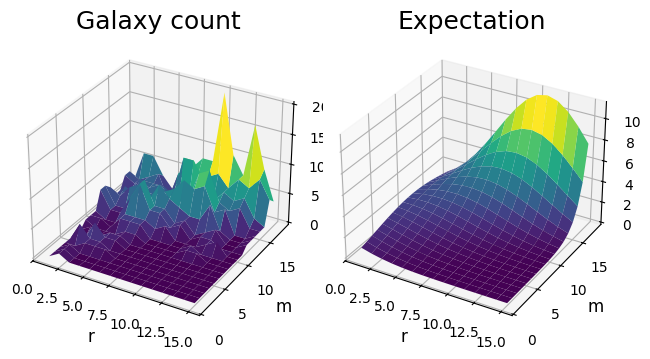

In [ ]:
# @title Poisson regression, galaxy count example {"vertical-output":true,"display-mode":"form"}
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import statsmodels.api as sm

# define data
Nr = 15;
Nm = 18;

yarray = np.array([
    [1, 6, 6, 3, 1, 4, 6, 8, 8, 20, 10, 7, 16, 9, 4],
    [3, 2, 3, 4, 0, 5, 7, 6, 6, 7, 5, 7, 6, 8, 5],
    [3, 2, 3, 3, 3, 2, 9, 9, 6, 3, 5, 4, 5, 2, 1],
    [1, 1, 4, 3, 4, 3, 2, 3, 8, 9, 4, 3, 4, 1, 1],
    [1, 3, 2, 3, 3, 4, 5, 7, 6, 7, 3, 4, 0, 0, 1],
    [3, 2, 4, 5, 3, 6, 4, 3, 2, 2, 5, 1, 0, 0, 1],
    [4, 1, 1, 4, 7, 3, 3, 1, 2, 0, 1, 2, 0, 0, 1],
    [4, 1, 1, 4, 7, 3, 3, 1, 2, 0, 1, 1, 0, 0, 0],
    [1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 0, 1, 2, 0, 0],
    [1, 1, 0, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

rrange = np.arange(1,Nr+1)
mrange = np.arange(Nm,0,-1)

rarray = np.tile( rrange, (18, 1) )
marray = np.tile( mrange, (15, 1) ).T


# flatten arrays

y = yarray.reshape(-1,1)
r = rarray.reshape(-1,1)
m = marray.reshape(-1,1)


# design matrix

X = np.hstack((r, m, r**2, r*m, m**2))

# Fit GLM with Poisson distribution, using STATSMODELS
model = sm.GLM(y, X, family=sm.families.Poisson(sm.families.links.Log()))
results = model.fit()

# Print summary of the model
print(results.summary())

alpha_sm = results.params

# Poisson regression by hand
# Define negative log-likelihood for Poisson distribution
def neg_log_likelihood(alpha, X, y):
    natparam = X @ alpha
    log_likelihood = y * natparam - np.exp(natparam)
    return -np.sum(log_likelihood)

# Initial guess
alpha_init = np.zeros(5)

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, alpha_init, args=(X, y), method='BFGS')

alpha_fit = results.params;

lambda_fit = X @ alpha_fit
mu_fit  = np.exp(lambda_fit)

y_fit = mu_fit.reshape(Nm,Nr)

# Compare parameter fits

print("Fitted params (sm):", alpha_sm)
print("Fitted params (LL):", alpha_fit)


# Visualize results
fig = plt.figure()

# Plot 1: Original counts
ax0 = fig.add_subplot(121, projection='3d')

ax0.plot_surface(rarray, marray, yarray, cmap='viridis')  # You can change colormap

ax0.set_xlabel('r', fontsize=12)
ax0.set_ylabel('m', fontsize=12)
ax0.set_title('Galaxy count', fontsize=18)

# Plot 2: Logistic fit
ax1 = fig.add_subplot(122, projection='3d')

ax1.plot_surface(rarray, marray, y_fit, cmap='viridis')  # You can change colormap

ax1.set_xlabel('r', fontsize=12)
ax1.set_ylabel('m', fontsize=12)
ax1.set_title('Expectation', fontsize=18)

plt.tight_layout()
plt.show()


# **Summary:**

**1. Logistic regression**

**2. Generalized linear models**

**3. Gamma regression**

**4. Poisson regression**


# **Following lectures**

**Lecture 7: Bayes and bootstrap (Jochen Braun)**

**Lecture 8: Bootstrapping examples (Stepan Aleshin)**

**Lecture 9: GLM examples (Stepan Aleshin)**

**Lecture 10: Linear discriminant analysis (Jochen Braun)**

**Lecture 11: Multivariate LDA (Jochen Braun)**



